In [759]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import plotly.express as px
import plotly.graph_objects as go

In [760]:
import pandas as pd

# Cargar los datos
bitcoin_data = pd.read_csv("bitcoin.txt", delimiter=",", quotechar='"')
print(bitcoin_data)

            Date     Price      Open      High       Low     Vol. Change %
0     03/24/2024  67,211.9  64,036.5  67,587.8  63,812.9   65.59K    4.96%
1     03/23/2024  64,037.8  63,785.6  65,972.4  63,074.9   35.11K    0.40%
2     03/22/2024  63,785.5  65,501.5  66,633.3  62,328.3   72.43K   -2.62%
3     03/21/2024  65,503.8  67,860.0  68,161.7  64,616.1   75.26K   -3.46%
4     03/20/2024  67,854.0  62,046.8  68,029.5  60,850.9  133.53K    9.35%
...          ...       ...       ...       ...       ...      ...      ...
4994  07/22/2010       0.1       0.1       0.1       0.1    2.16K    0.00%
4995  07/21/2010       0.1       0.1       0.1       0.1    0.58K    0.00%
4996  07/20/2010       0.1       0.1       0.1       0.1    0.26K    0.00%
4997  07/19/2010       0.1       0.1       0.1       0.1    0.57K    0.00%
4998  07/18/2010       0.1       0.0       0.1       0.1    0.08K    0.00%

[4999 rows x 7 columns]


In [761]:
print(bitcoin_data.head())

         Date     Price      Open      High       Low     Vol. Change %
0  03/24/2024  67,211.9  64,036.5  67,587.8  63,812.9   65.59K    4.96%
1  03/23/2024  64,037.8  63,785.6  65,972.4  63,074.9   35.11K    0.40%
2  03/22/2024  63,785.5  65,501.5  66,633.3  62,328.3   72.43K   -2.62%
3  03/21/2024  65,503.8  67,860.0  68,161.7  64,616.1   75.26K   -3.46%
4  03/20/2024  67,854.0  62,046.8  68,029.5  60,850.9  133.53K    9.35%


In [762]:
print(bitcoin_data.isnull().sum())

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        6
Change %    0
dtype: int64


In [763]:
hay_faltantes = bitcoin_data.isnull().values.any()
print(f"¿Hay valores faltantes? {hay_faltantes}")

¿Hay valores faltantes? True


In [764]:
filas_faltantes = bitcoin_data[bitcoin_data.isnull().any(axis=1)]
print(filas_faltantes)

            Date Price  Open  High   Low Vol. Change %
4656  06/25/2011  17.5  17.5  17.5  17.5  NaN    0.00%
4657  06/24/2011  17.5  17.5  17.5  17.5  NaN    0.00%
4658  06/23/2011  17.5  17.5  17.5  17.5  NaN    0.00%
4659  06/22/2011  17.5  17.5  17.5  17.5  NaN    0.00%
4660  06/21/2011  17.5  17.5  17.5  17.5  NaN    0.00%
4661  06/20/2011  17.5  17.5  17.5  17.5  NaN    0.00%


In [765]:
import pandas as pd

# Cargar los datos
bitcoin_data = pd.read_csv("bitcoin.txt", delimiter=",", quotechar='"')

# Convertir la columna 'Date' a tipo datetime usando el formato correcto
bitcoin_data['Date'] = pd.to_datetime(bitcoin_data['Date'], format="%m/%d/%Y")

# Convertir las columnas de precio y volumen a valores numéricos, manejando los errores
bitcoin_data['Price'] = pd.to_numeric(bitcoin_data['Price'].str.replace(',', ''), errors='coerce')
bitcoin_data['Open'] = pd.to_numeric(bitcoin_data['Open'].str.replace(',', ''), errors='coerce')
bitcoin_data['High'] = pd.to_numeric(bitcoin_data['High'].str.replace(',', ''), errors='coerce')
bitcoin_data['Low'] = pd.to_numeric(bitcoin_data['Low'].str.replace(',', ''), errors='coerce')

# Verificar la limpieza de los datos
print(bitcoin_data.head())



        Date    Price     Open     High      Low     Vol. Change %
0 2024-03-24  67211.9  64036.5  67587.8  63812.9   65.59K    4.96%
1 2024-03-23  64037.8  63785.6  65972.4  63074.9   35.11K    0.40%
2 2024-03-22  63785.5  65501.5  66633.3  62328.3   72.43K   -2.62%
3 2024-03-21  65503.8  67860.0  68161.7  64616.1   75.26K   -3.46%
4 2024-03-20  67854.0  62046.8  68029.5  60850.9  133.53K    9.35%


In [766]:
print(bitcoin_data.head())
print(bitcoin_data.tail())

        Date    Price     Open     High      Low     Vol. Change %
0 2024-03-24  67211.9  64036.5  67587.8  63812.9   65.59K    4.96%
1 2024-03-23  64037.8  63785.6  65972.4  63074.9   35.11K    0.40%
2 2024-03-22  63785.5  65501.5  66633.3  62328.3   72.43K   -2.62%
3 2024-03-21  65503.8  67860.0  68161.7  64616.1   75.26K   -3.46%
4 2024-03-20  67854.0  62046.8  68029.5  60850.9  133.53K    9.35%
           Date  Price  Open  High  Low   Vol. Change %
4994 2010-07-22    0.1   0.1   0.1  0.1  2.16K    0.00%
4995 2010-07-21    0.1   0.1   0.1  0.1  0.58K    0.00%
4996 2010-07-20    0.1   0.1   0.1  0.1  0.26K    0.00%
4997 2010-07-19    0.1   0.1   0.1  0.1  0.57K    0.00%
4998 2010-07-18    0.1   0.0   0.1  0.1  0.08K    0.00%


In [767]:
print(bitcoin_data.dtypes)

Date        datetime64[ns]
Price              float64
Open               float64
High               float64
Low                float64
Vol.                object
Change %            object
dtype: object


In [768]:
bitcoin_data['Date'] = pd.to_datetime(bitcoin_data['Date'])

In [769]:
print(bitcoin_data['Price'].describe())

count     4999.000000
mean     10812.283337
std      15892.032468
min          0.100000
25%        226.700000
50%       1975.100000
75%      15450.150000
max      73066.300000
Name: Price, dtype: float64


In [770]:
print(bitcoin_data['Price'].isnull().sum())

0


# Punto 1 

## Parte 1


### Item 2.
Identifique si existen datos faltantes y realice su imputación usando alguna de las técnicas
básicas estudiadas durante el curso.

Debido a que hay datos faltante en volumen, se graficara fecha vs volumenn. Se observa que los datos contienen M y K, por lo tanto se asume que M son millones y K son mil

In [771]:
import pandas as pd
import matplotlib.pyplot as plt

def convert_volume(vol):
    if pd.isnull(vol): 
        return None
    if 'K' in vol:
        return float(vol.replace('K', '')) * 1000
    elif 'M' in vol:
        return float(vol.replace('M', '')) * 1000000
    else:
        try:
            return float(vol)
        except ValueError:
            return None


In [772]:
bitcoin_data['Vol.'].apply(convert_volume)

0        65590.0
1        35110.0
2        72430.0
3        75260.0
4       133530.0
          ...   
4994      2160.0
4995       580.0
4996       260.0
4997       570.0
4998        80.0
Name: Vol., Length: 4999, dtype: float64

In [773]:
bitcoin_data['Vol.'] = bitcoin_data['Vol.'].apply(convert_volume)

In [774]:
bitcoin_data['Date'] = pd.to_datetime(bitcoin_data['Date'], errors='coerce')
print(bitcoin_data[['Date', 'Vol.']].isnull().sum())
#bitcoin_data.dropna(subset=['Date', 'Vol.'], inplace=True)

Date     0
Vol.    22
dtype: int64


In [775]:
#bitcoin_data['Vol.'] = pd.to_numeric(bitcoin_data['Vol.'], errors='coerce')

In [776]:
# Describir la columna Vol. para ver si hay valores
print(bitcoin_data['Vol.'].describe())

count    4.977000e+03
mean     4.520316e+06
std      4.495640e+07
min      8.000000e+01
25%      3.171000e+04
50%      6.838000e+04
75%      1.818100e+05
max      7.528400e+08
Name: Vol., dtype: float64


In [777]:
w = [1, 2, 3]
max(w)

3

In [778]:
min(bitcoin_data['Vol.'])

80.0

In [779]:
max(bitcoin_data['Vol.'].astype(float))

752840000.0

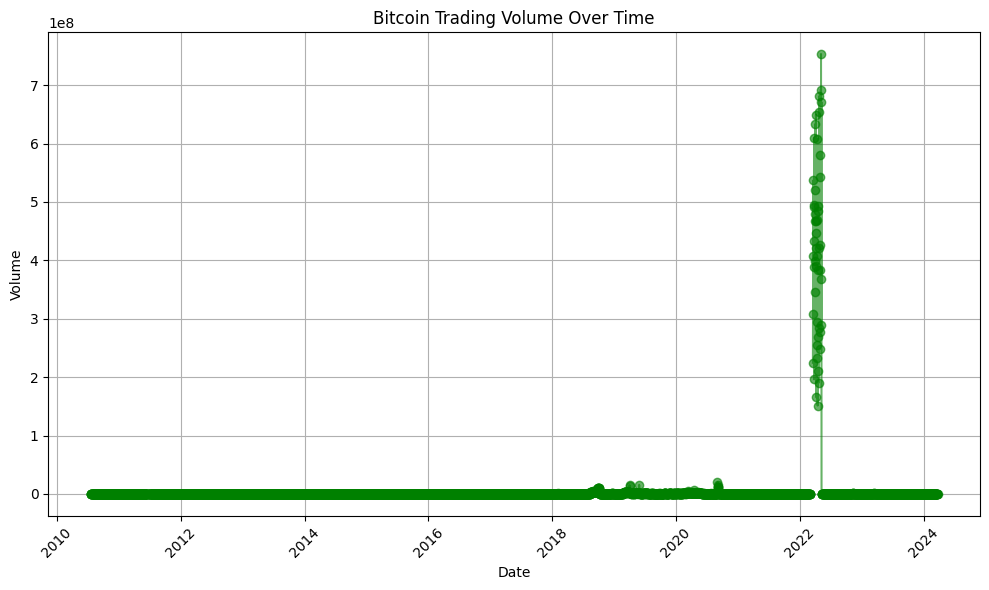

In [780]:
import matplotlib.pyplot as plt

# Crear la gráfica de Volumen contra el Tiempo
plt.figure(figsize=(10, 6))
plt.plot(bitcoin_data['Date'], bitcoin_data['Vol.'], color='g', linestyle='-', marker='o', alpha=0.6)
plt.xlabel('Date')
plt.ylabel('Volume')
plt.title('Bitcoin Trading Volume Over Time')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Se realiza la gráfica de los datos cercanos a los datos faltantes, con el fin de analizar el comportamiento 

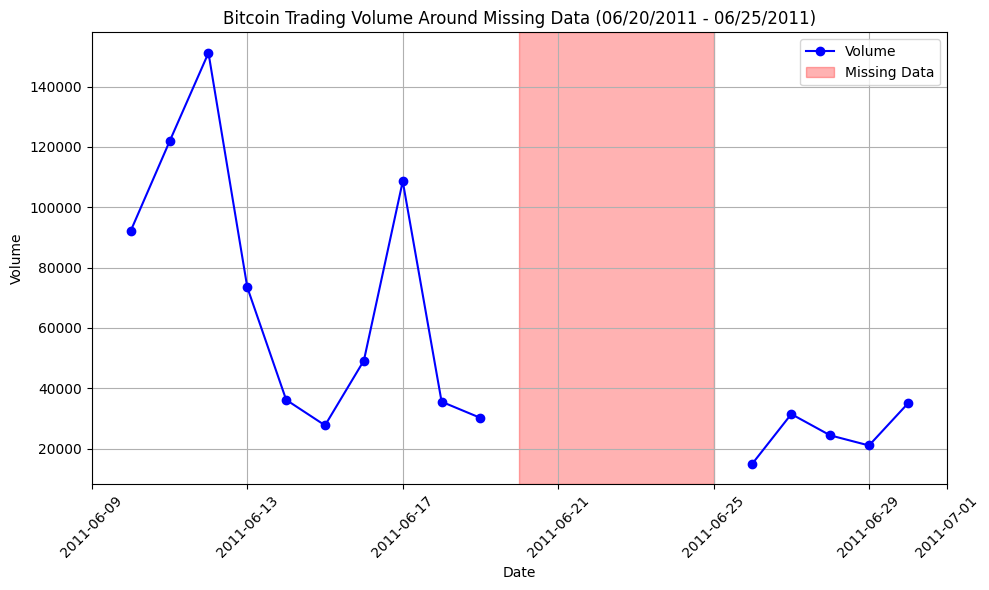

In [781]:
import matplotlib.pyplot as plt

start_date = '2011-06-10' 
end_date = '2011-06-30'    

plot_range = bitcoin_data[(bitcoin_data['Date'] >= start_date) & (bitcoin_data['Date'] <= end_date)]

# Crear la gráfica
plt.figure(figsize=(10, 6))
plt.plot(plot_range['Date'], plot_range['Vol.'], marker='o', linestyle='-', color='b', label='Volume')
plt.axvspan('2011-06-20', '2011-06-25', color='red', alpha=0.3, label='Missing Data')  # Resaltar el rango de datos faltantes
plt.xlabel('Date')
plt.ylabel('Volume')
plt.title('Bitcoin Trading Volume Around Missing Data (06/20/2011 - 06/25/2011)')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()



0


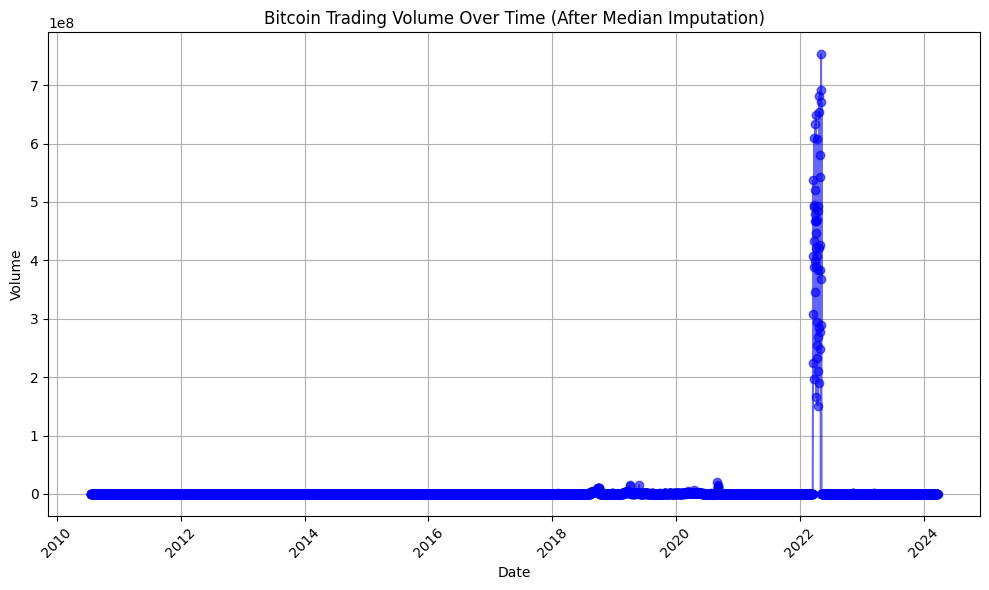

In [782]:
# Calcular la mediana de los valores existentes en 'Vol.'
median_value = bitcoin_data['Vol.'].median()

# Rellenar los valores faltantes con la mediana calculada
bitcoin_data['Vol.'] = bitcoin_data['Vol.'].fillna(median_value)

# Verificar si hay valores faltantes después de la imputación
print(bitcoin_data['Vol.'].isnull().sum())

# Graficar los datos después de la imputación
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(bitcoin_data['Date'], bitcoin_data['Vol.'], color='b', linestyle='-', marker='o', alpha=0.6)
plt.xlabel('Date')
plt.ylabel('Volume')
plt.title('Bitcoin Trading Volume Over Time (After Median Imputation)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

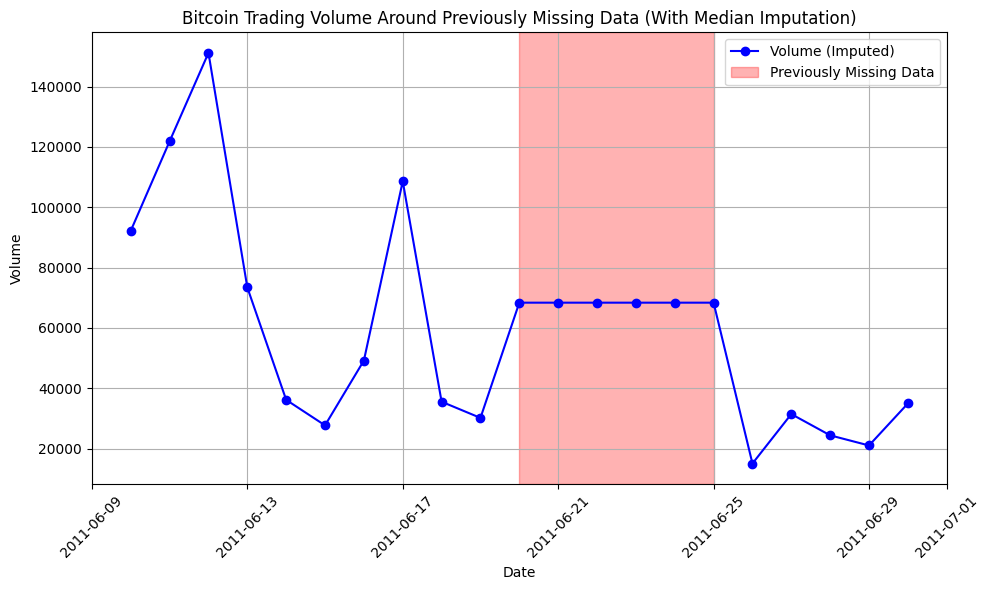

In [783]:
import matplotlib.pyplot as plt

start_date = '2011-06-10'  
end_date = '2011-06-30'    

plot_range = bitcoin_data[(bitcoin_data['Date'] >= start_date) & (bitcoin_data['Date'] <= end_date)]
plt.figure(figsize=(10, 6))
plt.plot(plot_range['Date'], plot_range['Vol.'], marker='o', linestyle='-', color='b', label='Volume (Imputed)')
plt.axvspan('2011-06-20', '2011-06-25', color='red', alpha=0.3, label='Previously Missing Data')  # Resaltar el rango de datos faltantes
plt.xlabel('Date')
plt.ylabel('Volume')
plt.title('Bitcoin Trading Volume Around Previously Missing Data (With Median Imputation)')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


Se realizó el input de los datos faltantes con la mediana, como se puede observar en el gráfico que esta en la parte superiro, el input de vol son los datos que se presentan en la franja roja

### Item 3.

Realice un grafico de velas utilizando la librería Plotly para la serie de tiempo (columna Price).
 Realice también un histograma con Plotly para representar el volumen tradeado diariamente
 (Volume)

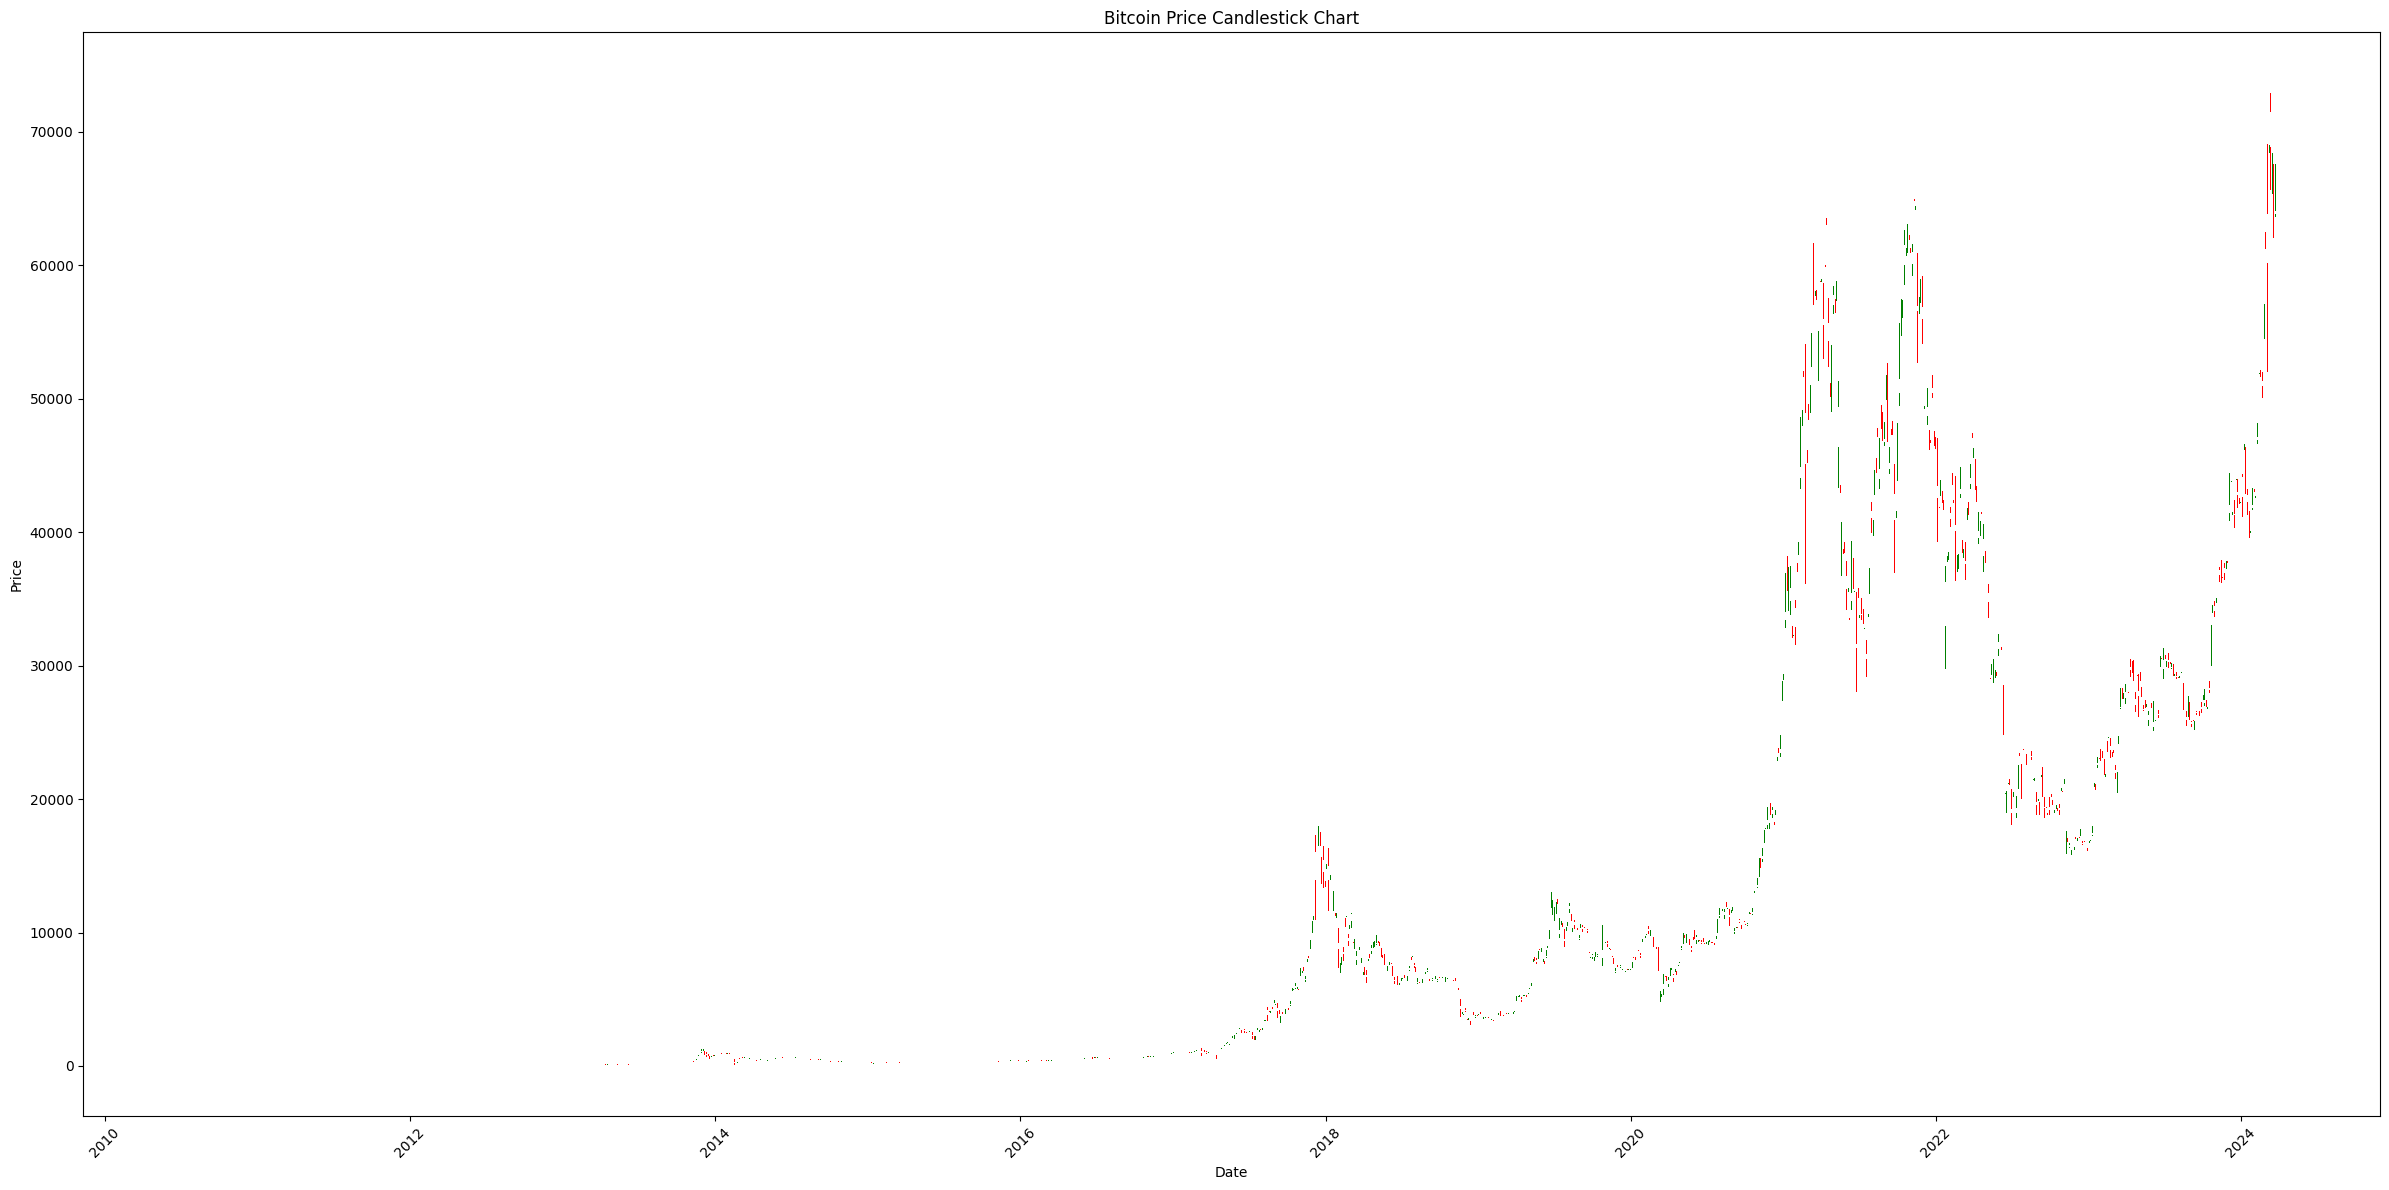

In [784]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegurarte de que las columnas son numéricas
bitcoin_data['Open'] = pd.to_numeric(bitcoin_data['Open'], errors='coerce')
bitcoin_data['High'] = pd.to_numeric(bitcoin_data['High'], errors='coerce')
bitcoin_data['Low'] = pd.to_numeric(bitcoin_data['Low'], errors='coerce')
bitcoin_data['Price'] = pd.to_numeric(bitcoin_data['Price'], errors='coerce')

# Asegurarte de que la columna Date esté en formato de fecha
bitcoin_data['Date'] = pd.to_datetime(bitcoin_data['Date'])

# Crear el gráfico
fig, ax = plt.subplots(figsize=(24, 12))

# Ancho de cada "vela"
width = 0.6
width2 = 0.2

# Colores para velas alcistas y bajistas
up = bitcoin_data['Price'] >= bitcoin_data['Open']
down = bitcoin_data['Price'] < bitcoin_data['Open']

# Velas alcistas (verde)
ax.bar(bitcoin_data['Date'][up], bitcoin_data['Price'][up] - bitcoin_data['Open'][up], width, bottom=bitcoin_data['Open'][up], color='green')
ax.bar(bitcoin_data['Date'][up], bitcoin_data['High'][up] - bitcoin_data['Price'][up], width2, bottom=bitcoin_data['Price'][up], color='green')
ax.bar(bitcoin_data['Date'][up], bitcoin_data['Low'][up] - bitcoin_data['Open'][up], width2, bottom=bitcoin_data['Low'][up], color='green')

# Velas bajistas (rojo)
ax.bar(bitcoin_data['Date'][down], bitcoin_data['Price'][down] - bitcoin_data['Open'][down], width, bottom=bitcoin_data['Open'][down], color='red')
ax.bar(bitcoin_data['Date'][down], bitcoin_data['High'][down] - bitcoin_data['Price'][down], width2, bottom=bitcoin_data['Price'][down], color='red')
ax.bar(bitcoin_data['Date'][down], bitcoin_data['Low'][down] - bitcoin_data['Open'][down], width2, bottom=bitcoin_data['Low'][down], color='red')

# Configuración del título y etiquetas
ax.set_title('Bitcoin Price Candlestick Chart')
ax.set_xlabel('Date')
ax.set_ylabel('Price')

# Rotar fechas en el eje x para claridad
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


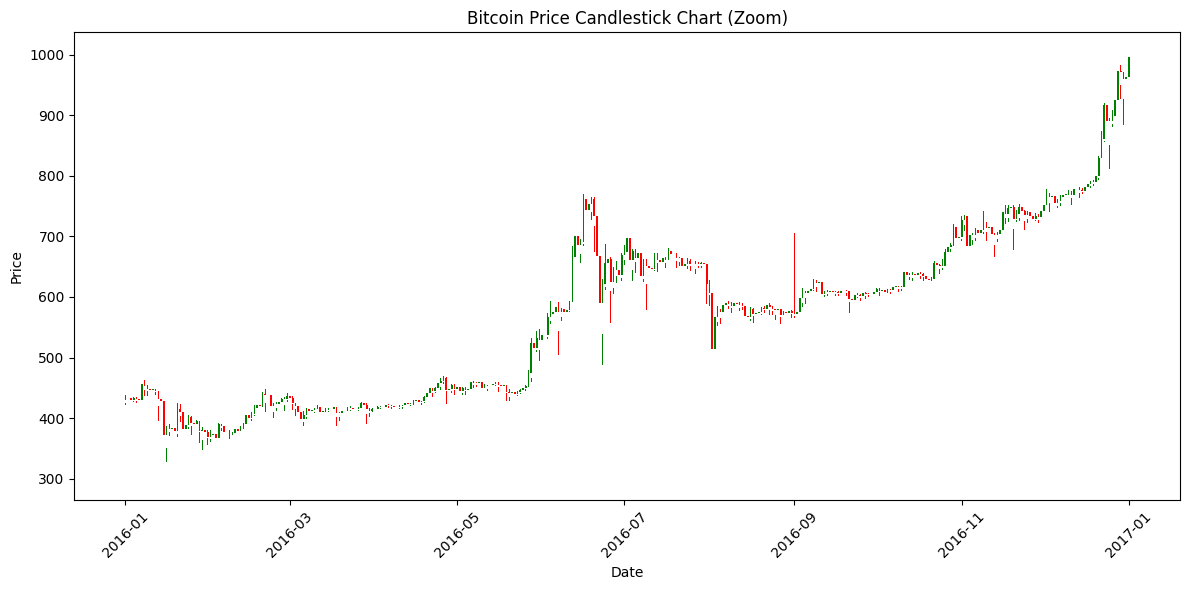

In [785]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegurarte de que las columnas son numéricas
bitcoin_data['Open'] = pd.to_numeric(bitcoin_data['Open'], errors='coerce')
bitcoin_data['High'] = pd.to_numeric(bitcoin_data['High'], errors='coerce')
bitcoin_data['Low'] = pd.to_numeric(bitcoin_data['Low'], errors='coerce')
bitcoin_data['Price'] = pd.to_numeric(bitcoin_data['Price'], errors='coerce')

# Asegurarte de que la columna Date esté en formato de fecha
bitcoin_data['Date'] = pd.to_datetime(bitcoin_data['Date'])

# Filtrar un rango de fechas específico para el zoom
start_date = '2016-01-01'
end_date = '2017-01-01'
mask = (bitcoin_data['Date'] >= start_date) & (bitcoin_data['Date'] <= end_date)
bitcoin_data_zoom = bitcoin_data.loc[mask]

# Crear el gráfico con el rango de fechas especificado
fig, ax = plt.subplots(figsize=(12, 6))

# Ancho de cada "vela"
width = 0.6
width2 = 0.2

# Colores para velas alcistas y bajistas en el rango filtrado
up = bitcoin_data_zoom['Price'] >= bitcoin_data_zoom['Open']
down = bitcoin_data_zoom['Price'] < bitcoin_data_zoom['Open']

# Velas alcistas (verde)
ax.bar(bitcoin_data_zoom['Date'][up], bitcoin_data_zoom['Price'][up] - bitcoin_data_zoom['Open'][up], width, bottom=bitcoin_data_zoom['Open'][up], color='green')
ax.bar(bitcoin_data_zoom['Date'][up], bitcoin_data_zoom['High'][up] - bitcoin_data_zoom['Price'][up], width2, bottom=bitcoin_data_zoom['Price'][up], color='green')
ax.bar(bitcoin_data_zoom['Date'][up], bitcoin_data_zoom['Low'][up] - bitcoin_data_zoom['Open'][up], width2, bottom=bitcoin_data_zoom['Low'][up], color='green')

# Velas bajistas (rojo)
ax.bar(bitcoin_data_zoom['Date'][down], bitcoin_data_zoom['Price'][down] - bitcoin_data_zoom['Open'][down], width, bottom=bitcoin_data_zoom['Open'][down], color='red')
ax.bar(bitcoin_data_zoom['Date'][down], bitcoin_data_zoom['High'][down] - bitcoin_data_zoom['Price'][down], width2, bottom=bitcoin_data_zoom['Price'][down], color='red')
ax.bar(bitcoin_data_zoom['Date'][down], bitcoin_data_zoom['Low'][down] - bitcoin_data_zoom['Open'][down], width2, bottom=bitcoin_data_zoom['Low'][down], color='red')

# Configuración del título y etiquetas
ax.set_title('Bitcoin Price Candlestick Chart (Zoom)')
ax.set_xlabel('Date')
ax.set_ylabel('Price')

# Rotar fechas en el eje x para claridad
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


En el gráfico se puede observar que hasta el 2017 el comportamiento del birtcoin tuve pequeeñas fluctuaciones, por lo tanto se dice que el comportamiento fue relativamente estable. A partir de ese año el precio presento una tendencia alcista. Posteriormente se puede observar un patrón ciclico con crecimiento acelerado y caidas abruptas esto puede ser debido a reacciones de factores externos. En el 2020 se puede observar que la votalidad aumenta y esto pudo ser causado debido a la pandemia, luego de la pandemia queda la votatilidad persiste, se presenta un crecimeinto acumulado con caidad abruptas y en el 2024 presenta una tendencia alcista

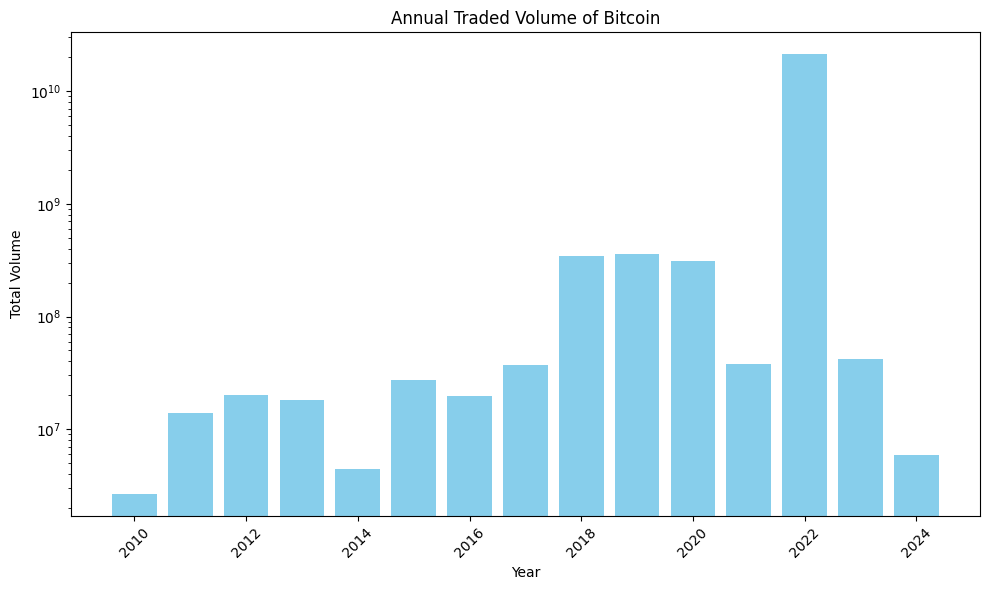

In [786]:
import matplotlib.pyplot as plt
import pandas as pd

# Asegúrate de que 'Date' sea de tipo datetime
bitcoin_data['Date'] = pd.to_datetime(bitcoin_data['Date'])
bitcoin_data['Year'] = bitcoin_data['Date'].dt.year

# Agrupar los datos por año y sumar el volumen anual
annual_data = bitcoin_data.groupby('Year')['Vol.'].sum().reset_index()

# Crear el gráfico de barras en matplotlib
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(annual_data['Year'], annual_data['Vol.'], color='skyblue')

# Configuración del título y etiquetas
ax.set_title('Annual Traded Volume of Bitcoin')
ax.set_xlabel('Year')
ax.set_ylabel('Total Volume')
ax.set_yscale('log')  # Establecer escala logarítmica en el eje y

# Ajuste del espacio entre las barras para mayor claridad
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




Se puede observar en la gráfica tiene una tendencia alcista  en el # de transacciones por días, cuando llego la pandemia el la cantidad de transacciones empieza a disminuir, hasta el 2022 que aumenta y posteriormente se observa una caída marcada en el 2023 y 2024. Esta fluctuaciones pudieron ser generadas por factores externos 

### Item 4.
 Realice graficos de subseries considerando agrupación por semana, mes y año. Utilice graficos
 de series de tiempo y boxplots para analizar estas subseries.

In [787]:

bitcoin_data['Date'] = pd.to_datetime(bitcoin_data['Date'], errors='coerce')
bitcoin_data['Price'] = pd.to_numeric(bitcoin_data['Price'], errors='coerce')



bitcoin_data['Year'] = bitcoin_data['Date'].dt.year
bitcoin_data['Month'] = bitcoin_data['Date'].dt.month
bitcoin_data['Week'] = bitcoin_data['Date'].dt.isocalendar().week


print(bitcoin_data[['Date', 'Year', 'Month', 'Week']].head(10))

        Date  Year  Month  Week
0 2024-03-24  2024      3    12
1 2024-03-23  2024      3    12
2 2024-03-22  2024      3    12
3 2024-03-21  2024      3    12
4 2024-03-20  2024      3    12
5 2024-03-19  2024      3    12
6 2024-03-18  2024      3    12
7 2024-03-17  2024      3    11
8 2024-03-16  2024      3    11
9 2024-03-15  2024      3    11


In [788]:

datos_semanales = bitcoin_data.groupby(['Year', 'Week'])['Price'].mean().reset_index()

datos_mensuales = bitcoin_data.groupby(['Year', 'Month'])['Price'].mean().reset_index()

datos_anuales = bitcoin_data.groupby(['Year'])['Price'].mean().reset_index()



In [789]:

datos_semanales['Price'] = pd.to_numeric(datos_semanales['Price'], errors='coerce')
datos_mensuales['Price'] = pd.to_numeric(datos_mensuales['Price'], errors='coerce')
datos_anuales['Price'] = pd.to_numeric(datos_anuales['Price'], errors='coerce')


datos_semanales = datos_semanales.dropna(subset=['Price'])
datos_mensuales = datos_mensuales.dropna(subset=['Price'])
datos_anuales = datos_anuales.dropna(subset=['Price'])


print(datos_semanales.head(10))
print(datos_mensuales.head(10))
print(datos_anuales.head(10))


   Year  Week  Price
0  2010    28    0.1
1  2010    29    0.1
2  2010    30    0.1
3  2010    31    0.1
4  2010    32    0.1
5  2010    33    0.1
6  2010    34    0.1
7  2010    35    0.1
8  2010    36    0.1
9  2010    37    0.1
   Year  Month     Price
0  2010      7  0.100000
1  2010      8  0.100000
2  2010      9  0.100000
3  2010     10  0.119355
4  2010     11  0.263333
5  2010     12  0.238710
6  2011      1  0.354839
7  2011      2  0.925000
8  2011      3  0.858065
9  2011      4  1.250000
   Year        Price
0  2010     0.158683
1  2011     5.644658
2  2012     8.291803
3  2013   200.149041
4  2014   522.891233
5  2015   272.024110
6  2016   566.997814
7  2017  3981.072329
8  2018  7552.158356
9  2019  7371.821918


Serie semanal

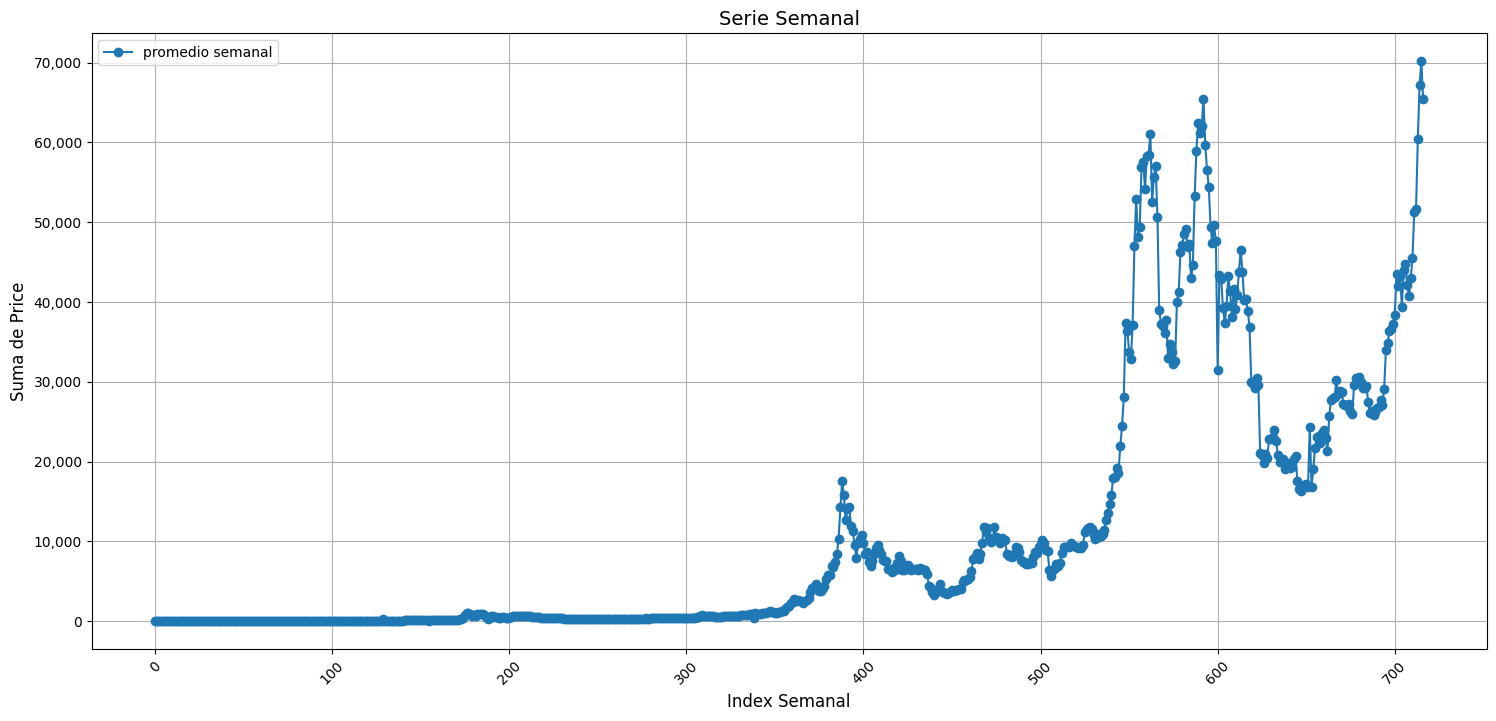

In [790]:
import matplotlib.ticker as mticker

# Gráfico Semanal
plt.figure(figsize=(18, 8))
plt.plot(datos_semanales.index, datos_semanales['Price'], marker='o', label='promedio semanal')
plt.title('Serie Semanal', fontsize=14)
plt.xlabel('Index Semanal', fontsize=12)
plt.ylabel('Suma de Price', fontsize=12)
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.show() 



En la grafica de la serie semanal se puede observar una alta volatilidad, pero con tendencia creciente, especialemente al fianlizar la serie, ademas presenta alta variabilidad especialemnte al rededor de la semana 400 se puede observar mayor fluctuaciones. Ademas la grafica muestra patrones ciclicos para realizar un mejor analisis se realiza una descomposici[on para revisar los siguientes componentes: la tendencia de la serie, estacionalidad y resiadual 

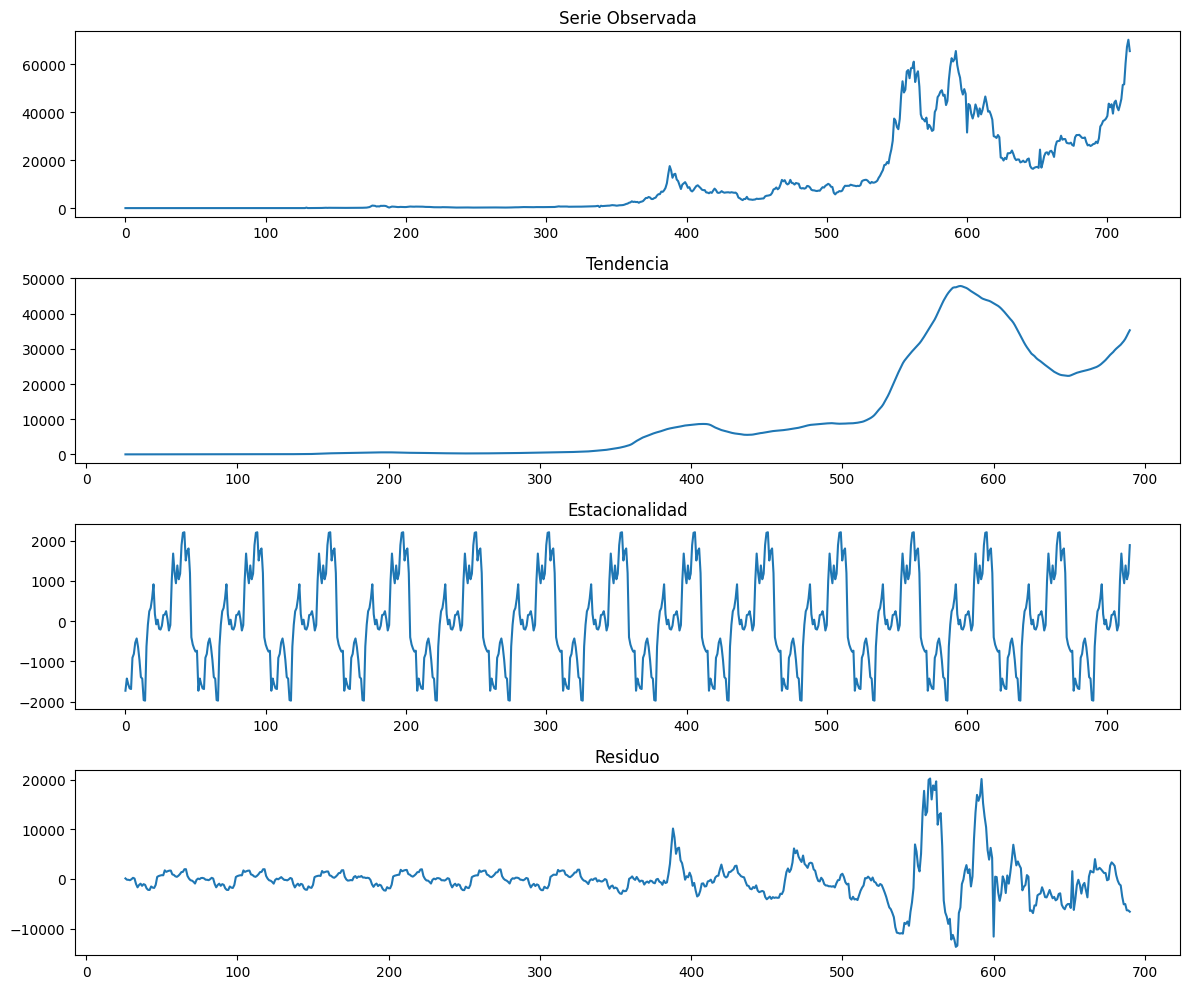

In [791]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomposition = seasonal_decompose(datos_semanales['Price'], model='additive', period=52)

fig, ax = plt.subplots(4, 1, figsize=(12, 10))
decomposition.observed.plot(ax=ax[0], title='Serie Observada')
decomposition.trend.plot(ax=ax[1], title='Tendencia')
decomposition.seasonal.plot(ax=ax[2], title='Estacionalidad')
decomposition.resid.plot(ax=ax[3], title='Residuo')

plt.tight_layout()
plt.show()


En el grafico de tendencia se puede observar un aunmento gradual, el cual se acelera al rededor de la semana 400, ademas de puede ver que al rededor de la semana 600 hay un pico en el precio del bitcoin. En el grafico se estacionalidad se puede percibir que hay un patron repetitivo. En la grafica se residuo se puede notar que hay eventos los cuales no pueden ser predecidos facilmente con la tendencia y la estacionalidad, por lo menos las oscilaciones en la semana 600 se pueden dar por eventos atipicos.

Serie mensual

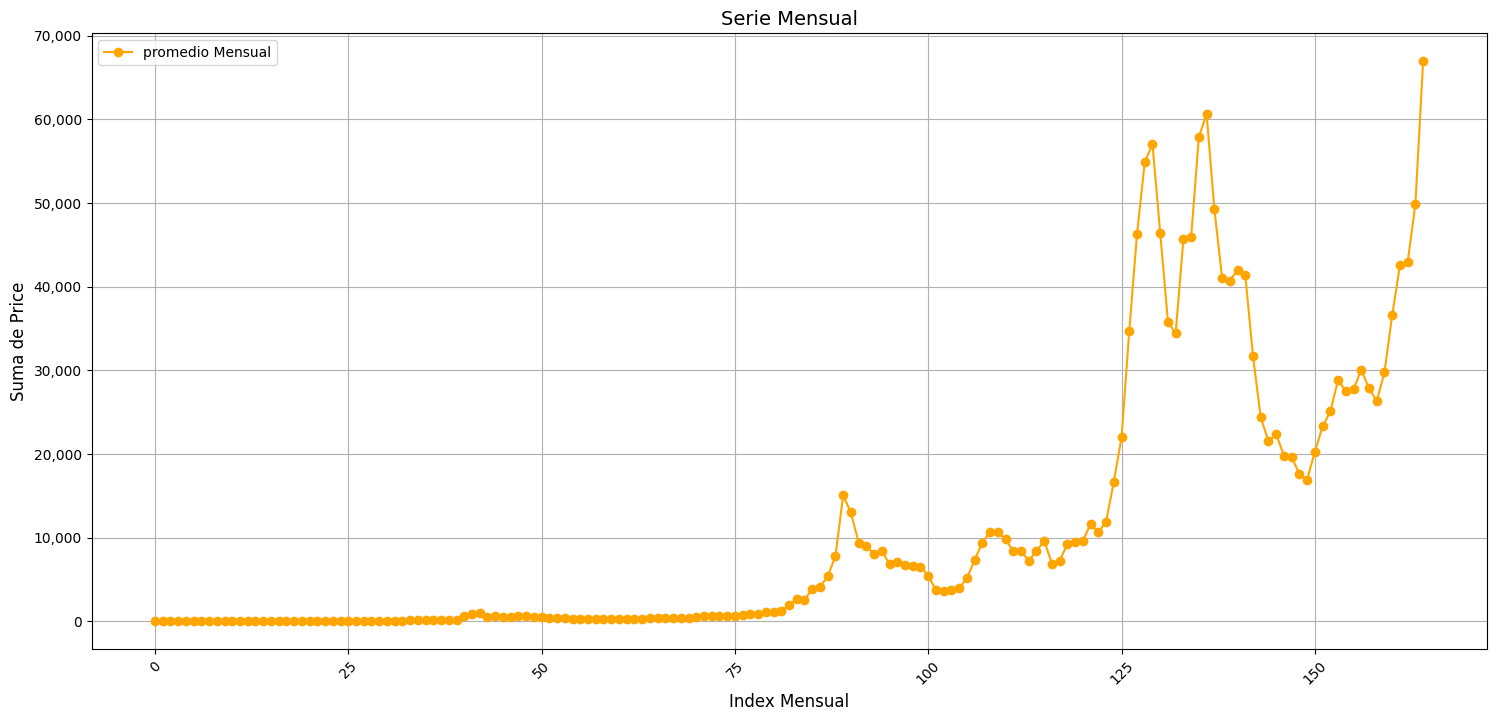

In [792]:
# Gráfico Mensual
plt.figure(figsize=(18, 8))
plt.plot(datos_mensuales.index, datos_mensuales['Price'], marker='o', label='promedio Mensual', color='orange')
plt.title('Serie Mensual', fontsize=14)
plt.xlabel('Index Mensual', fontsize=12)
plt.ylabel('Suma de Price', fontsize=12)
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.show()


En la serie se puede observar que hay meses donde los precios del bitcoin se mantuvieron bajos, aproximandante apartir de la semana 75 se puede ver un aumento del precio. ademas se presentan varios picos y caidas del rpecio del Bitcoin 

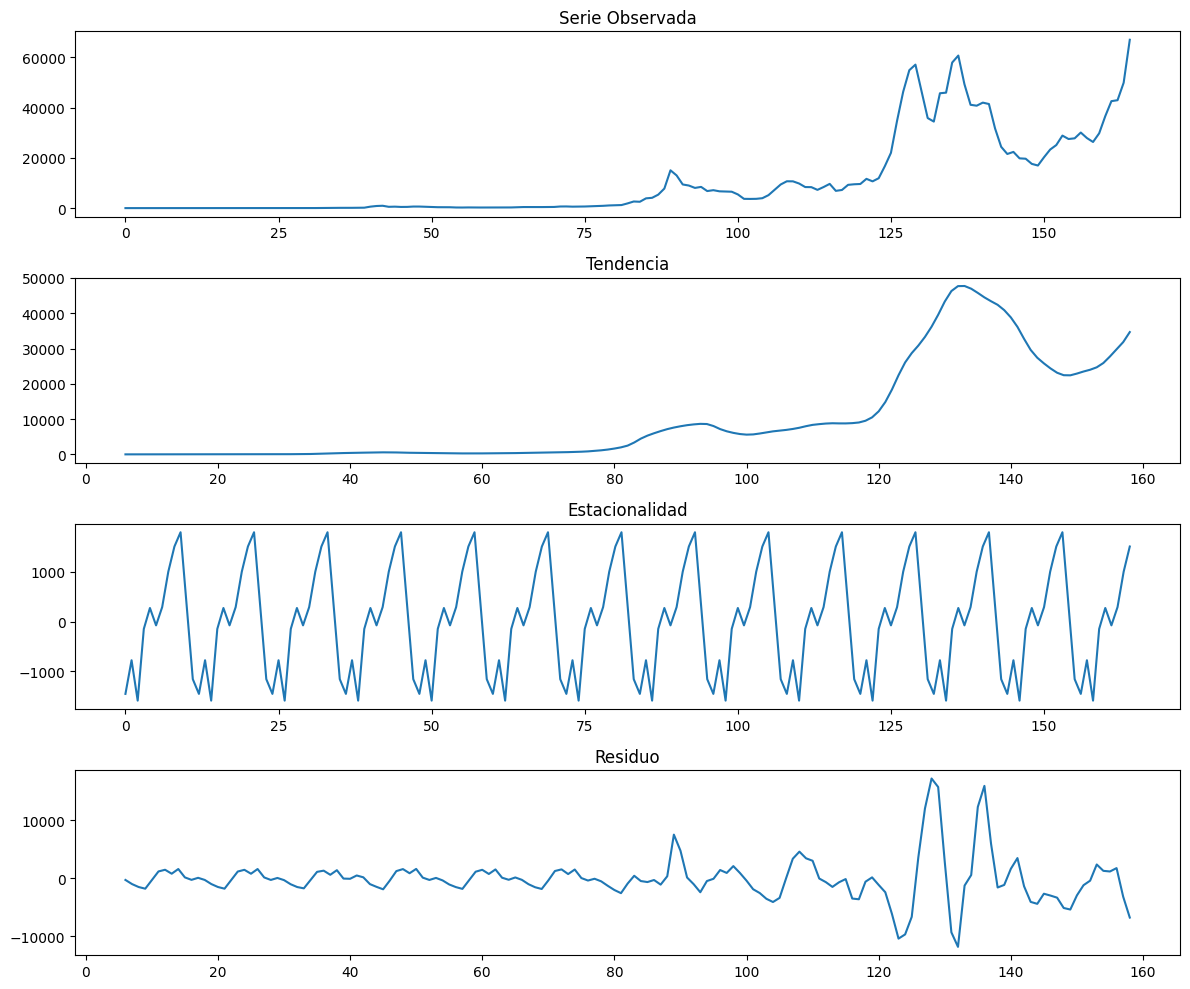

In [793]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
decomposition = seasonal_decompose(datos_mensuales['Price'], model='additive', period=12)

fig, ax = plt.subplots(4, 1, figsize=(12, 10))
decomposition.observed.plot(ax=ax[0], title='Serie Observada')
decomposition.trend.plot(ax=ax[1], title='Tendencia')
decomposition.seasonal.plot(ax=ax[2], title='Estacionalidad')
decomposition.resid.plot(ax=ax[3], title='Residuo')

plt.tight_layout()
plt.show()


En el grafico de tendencia se puede ver un incremento a lo largo de los meses en el precio del Bitcoin, sobretodo a partir del mes 60. 
En el grafico de estacionalidad se puede observar que hay un patron estacional con repeticiones 
En el grafico de residuo se puede observra que estos tienen variaciones, por lo cual se dice que hay volatilidad en los datos la cual no puede ser explicada ni por la tendencia ni la estacionalidad

Serie anual

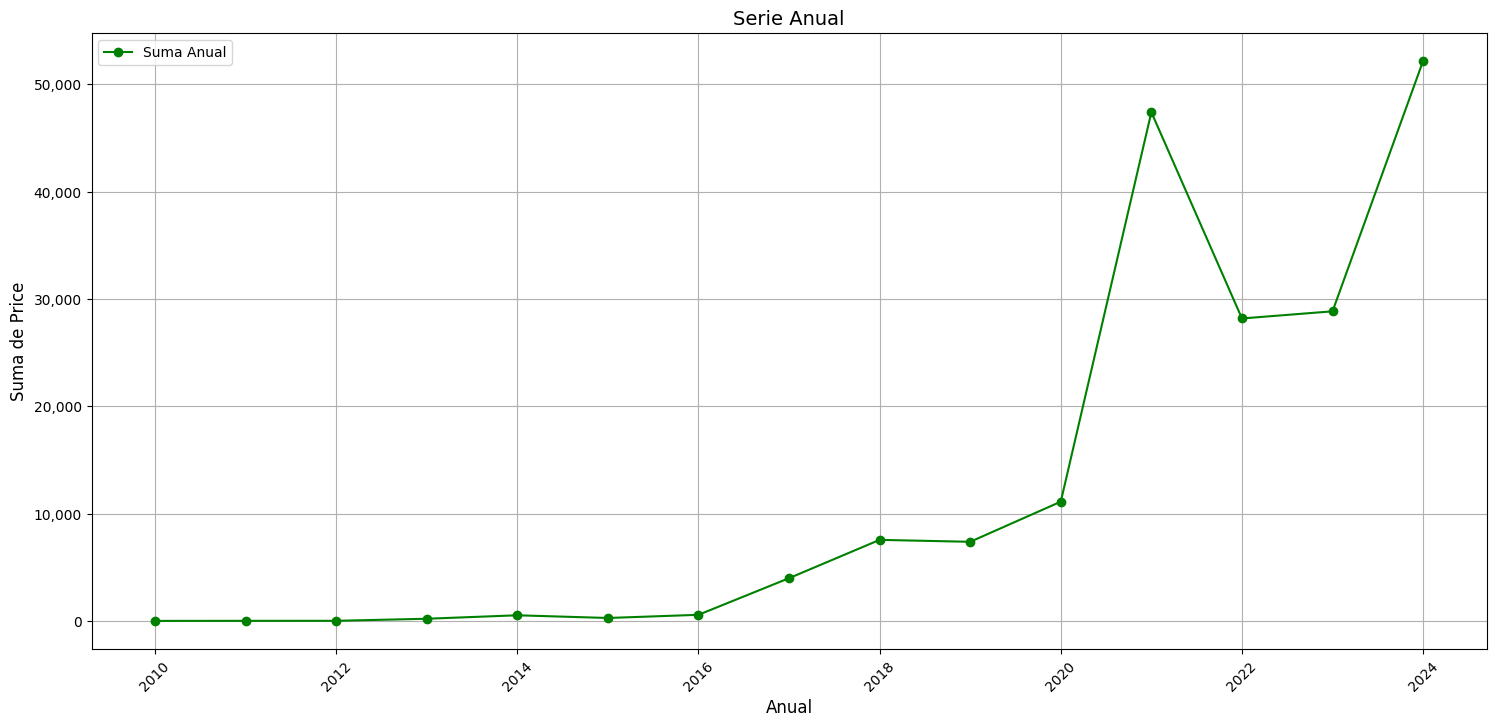

In [794]:
# Gráfico Anual 
plt.figure(figsize=(18, 8))
plt.plot(datos_anuales['Year'], datos_anuales['Price'], marker='o', label='Suma Anual', color='green')
plt.title('Serie Anual', fontsize=14)
plt.xlabel('Anual', fontsize=12)
plt.ylabel('Suma de Price', fontsize=12)
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.show()

En la grafica se puede observar que desde los primeros años el precio del Bitcoin se mnatuvo bajo y estable, el cual empezo a incremental a partir dle 2016, En el 2017 se muestra un crecimiento significativo hasta el 2021, en este año el bitcoin alcanzo los valores maximos historicos, despuedes de esto se presenta una caida esto pudo ser causado por la pandemia 

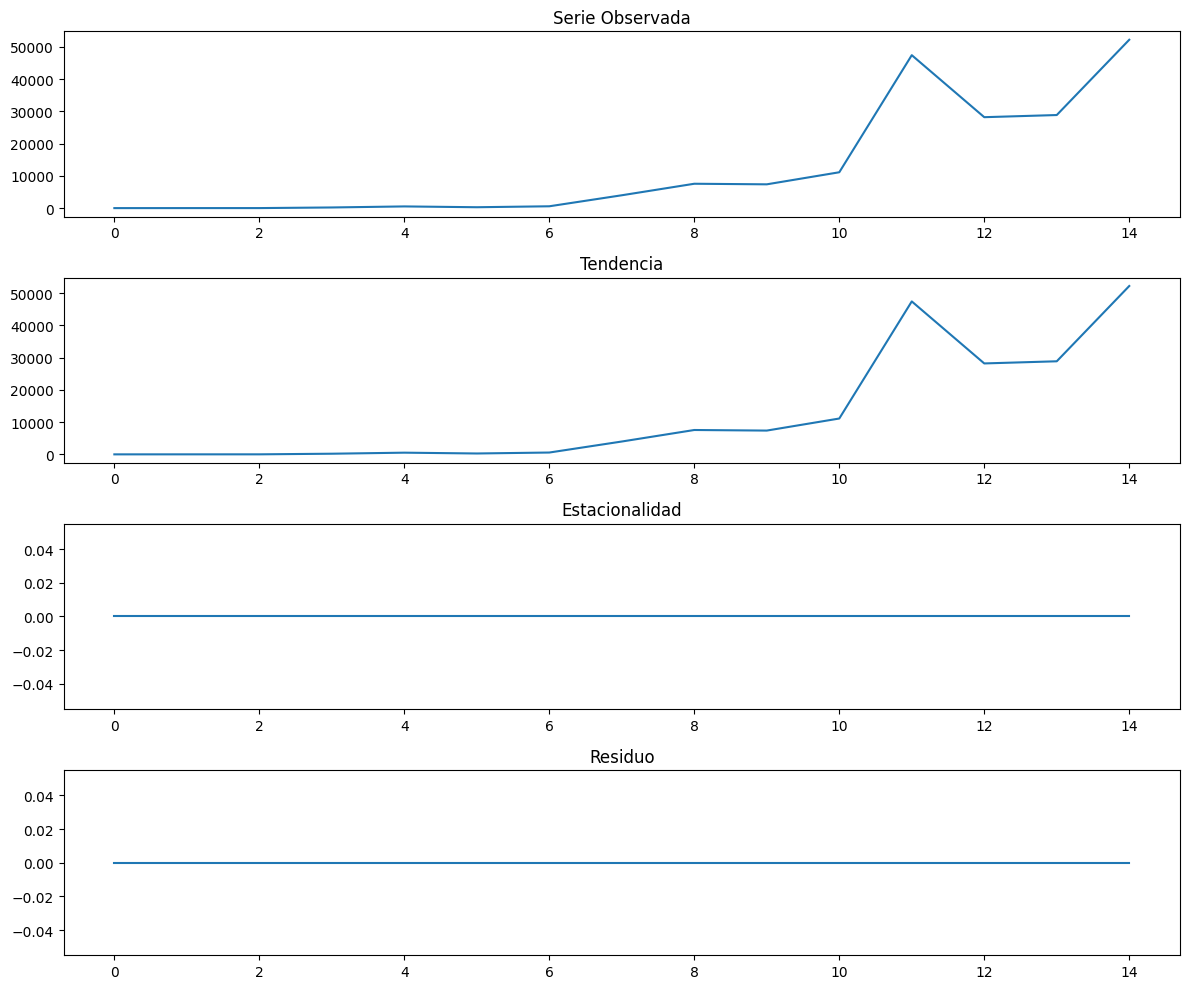

In [795]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomposition = seasonal_decompose(datos_anuales['Price'], model='additive', period=1)

fig, ax = plt.subplots(4, 1, figsize=(12, 10))
decomposition.observed.plot(ax=ax[0], title='Serie Observada')
decomposition.trend.plot(ax=ax[1], title='Tendencia')
decomposition.seasonal.plot(ax=ax[2], title='Estacionalidad')
decomposition.resid.plot(ax=ax[3], title='Residuo')

plt.tight_layout()
plt.show()

Segun la grafica se puede observar que el Bitcoin a novel anual no sigie patrones estacionales regulares como otras series 

Boxplot semanal

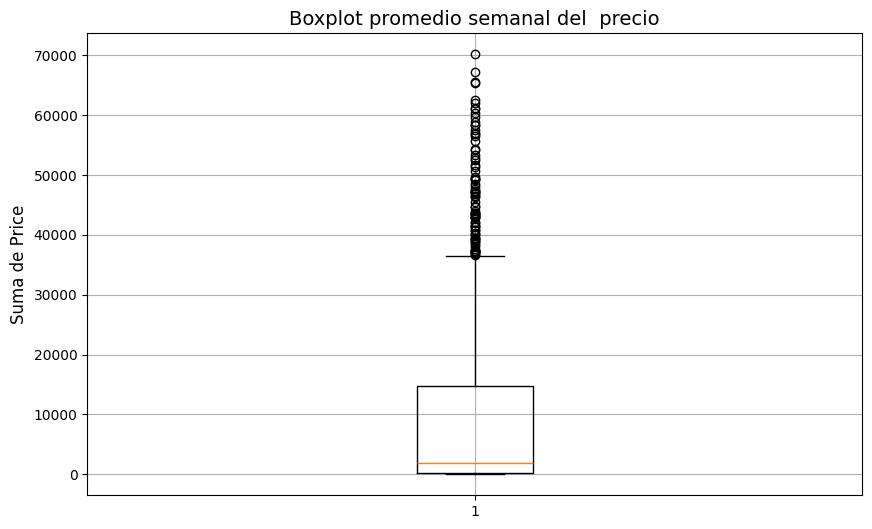

In [796]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.boxplot(datos_semanales['Price'])
plt.title('Boxplot promedio semanal del  precio', fontsize=14)
plt.ylabel('Suma de Price', fontsize=12)
plt.grid(True)
plt.show()

Se puede observar que la mediana de la suma semanal del precio se encuentra en un rango bajo,lo cual indica que la mayoria de semanas el precio del bitcoin fue bajo, Ademas se puede observar gran frecuencia de outliers, esto puede ser porque hubo semanaas en el cual el precio del bitcoin fue mayor que en las demas semanas. los datos son sesgados hacia la derecha.

Boxplot mensual

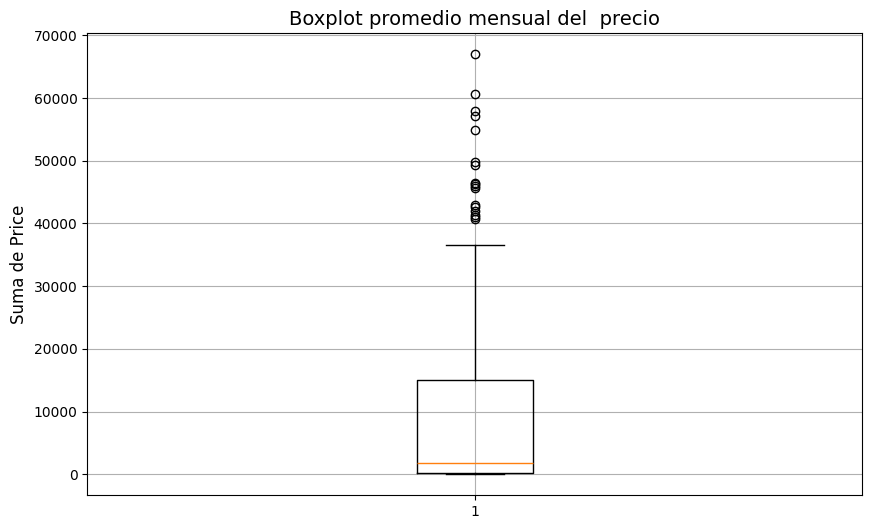

In [797]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.boxplot(datos_mensuales['Price'])
plt.title('Boxplot promedio mensual del  precio', fontsize=14)
plt.ylabel('Suma de Price', fontsize=12)
plt.grid(True)
plt.show()

La mediana esta cerca del limite inferior esto es debido a que la gran parte del promedio del precio del bitcoin son bajos, la caja que representa el rango intercuartil muestra que aproximadamente el 50% de los datos estan en un rango estrecho, es decir, la mayoria de meses el precio del bitcoin no varia en gran cantidad. Ademas se observa gran cantidad de valores atipicos hacia arriba, debido a que hay meses en los cuales el valor del bitcoin fue alto en compracion a los otrso meses

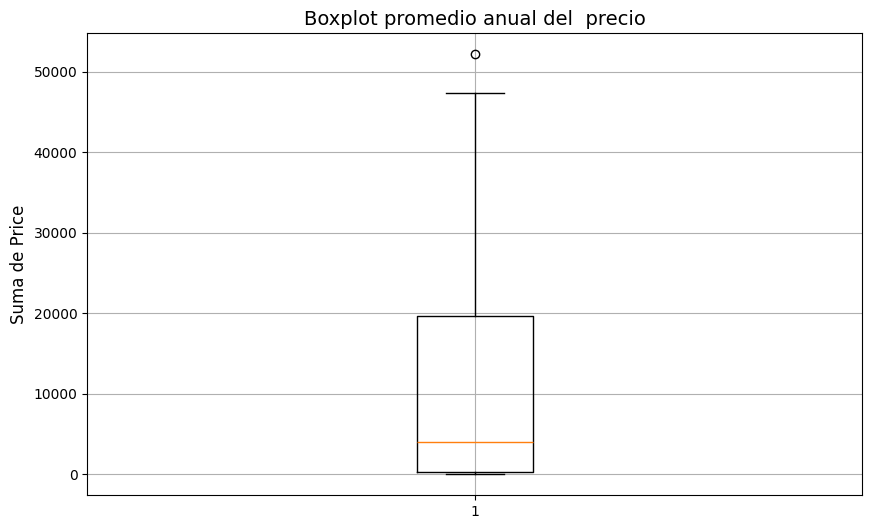

In [798]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.boxplot(datos_anuales['Price'])
plt.title('Boxplot promedio anual del  precio', fontsize=14)
plt.ylabel('Suma de Price', fontsize=12)
plt.grid(True)
plt.show()

La mediana esta en la parte baja de la caja, debido a que la mayoria de precios anuales tienden a concentrase en valores mas bajos, los bigotes se extienden, lo cual indica que existen valores más altos que aún están dentro del rango normal de la distribución. 

### Item 5.
  Estudie estacionariedad de la serie de tiempo usando la ACF estudiada durante el curso el curso, asi como tambien los respectivos test estadísticos tales como Ljung-Box y Dickey Fuller. Aplique
 además las transformaciones necesarias para convertir la serie de tiempo en estacionaria.

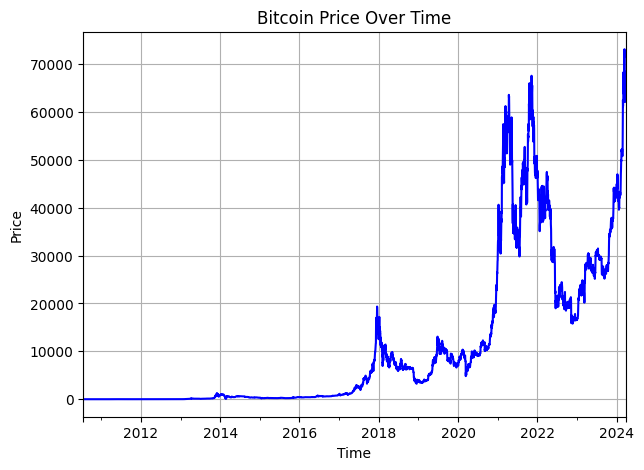

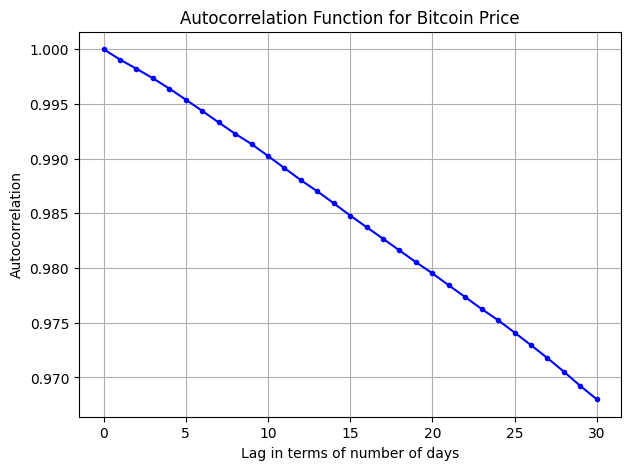

<Figure size 700x500 with 0 Axes>

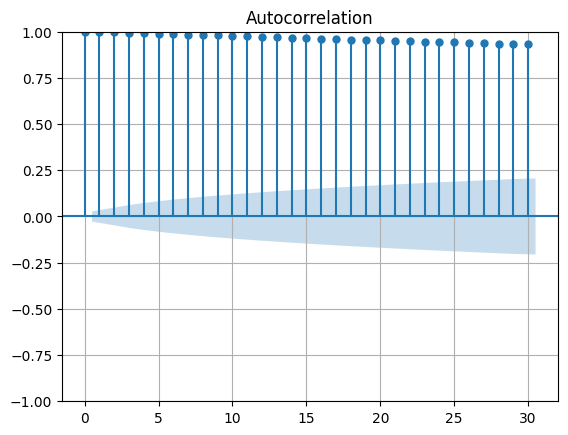

<Figure size 700x500 with 0 Axes>

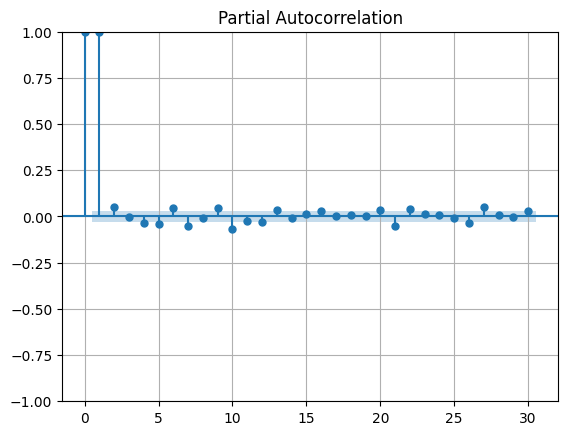

In [799]:
import pandas as pd
from matplotlib import pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

bitcoin_data['Date'] = pd.to_datetime(bitcoin_data['Date'])
bitcoin_data.set_index('Date', inplace=True)

plt.figure(figsize=(7, 5))
bitcoin_data['Price'].plot(color='b')
plt.title('Bitcoin Price Over Time')
plt.xlabel('Time')
plt.ylabel('Price')
plt.grid(True)
plt.show()

lag = range(0, 31)
bitcoin_acf = [bitcoin_data['Price'].autocorr(l) for l in lag]

plt.figure(figsize=(7, 5))
plt.plot(lag, bitcoin_acf, marker='.', color='b')
plt.title('Autocorrelation Function for Bitcoin Price')
plt.xlabel('Lag in terms of number of days')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plot_acf(bitcoin_data['Price'], lags=30)
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plot_pacf(bitcoin_data['Price'], lags=30)
plt.grid(True)
plt.show()



En el gráfico se puede observar que la autocorrelación empiezan en 1, debido a que essta serie esta perfectamente correlacionada, es decir, que los valores del precio del bitcoin estan fuertemente correlacionadas en cortos periodos de tiempo. Asimismo se puede observar que a medida que aumenta el lag, la autocorrelación disminuye de manera lineal. La serie de precios del Bitcoin tiene gran dependencia del pasado.

En el gráfico de  autocorrelación parcial los dos primeros lags tienen valores altos signiifcativos, lo cuál indica hay una fuerte correlación directa directa entre el precio actual y los dos valores anteriores. Después de los primeros dos lagas el PACF cae rapidamente a valores cercanos de cero. lo cuál indica que la dependencia direcat disminuye después del segundo lag, lo que sugiere que los lags mas altos no aportan mucha información adicional


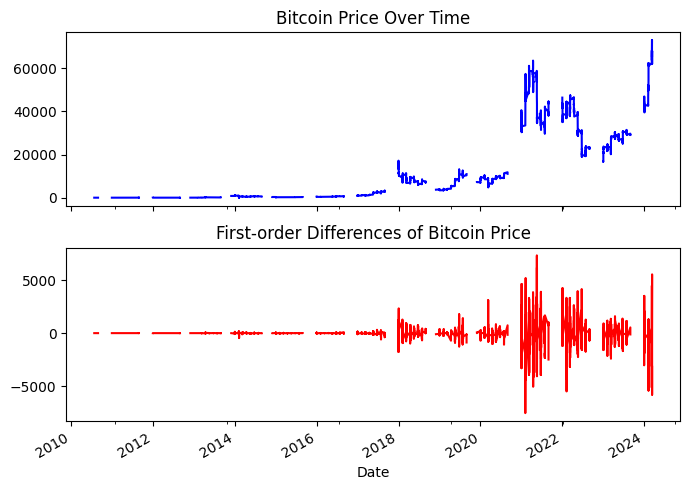

Ljung-Box Test Results for Bitcoin Prices:
Null hypothesis is rejected at lag = 0 for p-val = 0.0000
Null hypothesis is rejected at lag = 1 for p-val = 0.0000
Null hypothesis is rejected at lag = 2 for p-val = 0.0000
Null hypothesis is rejected at lag = 3 for p-val = 0.0000
Null hypothesis is rejected at lag = 4 for p-val = 0.0000
Null hypothesis is rejected at lag = 5 for p-val = 0.0000
Null hypothesis is rejected at lag = 6 for p-val = 0.0000
Null hypothesis is rejected at lag = 7 for p-val = 0.0000
Null hypothesis is rejected at lag = 8 for p-val = 0.0000
Null hypothesis is rejected at lag = 9 for p-val = 0.0000
Null hypothesis is rejected at lag = 10 for p-val = 0.0000
Null hypothesis is rejected at lag = 11 for p-val = 0.0000
Null hypothesis is rejected at lag = 12 for p-val = 0.0000
Null hypothesis is rejected at lag = 13 for p-val = 0.0000
Null hypothesis is rejected at lag = 14 for p-val = 0.0000
Null hypothesis is rejected at lag = 15 for p-val = 0.0000
Null hypothesis is reje

In [800]:
import pandas as pd
from matplotlib import pyplot as plt
from statsmodels.tsa import stattools
from pandas.plotting import autocorrelation_plot

bitcoin_data['Date'] = pd.to_datetime(bitcoin_data[['Year', 'Month', 'Week']].astype(str).agg('-'.join, axis=1), errors='coerce')

bitcoin_data.set_index('Date', inplace=True)


bitcoin_data = bitcoin_data.dropna(subset=['Price'])

first_order_diff = bitcoin_data['Price'].diff(1)

fig, ax = plt.subplots(2, sharex=True)
fig.set_size_inches(7, 5)
bitcoin_data['Price'].plot(ax=ax[0], color='b')
ax[0].set_title('Bitcoin Price Over Time')
first_order_diff.plot(ax=ax[1], color='r')
ax[1].set_title('First-order Differences of Bitcoin Price')
plt.tight_layout()
plt.show()

# Test de Ljung-Box para la serie original
acf_bitcoin, confint_bitcoin, qstat_bitcoin, pvalues_bitcoin = stattools.acf(
    bitcoin_data['Price'], nlags=20, qstat=True, alpha=0.05
)

alpha = 0.05
print("Ljung-Box Test Results for Bitcoin Prices:")
for l, p_val in enumerate(pvalues_bitcoin):
    if p_val > alpha:
        print(f'Null hypothesis is accepted at lag = {l} for p-val = {p_val:.4f}')
    else:
        print(f'Null hypothesis is rejected at lag = {l} for p-val = {p_val:.4f}')

# Test de Ljung-Box para la primera diferencia de la serie
acf_first_diff, confint_first_diff, qstat_first_diff, pvalues_first_diff = stattools.acf(
    first_order_diff.iloc[1:], nlags=20, qstat=True, alpha=0.05
)

print("\nLjung-Box Test Results for First Differences of Bitcoin Prices:")
for l, p_val in enumerate(pvalues_first_diff):
    if p_val > alpha:
        print(f'Null hypothesis is accepted at lag = {l} for p-val = {p_val:.4f}')
    else:
        print(f'Null hypothesis is rejected at lag = {l} for p-val = {p_val:.4f}')


Todos los p-values son 0, lo cuál indica que se rechaza la hipotesis nula (No hay autocorrelación en los lags) en cada lag, lo cuál indica indica que las serie original de precios tienen autocorrelación significativas. La presencia de autocorrelación 

p-value of the ADF test for Bitcoin price: 0.07652825121387341


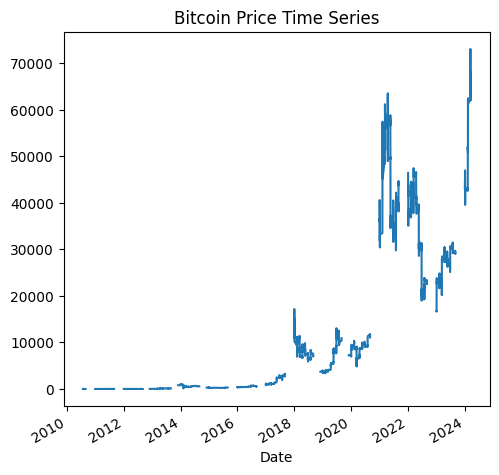

In [801]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa import stattools

missing = pd.isnull(bitcoin_data['Price'])

# Filtrar los datos para eliminar valores faltantes
bitcoin_data = bitcoin_data.loc[~missing, :]

# Graficar los precios de Bitcoin
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(1,1,1)
bitcoin_data['Price'].plot(ax=ax)
ax.set_title('Bitcoin Price Time Series')

# Prueba de Dickey-Fuller aumentada
adf_result = stattools.adfuller(bitcoin_data['Price'], autolag='AIC')
print('p-value of the ADF test for Bitcoin price:', adf_result[1])


El p-value de la prueba de Dickey fuller es mayor al 5%, lo cuál quiere decir que la serie no es estacionaria, lo cuál indica que las serie sigue una tendencia o tiene una estructura no constante a lo largo del tiempo.

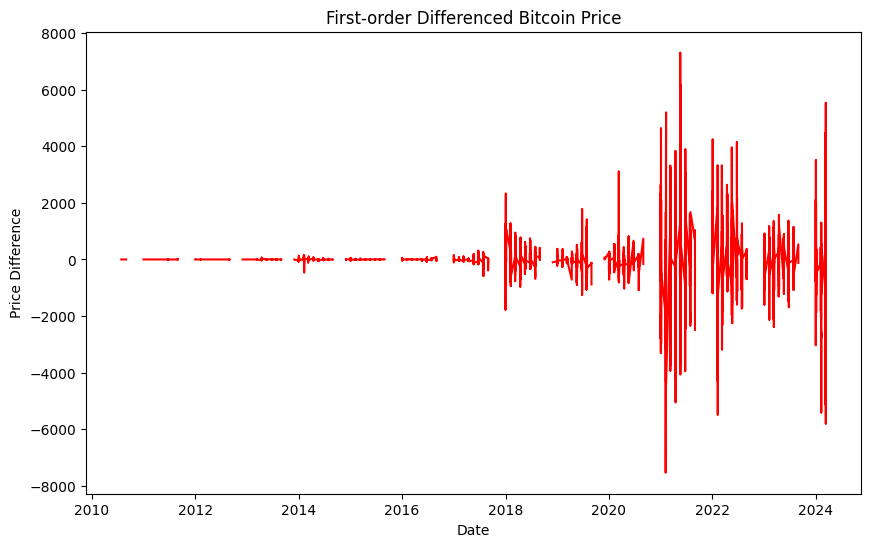

In [802]:
import pandas as pd
import matplotlib.pyplot as plt

bitcoin_data['Price_diff'] = bitcoin_data['Price'].diff()

plt.figure(figsize=(10, 6))
plt.plot(bitcoin_data['Price_diff'], color='red')
plt.title("First-order Differenced Bitcoin Price")
plt.xlabel("Date")
plt.ylabel("Price Difference")
plt.show()


In [803]:
from statsmodels.tsa.stattools import adfuller
price_diff = bitcoin_data['Price_diff'].dropna()
result = adfuller(price_diff)
print(f'p-value: {result[1]}')

# Interpretación
if result[1] < 0.05:
    print("La serie diferenciada es estacionaria (p-valor < 0.05).")
else:
    print("La serie diferenciada no es estacionaria (p-valor >= 0.05).")


p-value: 1.2757808100480691e-18
La serie diferenciada es estacionaria (p-valor < 0.05).


In [804]:
print(bitcoin_data)

              Price     Open     High      Low      Vol. Change %  Year  \
Date                                                                      
2024-03-12  67211.9  64036.5  67587.8  63812.9   65590.0    4.96%  2024   
2024-03-12  64037.8  63785.6  65972.4  63074.9   35110.0    0.40%  2024   
2024-03-12  63785.5  65501.5  66633.3  62328.3   72430.0   -2.62%  2024   
2024-03-12  65503.8  67860.0  68161.7  64616.1   75260.0   -3.46%  2024   
2024-03-12  67854.0  62046.8  68029.5  60850.9  133530.0    9.35%  2024   
...             ...      ...      ...      ...       ...      ...   ...   
2010-07-29      0.1      0.1      0.1      0.1    2160.0    0.00%  2010   
2010-07-29      0.1      0.1      0.1      0.1     580.0    0.00%  2010   
2010-07-29      0.1      0.1      0.1      0.1     260.0    0.00%  2010   
2010-07-29      0.1      0.1      0.1      0.1     570.0    0.00%  2010   
2010-07-28      0.1      0.0      0.1      0.1      80.0    0.00%  2010   

            Month  Week 

El gráfico de la serie diferenciada, no presenta una tendencia persistente. el p-value es menor del 5%, lo cuál confirma que la serie diferenciada es estacionaria. 

### Item 6.
 Mediante agregación por grupos analice el comportamiento de la media y desviación estándar,
 agrupando por semanas, días, meses. Además, para estas agrupaciones, calcule estadísticos
 móviles. Dibuje la distribución de frecuencias para diferentes lags como se realizó en las notas del curos

6.1 Comportamiento de la media

In [805]:
import pandas as pd
import matplotlib.pyplot as plt


In [806]:
bitcoin_data['Price_diff'] = pd.to_numeric(bitcoin_data['Price_diff'], errors='coerce')
bitcoin_data = bitcoin_data.dropna(subset=['Price_diff'])

Agrupación

In [807]:
datos_diarios = bitcoin_data['Price_diff'].resample('D').agg(['mean', 'std'])
datos_diarios = datos_diarios.dropna(subset=['mean', 'std'])
print(datos_diarios.head(10))


                mean       std
Date                          
2010-07-29  0.000000  0.000000
2010-07-30  0.000000  0.000000
2010-08-31  0.000000  0.000000
2011-01-01  0.000000  0.000000
2011-01-02  0.000000  0.057735
2011-01-03 -0.014286  0.037796
2011-01-04 -0.014286  0.037796
2011-02-05 -0.033333  0.051640
2011-02-06 -0.028571  0.111270
2011-02-07  0.042857  0.053452


In [808]:
datos_semanales = bitcoin_data['Price_diff'].resample('W').agg(['mean', 'std'])
datos_semanales = datos_semanales.dropna(subset=['mean', 'std'])
print(datos_semanales.head(10))


                mean       std
Date                          
2010-08-01  0.000000  0.000000
2010-09-05  0.000000  0.000000
2011-01-02  0.000000  0.039223
2011-01-09 -0.026667  0.059362
2011-02-06 -0.030769  0.085485
2011-02-13  0.013333  0.074322
2011-03-13  0.003226  0.040693
2011-04-17 -0.073333  0.213240
2011-05-22 -0.212903  0.697014
2011-06-26 -0.193333  2.915586


In [809]:
datos_mensuales = bitcoin_data['Price_diff'].resample('ME').agg(['mean', 'std'])
datos_mensuales = datos_mensuales.dropna(subset=['mean', 'std'])
print(datos_mensuales.head(10))


                mean       std
Date                          
2010-07-31  0.000000  0.000000
2010-08-31  0.000000  0.000000
2011-01-31 -0.013793  0.051576
2011-02-28 -0.007143  0.081325
2011-03-31  0.003226  0.040693
2011-04-30 -0.073333  0.213240
2011-05-31 -0.212903  0.697014
2011-06-30 -0.193333  2.915586
2011-07-31  0.074194  0.540350
2011-08-31  0.757143  1.826524


In [810]:
print(bitcoin_data)

              Price     Open     High      Low      Vol. Change %  Year  \
Date                                                                      
2024-03-12  64037.8  63785.6  65972.4  63074.9   35110.0    0.40%  2024   
2024-03-12  63785.5  65501.5  66633.3  62328.3   72430.0   -2.62%  2024   
2024-03-12  65503.8  67860.0  68161.7  64616.1   75260.0   -3.46%  2024   
2024-03-12  67854.0  62046.8  68029.5  60850.9  133530.0    9.35%  2024   
2024-03-12  62050.0  67594.1  68099.6  61560.6  148080.0   -8.20%  2024   
...             ...      ...      ...      ...       ...      ...   ...   
2010-07-29      0.1      0.1      0.1      0.1    2160.0    0.00%  2010   
2010-07-29      0.1      0.1      0.1      0.1     580.0    0.00%  2010   
2010-07-29      0.1      0.1      0.1      0.1     260.0    0.00%  2010   
2010-07-29      0.1      0.1      0.1      0.1     570.0    0.00%  2010   
2010-07-28      0.1      0.0      0.1      0.1      80.0    0.00%  2010   

            Month  Week 

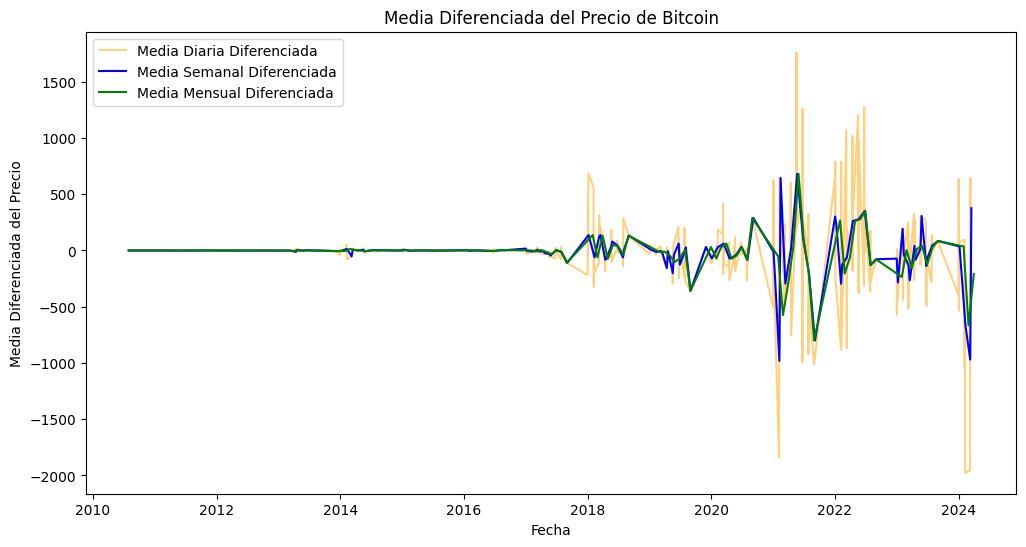

In [811]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(datos_diarios['mean'], label='Media Diaria Diferenciada', color='orange', alpha=0.5)
plt.plot(datos_semanales['mean'], label='Media Semanal Diferenciada', color='blue')
plt.plot(datos_mensuales['mean'], label='Media Mensual Diferenciada', color='green')
plt.xlabel('Fecha')
plt.ylabel('Media Diferenciada del Precio')
plt.title('Media Diferenciada del Precio de Bitcoin')
plt.legend()
plt.show()

En la gráfica se puede observar que aproximadamente desde el 2010 hasta el 2017 las medias muestran un comportamiento estable, el cuál llega a ser cercano a cero. A partir del 2017 se puede ver la volatilidad en los precios del Bitcoin. Además la media diaria muestra una mayor fluctuación a corto plazo, en cambio la media semanal y mensual presenta que el precio del bitcoin estuvo mas suavizado

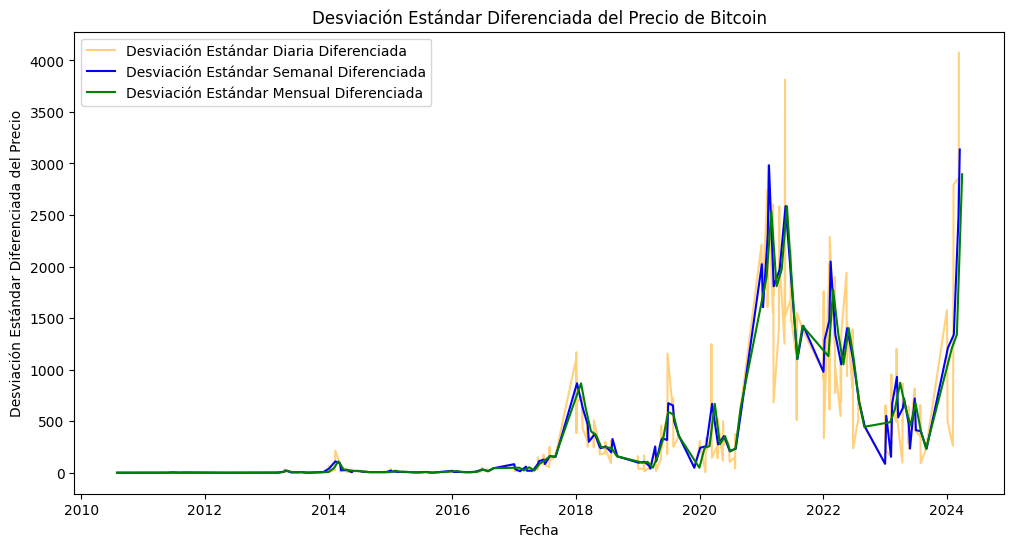

In [812]:
plt.figure(figsize=(12, 6))
plt.plot(datos_diarios['std'], label='Desviación Estándar Diaria Diferenciada', color='orange', alpha=0.5)
plt.plot(datos_semanales['std'], label='Desviación Estándar Semanal Diferenciada', color='blue')
plt.plot(datos_mensuales['std'], label='Desviación Estándar Mensual Diferenciada', color='green')
plt.xlabel('Fecha')
plt.ylabel('Desviación Estándar Diferenciada del Precio')
plt.title('Desviación Estándar Diferenciada del Precio de Bitcoin')
plt.legend()
plt.show()


Desde 2010 hasta 2017 el precio del Bitocin no representaba gran variabilidad, además se puede observar que apartr del 2017 hay presencia de picos, debido a la alta volatilidad del Bitcoin, además como se observo en la gráfica de promedio, las graficas diarias muestran cambios mas abruptos y con alta volatilidad

En los gráficos se puede observar que hay mucha variabilidad a corto plazo, en cambio la media semanal suaviza algunas fluctuaciones y en la mensual si se puede observar aún mas sauvizada.En el 2020, parece haber mayor valitilidad 

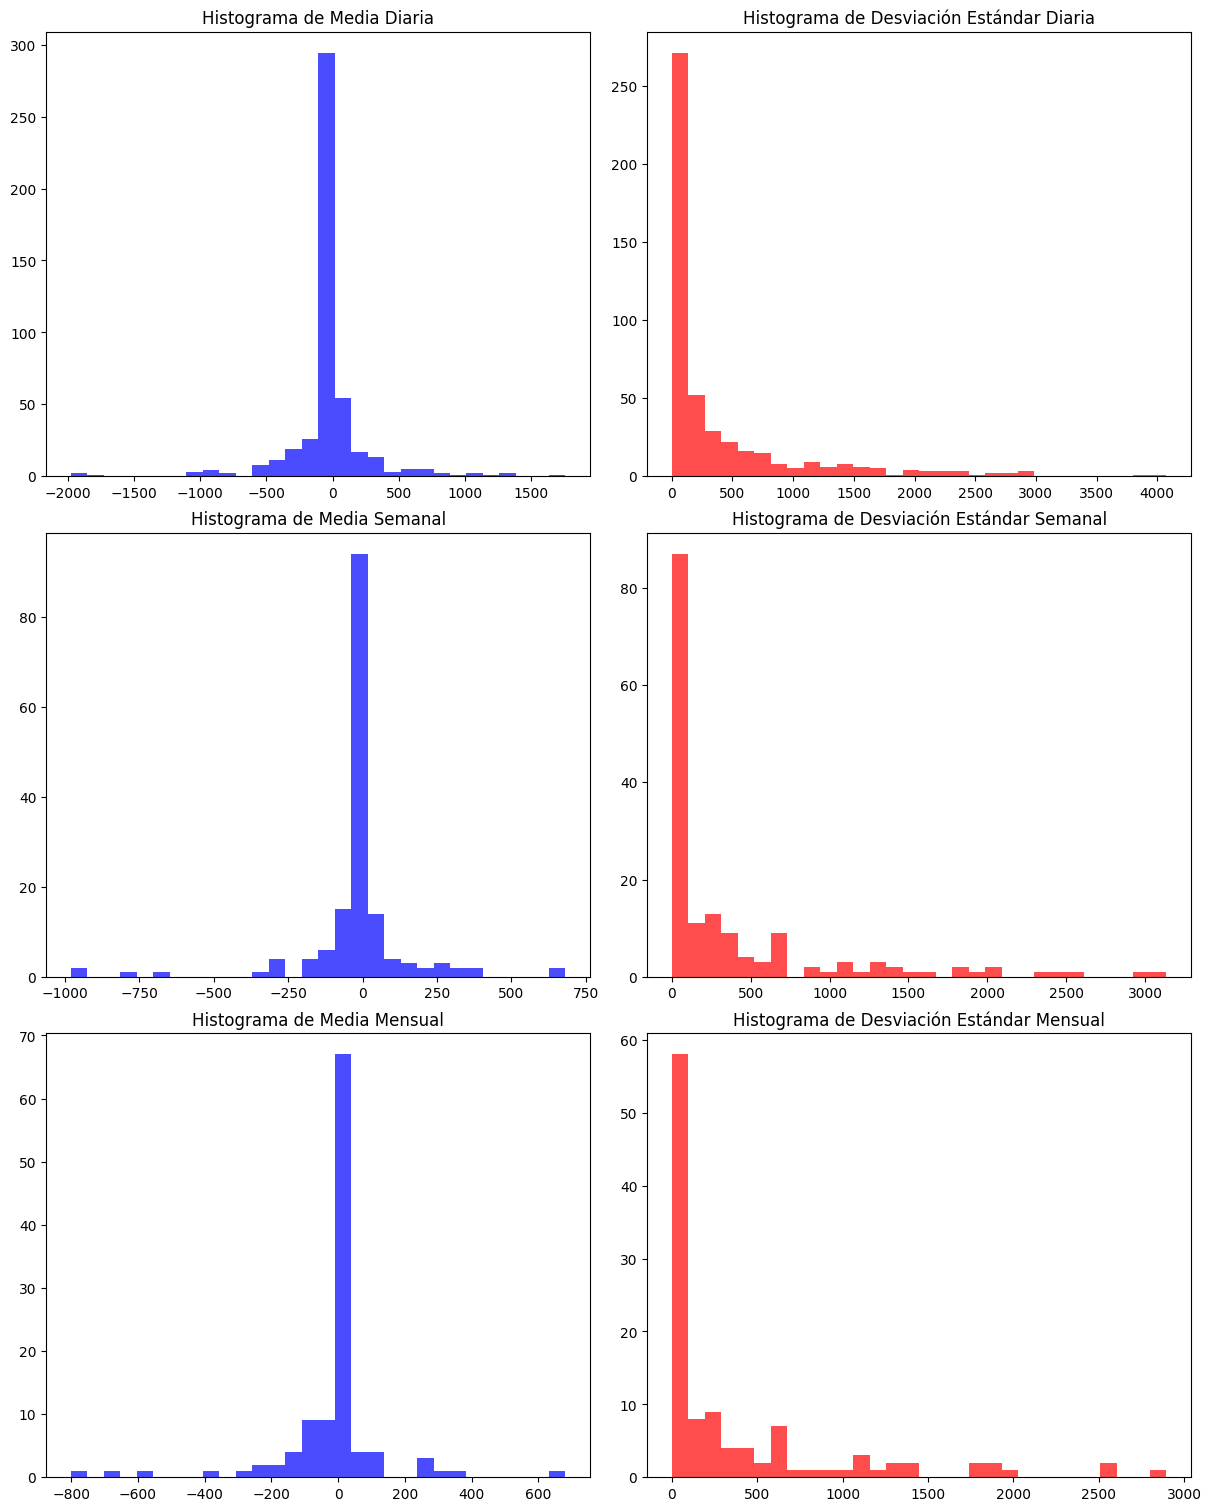

In [813]:
import matplotlib.pyplot as plt

# Desactivar temporalmente el uso de LaTeX
plt.rcParams['text.usetex'] = False

fig, axs = plt.subplots(3, 2, figsize=(12, 15), constrained_layout=True)

axs[0, 0].hist(datos_diarios['mean'].dropna(), bins=30, alpha=0.7, color='blue')
axs[0, 0].set_title('Histograma de Media Diaria')
axs[0, 1].hist(datos_diarios['std'].dropna(), bins=30, alpha=0.7, color='red')
axs[0, 1].set_title('Histograma de Desviación Estándar Diaria')

axs[1, 0].hist(datos_semanales['mean'].dropna(), bins=30, alpha=0.7, color='blue')
axs[1, 0].set_title('Histograma de Media Semanal')
axs[1, 1].hist(datos_semanales['std'].dropna(), bins=30, alpha=0.7, color='red')
axs[1, 1].set_title('Histograma de Desviación Estándar Semanal')

axs[2, 0].hist(datos_mensuales['mean'].dropna(), bins=30, alpha=0.7, color='blue')
axs[2, 0].set_title('Histograma de Media Mensual')
axs[2, 1].hist(datos_mensuales['std'].dropna(), bins=30, alpha=0.7, color='red')
axs[2, 1].set_title('Histograma de Desviación Estándar Mensual')

fig.savefig('output_histogramas.png', bbox_inches='tight')
plt.show()

Los gráficos de la desviación esatandar muestra distribuciones sesgadas hacia la derecha, es decir que la mayoría de días,semanas o meses presentan una baja variabilidad, además se puede observar que la dispersión tiende a aumentar cuando es mayor el peridod de agrupación

En los gráficos de la media los histogramas tienen una alta concentración en los valores de cero, además se observan colas en los histogramas lo cuál se podría decir que es por presencia de datos atípicos  

### Item 7. 

Aplique las medias móviles M(2) t (t,t+1) , M(4) t , M(4) t , M(3) (t−1,t+1) t y M(3) a la serie  del precio de cierre de BTC-USD. Posteriormente, úselas para remover tendencia y aplique la prueba de Dickey Fuller y LJung Box para verificar si se logró estacionariedad

M(2)

In [814]:
#M(2)

bitcoin_data['M2'] = bitcoin_data['Price'].rolling(window=2).mean()
print(bitcoin_data[['Price', 'M2']].head(10))

              Price        M2
Date                         
2024-03-12  64037.8       NaN
2024-03-12  63785.5  63911.65
2024-03-12  65503.8  64644.65
2024-03-12  67854.0  66678.90
2024-03-12  62050.0  64952.00
2024-03-12  67594.1  64822.05
2024-03-11  68391.2  67992.65
2024-03-11  65314.2  66852.70
2024-03-11  69463.7  67388.95
2024-03-11  71387.5  70425.60


In [815]:
# (M2(t, t+1))
bitcoin_data['M_2_t_t1'] = (bitcoin_data['Price'] + bitcoin_data['Price'].shift(-1)) / 2
print(bitcoin_data[['Price', 'M_2_t_t1']].head(10))


              Price  M_2_t_t1
Date                         
2024-03-12  64037.8  63911.65
2024-03-12  63785.5  64644.65
2024-03-12  65503.8  66678.90
2024-03-12  67854.0  64952.00
2024-03-12  62050.0  64822.05
2024-03-12  67594.1  67992.65
2024-03-11  68391.2  66852.70
2024-03-11  65314.2  67388.95
2024-03-11  69463.7  70425.60
2024-03-11  71387.5  72226.90


In [816]:
#M(4)
bitcoin_data['M_4'] = bitcoin_data['Price'].rolling(window=4).mean()
print(bitcoin_data[['Price', 'M_4']].head(10))


              Price        M_4
Date                          
2024-03-12  64037.8        NaN
2024-03-12  63785.5        NaN
2024-03-12  65503.8        NaN
2024-03-12  67854.0  65295.275
2024-03-12  62050.0  64798.325
2024-03-12  67594.1  65750.475
2024-03-11  68391.2  66472.325
2024-03-11  65314.2  65837.375
2024-03-11  69463.7  67690.800
2024-03-11  71387.5  68639.150


In [817]:
# (M_4_(t, t+1))
bitcoin_data['M_4_t_t1'] = (
    bitcoin_data['Price'].rolling(window=4).mean() + 
    bitcoin_data['Price'].shift(-4).rolling(window=4).mean()
) / 2

print(bitcoin_data[['Price', 'M_4', 'M_4_t_t1']].head(10))


              Price        M_4    M_4_t_t1
Date                                      
2024-03-12  64037.8        NaN         NaN
2024-03-12  63785.5        NaN         NaN
2024-03-12  65503.8        NaN         NaN
2024-03-12  67854.0  65295.275  65566.3250
2024-03-12  62050.0  64798.325  66244.5625
2024-03-12  67594.1  65750.475  67194.8125
2024-03-11  68391.2  66472.325  68140.1250
2024-03-11  65314.2  65837.375  68592.1500
2024-03-11  69463.7  67690.800  69848.2875
2024-03-11  71387.5  68639.150  70019.6250


In [818]:
#Relleno de valores de NaN, debido a que no hay suficieentes datos

bitcoin_data['M_4'] = bitcoin_data['M_4'].fillna(0)
bitcoin_data['M_4_t_t1'] = bitcoin_data['M_4_t_t1'].fillna(0)

print(bitcoin_data[['Price', 'M_4', 'M_4_t_t1']].head(10))


              Price        M_4    M_4_t_t1
Date                                      
2024-03-12  64037.8      0.000      0.0000
2024-03-12  63785.5      0.000      0.0000
2024-03-12  65503.8      0.000      0.0000
2024-03-12  67854.0  65295.275  65566.3250
2024-03-12  62050.0  64798.325  66244.5625
2024-03-12  67594.1  65750.475  67194.8125
2024-03-11  68391.2  66472.325  68140.1250
2024-03-11  65314.2  65837.375  68592.1500
2024-03-11  69463.7  67690.800  69848.2875
2024-03-11  71387.5  68639.150  70019.6250


M(3)

In [819]:
bitcoin_data['M_3'] = bitcoin_data['Price'].rolling(window=3).mean()
print(bitcoin_data[['Price', 'M_3']].head(10))


              Price           M_3
Date                             
2024-03-12  64037.8           NaN
2024-03-12  63785.5           NaN
2024-03-12  65503.8  64442.366667
2024-03-12  67854.0  65714.433333
2024-03-12  62050.0  65135.933333
2024-03-12  67594.1  65832.700000
2024-03-11  68391.2  66011.766667
2024-03-11  65314.2  67099.833333
2024-03-11  69463.7  67723.033333
2024-03-11  71387.5  68721.800000


In [820]:
#M3 (t-1, T+1)
bitcoin_data['M_3_t-1_t+1'] = bitcoin_data['Price'].shift(2)
# Mostrar algunos resultados
print(bitcoin_data[['Price', 'M_3_t-1_t+1']].head(10))
# Obtener el último valor calculado como pronóstico para el siguiente periodo
last_value_pred = bitcoin_data['M_3_t-1_t+1'].iloc[-1]
print("pronosticado para el siguiente periodo:", last_value_pred)


              Price  M_3_t-1_t+1
Date                            
2024-03-12  64037.8          NaN
2024-03-12  63785.5          NaN
2024-03-12  65503.8      64037.8
2024-03-12  67854.0      63785.5
2024-03-12  62050.0      65503.8
2024-03-12  67594.1      67854.0
2024-03-11  68391.2      62050.0
2024-03-11  65314.2      67594.1
2024-03-11  69463.7      68391.2
2024-03-11  71387.5      65314.2
pronosticado para el siguiente periodo: 0.1


In [821]:
#Relleno de valores de NaN, debido a que no hay suficieentes datos

bitcoin_data['M_3'] = bitcoin_data['M_3'].fillna(0)
bitcoin_data['M_3_t-1_t+1'] = bitcoin_data['M_3_t-1_t+1'].fillna(0)

print(bitcoin_data[['Price', 'M_4', 'M_4_t_t1']].head(10))


              Price        M_4    M_4_t_t1
Date                                      
2024-03-12  64037.8      0.000      0.0000
2024-03-12  63785.5      0.000      0.0000
2024-03-12  65503.8      0.000      0.0000
2024-03-12  67854.0  65295.275  65566.3250
2024-03-12  62050.0  64798.325  66244.5625
2024-03-12  67594.1  65750.475  67194.8125
2024-03-11  68391.2  66472.325  68140.1250
2024-03-11  65314.2  65837.375  68592.1500
2024-03-11  69463.7  67690.800  69848.2875
2024-03-11  71387.5  68639.150  70019.6250


Remover tendencia de las medias moviles

Prueba de Dickey Fuller

In [822]:
bitcoin_data['Detrended_M2'] = bitcoin_data['Price'] - bitcoin_data['M2']
bitcoin_data['Detrended_M3'] = bitcoin_data['Price'] - bitcoin_data['M_3']
bitcoin_data['Detrended_M4'] = bitcoin_data['Price'] - bitcoin_data['M_4']
bitcoin_data['Detrended_M2_special'] = bitcoin_data['Price'] - bitcoin_data['M_2_t_t1']
bitcoin_data['Detrended_M3_special'] = bitcoin_data['Price'] - bitcoin_data['M_3_t-1_t+1']
bitcoin_data['Detrended_M4_special'] = bitcoin_data['Price'] - bitcoin_data['M_4_t_t1']

# Verifica que las columnas existan ahora
print(bitcoin_data[['Detrended_M2', 'Detrended_M3', 'Detrended_M4', 
                    'Detrended_M2_special', 'Detrended_M3_special', 'Detrended_M4_special']].head(10))



            Detrended_M2  Detrended_M3  Detrended_M4  Detrended_M2_special  \
Date                                                                         
2024-03-12           NaN  64037.800000     64037.800                126.15   
2024-03-12       -126.15  63785.500000     63785.500               -859.15   
2024-03-12        859.15   1061.433333     65503.800              -1175.10   
2024-03-12       1175.10   2139.566667      2558.725               2902.00   
2024-03-12      -2902.00  -3085.933333     -2748.325              -2772.05   
2024-03-12       2772.05   1761.400000      1843.625               -398.55   
2024-03-11        398.55   2379.433333      1918.875               1538.50   
2024-03-11      -1538.50  -1785.633333      -523.175              -2074.75   
2024-03-11       2074.75   1740.666667      1772.900               -961.90   
2024-03-11        961.90   2665.700000      2748.350               -839.40   

            Detrended_M3_special  Detrended_M4_special  
Date  

In [823]:
print(bitcoin_data.columns)

Index(['Price', 'Open', 'High', 'Low', 'Vol.', 'Change %', 'Year', 'Month',
       'Week', 'Price_diff', 'M2', 'M_2_t_t1', 'M_4', 'M_4_t_t1', 'M_3',
       'M_3_t-1_t+1', 'Detrended_M2', 'Detrended_M3', 'Detrended_M4',
       'Detrended_M2_special', 'Detrended_M3_special', 'Detrended_M4_special'],
      dtype='object')


In [824]:
from statsmodels.tsa.stattools import adfuller

series_to_test = [
    'Detrended_M2', 'Detrended_M3', 'Detrended_M4', 
    'Detrended_M2_special', 'Detrended_M3_special', 'Detrended_M4_special'
]

for series in series_to_test:
    result = adfuller(bitcoin_data[series].dropna())
    print(f"Prueba de Dickey-Fuller para {series}:")
    print("Estadístico:", result[0])
    print("Valor p:", result[1])
    print("Conclusión:", "Estacionaria" if result[1] < 0.05 else "No Estacionaria")
    print("-" * 50)


Prueba de Dickey-Fuller para Detrended_M2:
Estadístico: -10.543135934028925
Valor p: 8.547251331773566e-19
Conclusión: Estacionaria
--------------------------------------------------
Prueba de Dickey-Fuller para Detrended_M3:
Estadístico: -10.96788692280554
Valor p: 8.01722384295987e-20
Conclusión: Estacionaria
--------------------------------------------------
Prueba de Dickey-Fuller para Detrended_M4:
Estadístico: -10.855893164566668
Valor p: 1.4880247329699229e-19
Conclusión: Estacionaria
--------------------------------------------------
Prueba de Dickey-Fuller para Detrended_M2_special:
Estadístico: -10.54313593402888
Valor p: 8.547251331775534e-19
Conclusión: Estacionaria
--------------------------------------------------
Prueba de Dickey-Fuller para Detrended_M3_special:
Estadístico: -10.728972754595134
Valor p: 3.0139786262895166e-19
Conclusión: Estacionaria
--------------------------------------------------
Prueba de Dickey-Fuller para Detrended_M4_special:
Estadístico: -13.99

Todas las pruebas, tienen un valor de P bajo, por lo tanto se rechaza la hipótesis nula de no estacionariedad, es decir que la serie es estacionaria

In [825]:
from statsmodels.stats.diagnostic import acorr_ljungbox
series_to_test = [
    'Detrended_M2', 'Detrended_M3', 'Detrended_M4', 
    'Detrended_M2_special', 'Detrended_M3_special', 'Detrended_M4_special'
]
for series in series_to_test:
    ljung_box_result = acorr_ljungbox(bitcoin_data[series].dropna(), lags=[10], return_df=True)
    print(f"Prueba de Ljung-Box para {series}:")
    print(ljung_box_result)
    print("-" * 50)

Prueba de Ljung-Box para Detrended_M2:
      lb_stat     lb_pvalue
10  74.708342  5.422002e-12
--------------------------------------------------
Prueba de Ljung-Box para Detrended_M3:
        lb_stat      lb_pvalue
10  1219.756304  7.886748e-256
--------------------------------------------------
Prueba de Ljung-Box para Detrended_M4:
        lb_stat  lb_pvalue
10  2721.863203        0.0
--------------------------------------------------
Prueba de Ljung-Box para Detrended_M2_special:
      lb_stat     lb_pvalue
10  74.708342  5.422002e-12
--------------------------------------------------
Prueba de Ljung-Box para Detrended_M3_special:
        lb_stat      lb_pvalue
10  1314.740356  2.520197e-276
--------------------------------------------------
Prueba de Ljung-Box para Detrended_M4_special:
        lb_stat  lb_pvalue
10  2456.464999        0.0
--------------------------------------------------


En todas las pruebas realizadas se puede observar autocorrelación significativa, debido a que los valores del P son pequeños

### Item 8.
Realice descomposición de la serie temporal del precio de cierre de BTC-USD usando medias
 moviles y además usando la librería statsmodels.tsa. Verifique al final independencia de los
 residuos mediante la prueba de LJung Box.

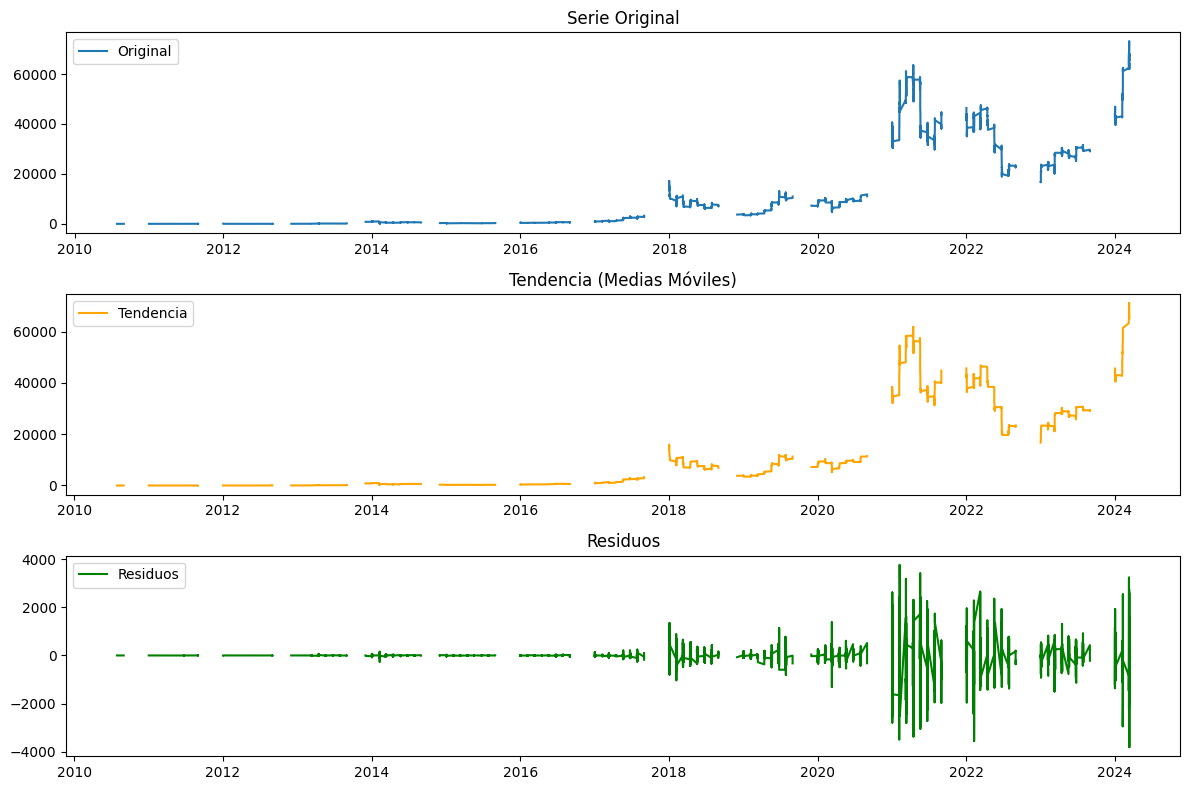

In [826]:
#Descomposición usando medias moviles
import pandas as pd
import matplotlib.pyplot as plt

bitcoin_data['Tendencia'] = bitcoin_data['Price'].rolling(window=6, center=True).mean()

# Calcular los residuos (componente aleatorio)
bitcoin_data['Residuos'] = bitcoin_data['Price'] - bitcoin_data['Tendencia']

# Graficar los componentes
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(bitcoin_data['Price'], label='Original')
plt.title('Serie Original')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(bitcoin_data['Tendencia'], label='Tendencia', color='orange')
plt.title('Tendencia (Medias Móviles)')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(bitcoin_data['Residuos'], label='Residuos', color='green')
plt.title('Residuos')
plt.legend()

plt.tight_layout()
plt.show()


La media movil de 6, captura la mayoría de fluctuaciones y suaviza las pequeñas variaciones, además en el gráfico se residuos muestra que desde el 2021 hasta 2023 hay peridodos que no estan explocados por la tendencia suavizada

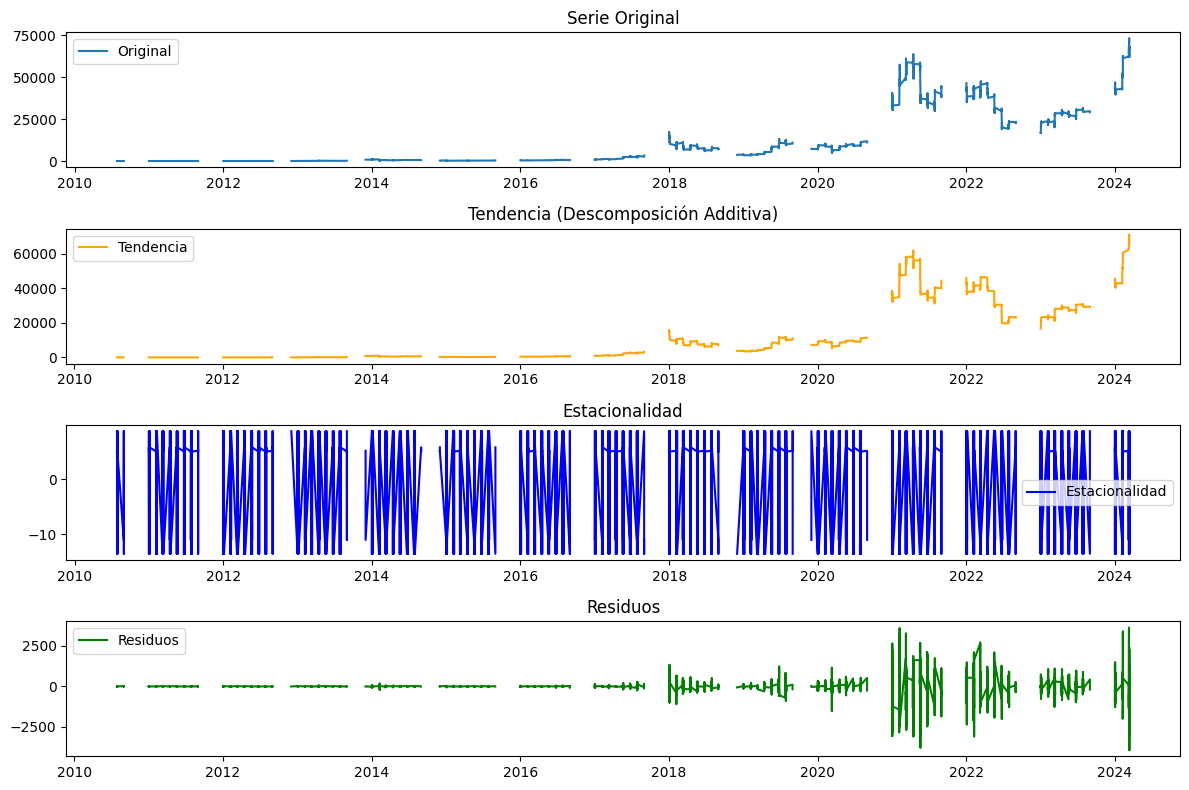

In [827]:
from statsmodels.tsa.seasonal import seasonal_decompose


decomposition = seasonal_decompose(bitcoin_data['Price'], model='additive', period=6)

tendencia = decomposition.trend
estacionalidad = decomposition.seasonal
residuos = decomposition.resid

# Graficar los componentes
plt.figure(figsize=(12, 8))
plt.subplot(4, 1, 1)
plt.plot(bitcoin_data['Price'], label='Original')
plt.title('Serie Original')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(tendencia, label='Tendencia', color='orange')
plt.title('Tendencia (Descomposición Additiva)')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(estacionalidad, label='Estacionalidad', color='blue')
plt.title('Estacionalidad')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(residuos, label='Residuos', color='green')
plt.title('Residuos')
plt.legend()

plt.tight_layout()
plt.show()

Antes del 2020, se puede observar que el precio es relativamente constante, a partir del 2020 es cuando presenta volatilidad en el precio. El patrón de los datos es repetitivo, lo cuál puede indicar que hay una componente ciclica en lso datos. y en los residuos se puede observar que hay variaciones las cuales no se explicna por la tendencia, ni por la estacionalidad

In [828]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box_result = acorr_ljungbox(bitcoin_data['Residuos'].dropna(), lags=[10], return_df=True)
print("Prueba de Ljung-Box para los residuos (Medias Móviles):")
print(ljung_box_result)


ljung_box_result_decompose = acorr_ljungbox(residuos.dropna(), lags=[10], return_df=True)
print("\nPrueba de Ljung-Box para los residuos (`seasonal_decompose`):")
print(ljung_box_result_decompose)


Prueba de Ljung-Box para los residuos (Medias Móviles):
       lb_stat      lb_pvalue
10  538.539676  2.538692e-109

Prueba de Ljung-Box para los residuos (`seasonal_decompose`):
       lb_stat      lb_pvalue
10  798.173663  5.095812e-165


Se puede observar que hay autocorrelación significativa en los residuos 

## Parte 2

 Repita el análisis anterior para las series de tiempo de: retorno acumulado diario y volatilidad,
 para diferentes ventanas. Para esto tenga en cuenta las siguientes definiciones e implemente ma
nualmente las funciones que definen cada serie de tiempo

In [829]:
#Calculo de retornos diarios
j = 0
at = []
for j in range(0, len(bitcoin_data['Price']) - 1):
    aj = (bitcoin_data['Price'].iloc[j + 1] - bitcoin_data['Price'].iloc[j]) / (bitcoin_data['Price'].iloc[j])
    at.append(aj)
at = np.nan_to_num(at)


In [830]:
# Agregar los retornos diarios al DataFrame (ten en cuenta que el primer valor será `None`)
bitcoin_data['Daily_Return'] = [None] + list(at)

# Verificar que los retornos diarios se calcularon correctamente
print(bitcoin_data[['Price', 'Daily_Return']].head(10))

              Price  Daily_Return
Date                             
2024-03-12  64037.8           NaN
2024-03-12  63785.5     -0.003940
2024-03-12  65503.8      0.026939
2024-03-12  67854.0      0.035879
2024-03-12  62050.0     -0.085537
2024-03-12  67594.1      0.089349
2024-03-11  68391.2      0.011792
2024-03-11  65314.2     -0.044991
2024-03-11  69463.7      0.063531
2024-03-11  71387.5      0.027695


In [831]:
# Retorno acumulado 
def cum_return(at):
    cum_ret = np.zeros(len(at))
    for j in range(0, len(at)):
        if j == 0:
            cum_ret[j] = at[j]
        else:
            cum_ret[j] = at[j] + cum_ret[j - 1]
    return cum_ret

ret_acum = cum_return(at)

In [832]:

retorno_acumulado = cum_return(at)

retorno_acumulado_series = pd.Series([None] + list(retorno_acumulado), index=bitcoin_data.index)

retorno_acumulado_series = retorno_acumulado_series.reindex(bitcoin_data.index)

bitcoin_data['Retorno_Acumulado'] = retorno_acumulado_series

print(bitcoin_data[['Daily_Return', 'Retorno_Acumulado']].head(10))


            Daily_Return  Retorno_Acumulado
Date                                       
2024-03-12           NaN                NaN
2024-03-12     -0.003940          -0.003940
2024-03-12      0.026939           0.022999
2024-03-12      0.035879           0.058878
2024-03-12     -0.085537          -0.026659
2024-03-12      0.089349           0.062690
2024-03-11      0.011792           0.074482
2024-03-11     -0.044991           0.029491
2024-03-11      0.063531           0.093023
2024-03-11      0.027695           0.120718


In [833]:
#Volatilidad
def volatility(w, at):
    vols = []
    for t in range(0, len(at) - w + 1):
        sqr = []
        r_list = at[t:t + w]
        miu = (1 / w) * (sum(r_list))
        
        for r in r_list:
            dif = r - miu
            sqr.append(dif ** 2)
        
        # Verificar si la varianza es negativa o NaN
        var = (1 / (w - 1)) * sum(sqr)
        if var < 0 or np.isnan(var) or np.isinf(var):
            vol = np.nan
        else:
            vol = np.sqrt(max(var, 0))
        
        vols.append(vol)
    
    vols = pd.Series(vols)
    return vols

# Calcular la volatilidad para ventanas de 7, 14, 21 y 28 días
ventanas = [7, 14, 21, 28]
for w in ventanas:
    vol = volatility(w, at)
    

    if len(vol) < len(bitcoin_data):
        bitcoin_data[f'Volatilidad_{w}d'] = [None] * (w - 1) + list(vol) + [None] * (len(bitcoin_data) - len(vol) - (w - 1))
    else:
        bitcoin_data[f'Volatilidad_{w}d'] = [None] * (w - 1) + list(vol)


print(bitcoin_data[['Daily_Return', 'Volatilidad_7d', 'Volatilidad_14d', 'Volatilidad_21d', 'Volatilidad_28d']].head(15))


#w=7, 14, 21, 28


            Daily_Return  Volatilidad_7d  Volatilidad_14d  Volatilidad_21d  \
Date                                                                         
2024-03-12           NaN             NaN              NaN              NaN   
2024-03-12     -0.003940             NaN              NaN              NaN   
2024-03-12      0.026939             NaN              NaN              NaN   
2024-03-12      0.035879             NaN              NaN              NaN   
2024-03-12     -0.085537             NaN              NaN              NaN   
2024-03-12      0.089349             NaN              NaN              NaN   
2024-03-11      0.011792        0.056814              NaN              NaN   
2024-03-11     -0.044991        0.060785              NaN              NaN   
2024-03-11      0.063531        0.060813              NaN              NaN   
2024-03-11      0.027695        0.060247              NaN              NaN   
2024-03-11      0.023517        0.046199              NaN       

### Item 2.
Identifique si existen datos faltantes y realice su imputación usando alguna de las técnicas
 básicas estudiadas durante el curso.

In [834]:
hay_faltantes = bitcoin_data.isnull().values.any()
print(f"¿Hay valores faltantes? {hay_faltantes}")

¿Hay valores faltantes? True


In [835]:
filas_faltantes = bitcoin_data[bitcoin_data[['Retorno_Acumulado', 'Volatilidad_7d', 'Volatilidad_14d', 'Volatilidad_21d', 'Volatilidad_28d']].isna().any(axis=1)]
print(filas_faltantes)

              Price     Open     High      Low      Vol. Change %  Year  \
Date                                                                      
2024-03-12  64037.8  63785.6  65972.4  63074.9   35110.0    0.40%  2024   
2024-03-12  63785.5  65501.5  66633.3  62328.3   72430.0   -2.62%  2024   
2024-03-12  65503.8  67860.0  68161.7  64616.1   75260.0   -3.46%  2024   
2024-03-12  67854.0  62046.8  68029.5  60850.9  133530.0    9.35%  2024   
2024-03-12  62050.0  67594.1  68099.6  61560.6  148080.0   -8.20%  2024   
2024-03-12  67594.1  68389.7  68920.1  66601.4   78070.0   -1.17%  2024   
2024-03-11  68391.2  65314.2  68857.7  64605.5   66070.0    4.71%  2024   
2024-03-11  65314.2  69456.5  70037.0  64971.0   75820.0   -5.97%  2024   
2024-03-11  69463.7  71387.1  72398.1  65765.6  148590.0   -2.69%  2024   
2024-03-11  71387.5  73066.7  73740.9  68717.2  109430.0   -2.30%  2024   
2024-03-11  73066.3  71461.9  73623.5  71338.4   77180.0    2.23%  2024   
2024-03-11  71470.2  7209

In [836]:
filas_faltantes = bitcoin_data[['Retorno_Acumulado', 'Volatilidad_7d', 'Volatilidad_14d', 'Volatilidad_21d', 'Volatilidad_28d']].isna().sum()
print(filas_faltantes)

Retorno_Acumulado     1
Volatilidad_7d        7
Volatilidad_14d      14
Volatilidad_21d      21
Volatilidad_28d      28
dtype: int64


Hay 1 dato faltante del retorno acumulado, 7 de la volatilidad con w=7,14 de la volatilidad con w=14,21 de la volatilidad con w=21,28 de la volatilidad con w=28

In [837]:
pd.set_option('display.max_columns', None)
print(filas_faltantes)


Retorno_Acumulado     1
Volatilidad_7d        7
Volatilidad_14d      14
Volatilidad_21d      21
Volatilidad_28d      28
dtype: int64


In [838]:
print(bitcoin_data)

              Price     Open     High      Low      Vol. Change %  Year  \
Date                                                                      
2024-03-12  64037.8  63785.6  65972.4  63074.9   35110.0    0.40%  2024   
2024-03-12  63785.5  65501.5  66633.3  62328.3   72430.0   -2.62%  2024   
2024-03-12  65503.8  67860.0  68161.7  64616.1   75260.0   -3.46%  2024   
2024-03-12  67854.0  62046.8  68029.5  60850.9  133530.0    9.35%  2024   
2024-03-12  62050.0  67594.1  68099.6  61560.6  148080.0   -8.20%  2024   
...             ...      ...      ...      ...       ...      ...   ...   
2010-07-29      0.1      0.1      0.1      0.1    2160.0    0.00%  2010   
2010-07-29      0.1      0.1      0.1      0.1     580.0    0.00%  2010   
2010-07-29      0.1      0.1      0.1      0.1     260.0    0.00%  2010   
2010-07-29      0.1      0.1      0.1      0.1     570.0    0.00%  2010   
2010-07-28      0.1      0.0      0.1      0.1      80.0    0.00%  2010   

            Month  Week 

In [839]:
from IPython.display import display
display(filas_faltantes)


Retorno_Acumulado     1
Volatilidad_7d        7
Volatilidad_14d      14
Volatilidad_21d      21
Volatilidad_28d      28
dtype: int64

In [840]:
print(bitcoin_data.index.duplicated().sum())

4493


No hay datos duplicados

In [841]:
bitcoin_data.columns = bitcoin_data.columns.str.strip()

In [842]:
bitcoin_data.reset_index(inplace=True)


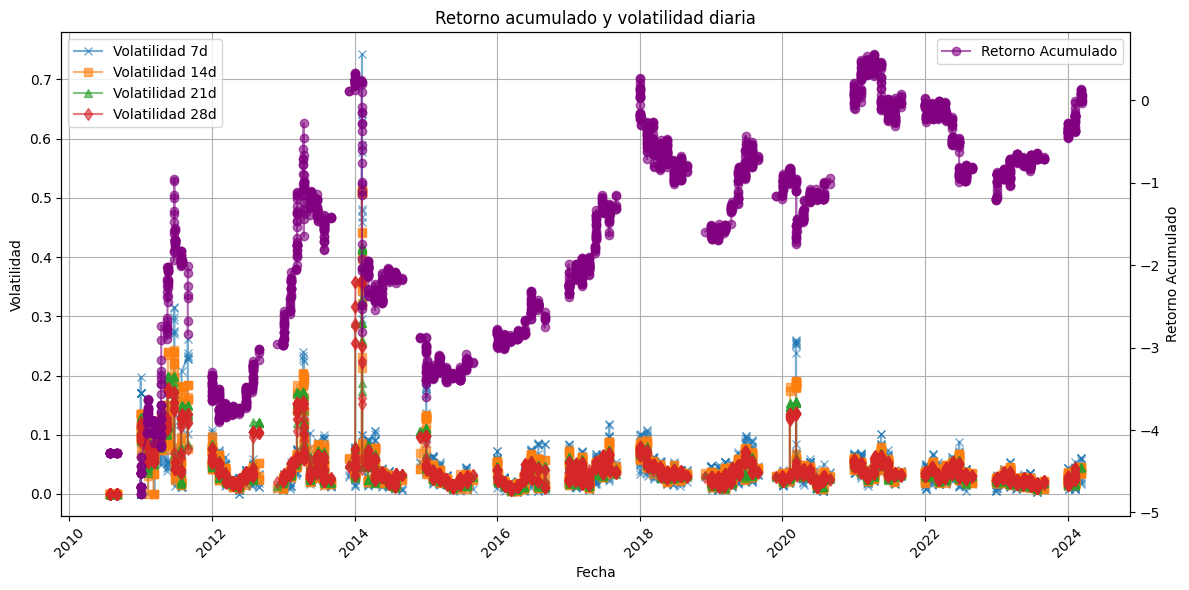

In [843]:
import matplotlib.pyplot as plt

# Crear la figura y el primer eje (para las volatilidades)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Graficar las series de volatilidad en el eje primario
ax1.plot(bitcoin_data['Date'], bitcoin_data['Volatilidad_7d'], label='Volatilidad 7d', linestyle='-', marker='x', alpha=0.6)
ax1.plot(bitcoin_data['Date'], bitcoin_data['Volatilidad_14d'], label='Volatilidad 14d', linestyle='-', marker='s', alpha=0.6)
ax1.plot(bitcoin_data['Date'], bitcoin_data['Volatilidad_21d'], label='Volatilidad 21d', linestyle='-', marker='^', alpha=0.6)
ax1.plot(bitcoin_data['Date'], bitcoin_data['Volatilidad_28d'], label='Volatilidad 28d', linestyle='-', marker='d', alpha=0.6)

# Configuración del eje primario
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Volatilidad')
ax1.grid(True)
ax1.legend(loc='upper left')
ax1.tick_params(axis='x', rotation=45)

# Crear un segundo eje y para el Retorno Acumulado
ax2 = ax1.twinx()
ax2.plot(bitcoin_data['Date'], bitcoin_data['Retorno_Acumulado'], label='Retorno Acumulado', color='purple', linestyle='-', marker='o', alpha=0.6)

# Configuración del eje secundario
ax2.set_ylabel('Retorno Acumulado')
ax2.legend(loc='upper right')

# Configuración del título y ajuste del diseño
plt.title('Retorno acumulado y volatilidad diaria')
plt.tight_layout()

plt.show()



El retorno acumualdo tiene un aumento de manera progresiva
La volatilidad en la mayoria del tiempo tiende a cero

In [844]:
bitcoin_data[['Retorno_Acumulado', 'Volatilidad_7d', 'Volatilidad_14d', 'Volatilidad_21d', 'Volatilidad_28d']] = bitcoin_data[['Retorno_Acumulado', 'Volatilidad_7d', 'Volatilidad_14d', 'Volatilidad_21d', 'Volatilidad_28d']].fillna(method='bfill')

C:\Users\FBA\AppData\Local\Temp\ipykernel_15160\2375788008.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  bitcoin_data[['Retorno_Acumulado', 'Volatilidad_7d', 'Volatilidad_14d', 'Volatilidad_21d', 'Volatilidad_28d']] = bitcoin_data[['Retorno_Acumulado', 'Volatilidad_7d', 'Volatilidad_14d', 'Volatilidad_21d', 'Volatilidad_28d']].fillna(method='bfill')


Para realizar la inputación de datos faltantes se utilizo el método Backfill debido a que en el caso del bitcoin, en especial al inicio de la serie donde se ubican faltantes presenta una estabilidad inicial, ya que el Bitcoin cuando empezó tenian un comportamiento estable 

In [845]:
datos_faltantes = bitcoin_data[['Retorno_Acumulado', 'Volatilidad_7d', 'Volatilidad_14d', 'Volatilidad_21d', 'Volatilidad_28d']].isna().sum()
print(datos_faltantes)


Retorno_Acumulado    0
Volatilidad_7d       1
Volatilidad_14d      1
Volatilidad_21d      1
Volatilidad_28d      1
dtype: int64


Despues de realizar el método de input "Backfill", no se presentan datos faltantes

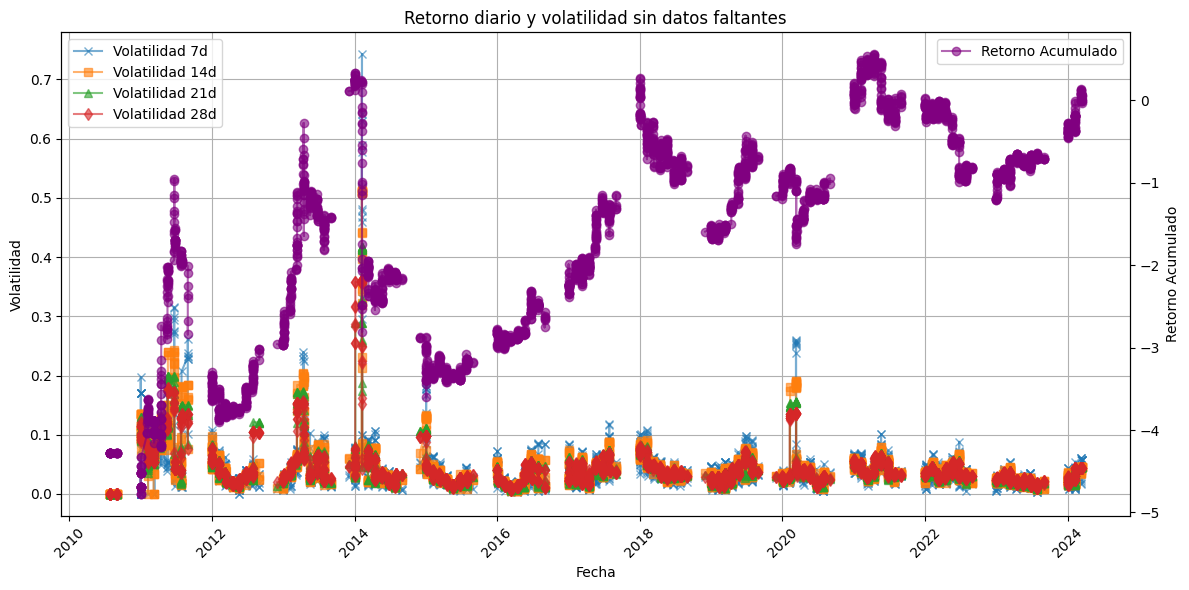

In [846]:
import matplotlib.pyplot as plt

# Crear la figura y el primer eje (para volatilidad)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Graficar las series de volatilidad en el eje primario
ax1.plot(bitcoin_data['Date'], bitcoin_data['Volatilidad_7d'], label='Volatilidad 7d', linestyle='-', marker='x', alpha=0.6)
ax1.plot(bitcoin_data['Date'], bitcoin_data['Volatilidad_14d'], label='Volatilidad 14d', linestyle='-', marker='s', alpha=0.6)
ax1.plot(bitcoin_data['Date'], bitcoin_data['Volatilidad_21d'], label='Volatilidad 21d', linestyle='-', marker='^', alpha=0.6)
ax1.plot(bitcoin_data['Date'], bitcoin_data['Volatilidad_28d'], label='Volatilidad 28d', linestyle='-', marker='d', alpha=0.6)

# Configuración del eje primario
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Volatilidad')
ax1.grid(True)
ax1.legend(loc='upper left')
ax1.tick_params(axis='x', rotation=45)

# Crear un segundo eje y para el Retorno Acumulado
ax2 = ax1.twinx()
ax2.plot(bitcoin_data['Date'], bitcoin_data['Retorno_Acumulado'], label='Retorno Acumulado', color='purple', linestyle='-', marker='o', alpha=0.6)

# Configuración del eje secundario
ax2.set_ylabel('Retorno Acumulado')
ax2.legend(loc='upper right')

# Configuración del título y ajuste del diseño
plt.title('Retorno diario y volatilidad sin datos faltantes')
plt.tight_layout()

plt.show()



Se puede observra que el retorno acumualdo tiene un comportamiento ascendente, con peridoos de estabilidad hasta 2011, después de esto se obsrvan incrementos significativos 
En la volatilidad se puede observar que al princpio tiende a ser baja durante gran parte del tiempo y presenta algunos picos, los cuáles pueden ser dados por eventos ocurridos en el mercado.

### Item 3.

Realice también un histograma con Plotly para representar el volumen tradeado diariamente
 (Volume)

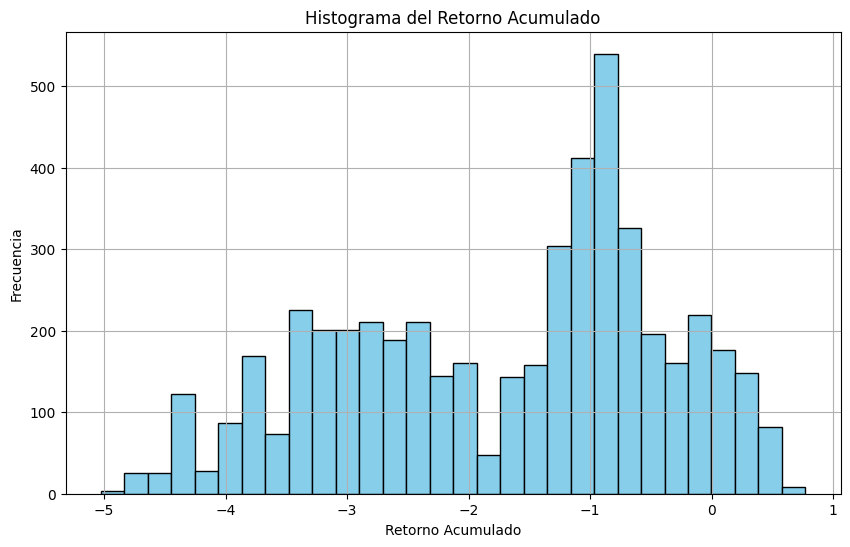

In [847]:
import matplotlib.pyplot as plt

# Asegúrate de reemplazar 'bitcoin_data' por el nombre de tu DataFrame
plt.figure(figsize=(10, 6))
plt.hist(bitcoin_data['Retorno_Acumulado'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histograma del Retorno Acumulado')
plt.xlabel('Retorno Acumulado')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()


En el histograma del retorno acumulado se puede observar, que la mayoría de los datos acumulados están en el extremo derecho y pocos valores se encunetran distribuidos en la parte izquierda, es decir que el Bitcoin muestra que la mayor parte del tiempo del retorno fue positivo.

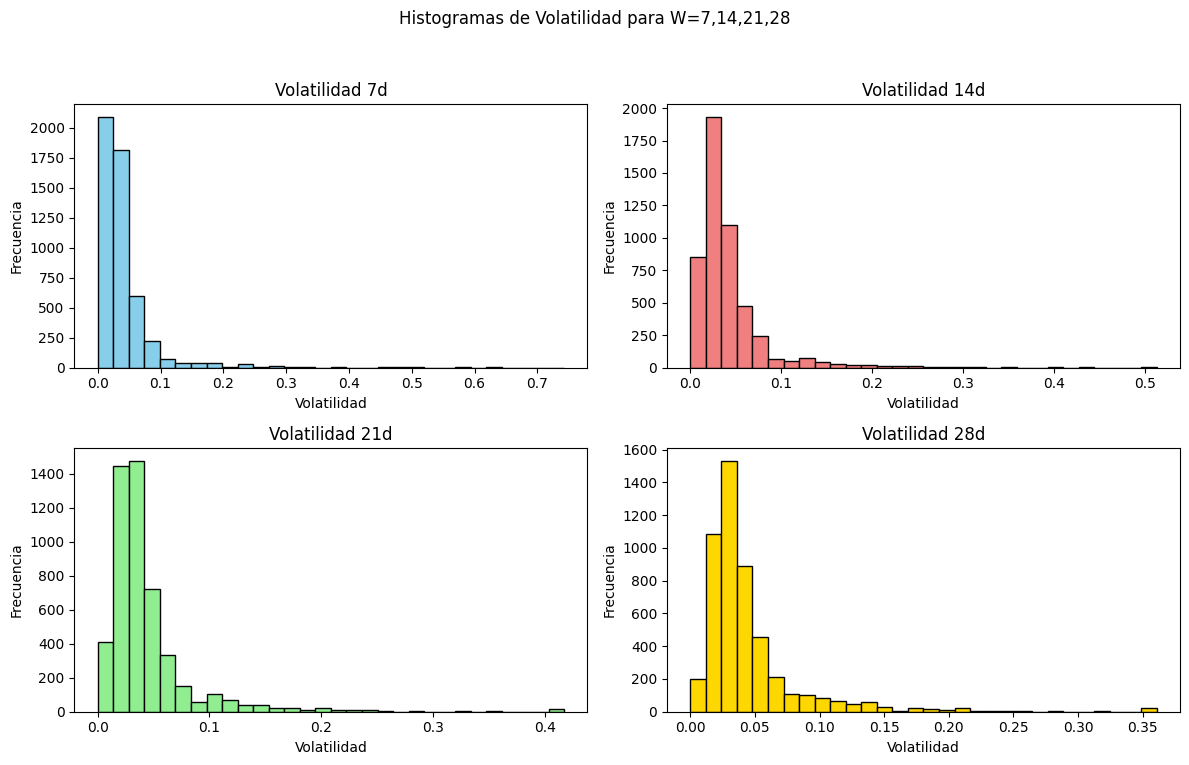

In [848]:
import matplotlib.pyplot as plt

# Configuración del tamaño de la figura
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Histograma de volatilidad para 7 días
axs[0, 0].hist(bitcoin_data['Volatilidad_7d'], bins=30, color='skyblue', edgecolor='black')
axs[0, 0].set_title('Volatilidad 7d')
axs[0, 0].set_xlabel('Volatilidad')
axs[0, 0].set_ylabel('Frecuencia')

# Histograma de volatilidad para 14 días
axs[0, 1].hist(bitcoin_data['Volatilidad_14d'], bins=30, color='lightcoral', edgecolor='black')
axs[0, 1].set_title('Volatilidad 14d')
axs[0, 1].set_xlabel('Volatilidad')
axs[0, 1].set_ylabel('Frecuencia')

# Histograma de volatilidad para 21 días
axs[1, 0].hist(bitcoin_data['Volatilidad_21d'], bins=30, color='lightgreen', edgecolor='black')
axs[1, 0].set_title('Volatilidad 21d')
axs[1, 0].set_xlabel('Volatilidad')
axs[1, 0].set_ylabel('Frecuencia')

# Histograma de volatilidad para 28 días
axs[1, 1].hist(bitcoin_data['Volatilidad_28d'], bins=30, color='gold', edgecolor='black')
axs[1, 1].set_title('Volatilidad 28d')
axs[1, 1].set_xlabel('Volatilidad')
axs[1, 1].set_ylabel('Frecuencia')

# Título general y ajustes finales
fig.suptitle("Histogramas de Volatilidad para W=7,14,21,28")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



EN los histogramas presentados para la volatilidad en 7,14,21,28 la distribución es segada hacía la derecha y donde la mayoría de datos están concentardos cerca de 0. Además se puede observar que los rangos de volatilidd son pequeños, es decir que el mercado del bitcoin ha tenido peridos constantes donde la fluctuaciones fueron pequeñas.
Además se observa que a medida que la ventana aumenta, la distribución se mantiene similar, es decir, que en las ventanas mas grandes/largas, es más probable ver fluctiaciones moderadas, que cuando se mira la volatilidad de los eventos pequeños.

### Item 4.

Realice graficos de subseries considerando agrupación por semana, mes y año. Utilice graficos
 de series de tiempo y boxplots para analizar estas subseries.

In [849]:
bitcoin_data.set_index('Date', inplace=True)
bitcoin_data.index = pd.to_datetime(bitcoin_data.index)

In [850]:

volatilidad_7_mes_mean = bitcoin_data['Volatilidad_7d'].resample('ME').mean()
volatilidad_14_mes_mean = bitcoin_data['Volatilidad_14d'].resample('ME').mean()
volatilidad_21_mes_mean = bitcoin_data['Volatilidad_21d'].resample('ME').mean()
volatilidad_28_mes_mean = bitcoin_data['Volatilidad_28d'].resample('ME').mean()
retorno_acumulado_mes_mean = bitcoin_data['Retorno_Acumulado'].resample('ME').mean()

volatilidad_7_sem_mean = bitcoin_data['Volatilidad_7d'].resample('W').mean()
volatilidad_14_sem_mean = bitcoin_data['Volatilidad_14d'].resample('W').mean()
volatilidad_21_sem_mean = bitcoin_data['Volatilidad_21d'].resample('W').mean()
volatilidad_28_sem_mean = bitcoin_data['Volatilidad_28d'].resample('W').mean()
retorno_acumulado_sem_mean = bitcoin_data['Retorno_Acumulado'].resample('W').mean()

volatilidad_7_año_mean = bitcoin_data['Volatilidad_7d'].resample('YE').mean()
volatilidad_14_año_mean = bitcoin_data['Volatilidad_14d'].resample('YE').mean()
volatilidad_21_año_mean = bitcoin_data['Volatilidad_21d'].resample('YE').mean()
volatilidad_28_año_mean = bitcoin_data['Volatilidad_28d'].resample('YE').mean()
retorno_acumulado_año_mean = bitcoin_data['Retorno_Acumulado'].resample('YE').mean()


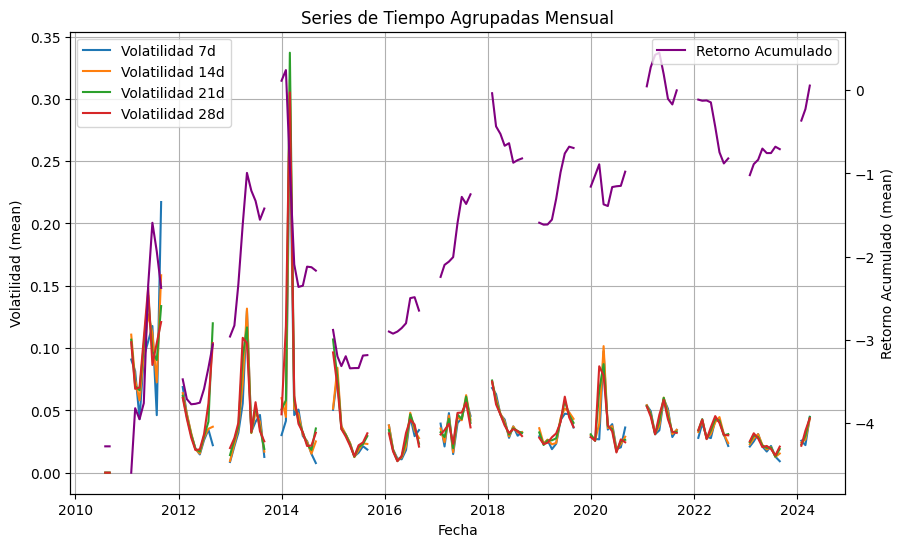

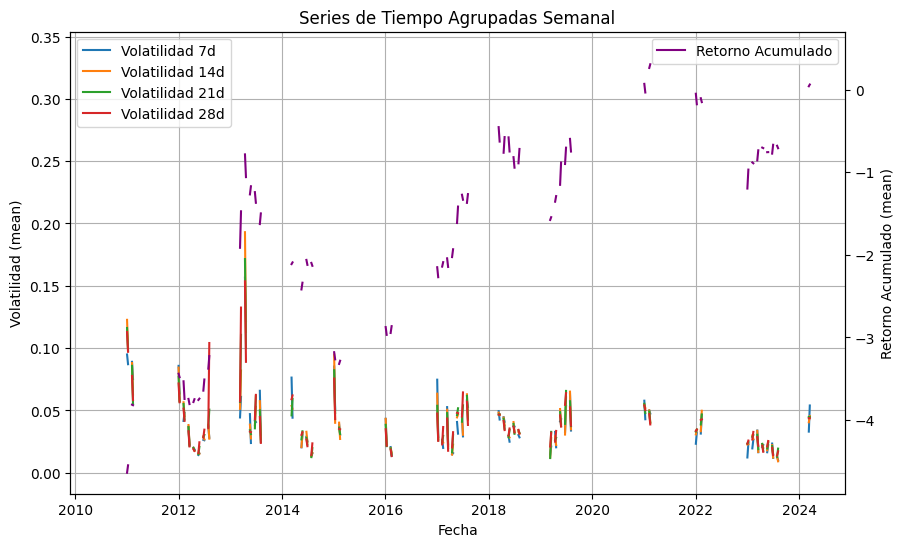

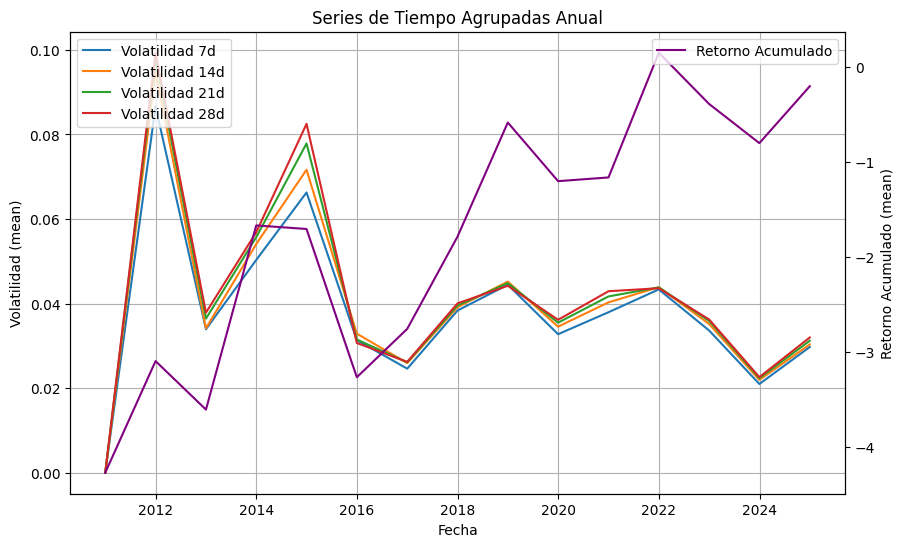

In [851]:
import matplotlib.pyplot as plt

# Diccionario de series agrupadas
series_agrupadas = {
    'Mensual': {
        'Volatilidad 7d': volatilidad_7_mes_mean,
        'Volatilidad 14d': volatilidad_14_mes_mean,
        'Volatilidad 21d': volatilidad_21_mes_mean,
        'Volatilidad 28d': volatilidad_28_mes_mean,
        'Retorno Acumulado': retorno_acumulado_mes_mean
    },
    'Semanal': {
        'Volatilidad 7d': volatilidad_7_sem_mean,
        'Volatilidad 14d': volatilidad_14_sem_mean,
        'Volatilidad 21d': volatilidad_21_sem_mean,
        'Volatilidad 28d': volatilidad_28_sem_mean,
        'Retorno Acumulado': retorno_acumulado_sem_mean
    },
    'Anual': {
        'Volatilidad 7d': volatilidad_7_año_mean,
        'Volatilidad 14d': volatilidad_14_año_mean,
        'Volatilidad 21d': volatilidad_21_año_mean,
        'Volatilidad 28d': volatilidad_28_año_mean,
        'Retorno Acumulado': retorno_acumulado_año_mean
    }
}

for agrupacion, series in series_agrupadas.items():
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Graficar series de volatilidad en el eje primario
    for nombre_serie, datos in series.items():
        if nombre_serie != 'Retorno Acumulado':
            ax1.plot(datos.index, datos, label=nombre_serie)
    
    ax1.set_title(f'Series de Tiempo Agrupadas {agrupacion}')
    ax1.set_xlabel('Fecha')
    ax1.set_ylabel('Volatilidad (mean)')
    ax1.legend(loc='upper left')
    ax1.grid(True)
    
    # Graficar el Retorno Acumulado en el eje secundario
    ax2 = ax1.twinx()
    ax2.plot(series['Retorno Acumulado'].index, series['Retorno Acumulado'], label='Retorno Acumulado', color='purple')
    ax2.set_ylabel('Retorno Acumulado (mean)')
    ax2.legend(loc='upper right')
    
    plt.show()



-Retorno acumulado y valatilidad mensual=En el retorno acumulado se puede observar un incremento de forma gradual desde el 2011, hasta el 2017, además presenta unos picos al rededor del 2013 hasta el 2016. En la voltidad se puede observar valores planos, por lo cuál se puede decir el la volatilidad del Bitcoin es estable

-Retorno acumulado y valatilidad semanal= el retorno acumulado semanal tiene un comportamiento similar al mensual, con la diferencia que la semanal tiene un poco más de detalle. En cambio la volatilidad se mantiene bajas durante la gran mayoría de periodos

-Retorno acumulado y valatilidad anual= en el retorno acumulado se muestra un crecimiento sostenido, donde tuvo su crecimeinto mas notable entre el 2012 y el 2014. Además se puede observar que la voaltilidad en las diferentes ventanas es plana, lo que queire decir es que esta se suaviza cuando se calculan los promedios mensuales.


Los gráficos mensual y semanal tienen una visión más al detalle, en cambio en el anual se ve logra observar la tendencia, pero sin tanto detalle



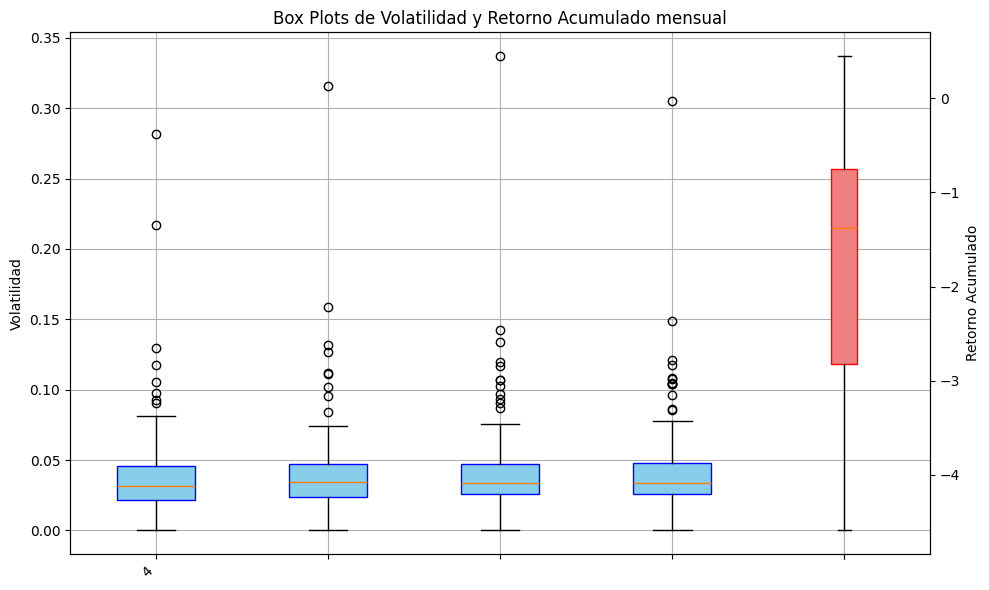

In [852]:
import numpy as np
import matplotlib.pyplot as plt

# Asegurarse de que no haya NaN o valores infinitos en cada lista
volatilidad_7_mes_mean = [x for x in volatilidad_7_mes_mean if not (np.isnan(x) or np.isinf(x))]
volatilidad_14_mes_mean = [x for x in volatilidad_14_mes_mean if not (np.isnan(x) or np.isinf(x))]
volatilidad_21_mes_mean = [x for x in volatilidad_21_mes_mean if not (np.isnan(x) or np.isinf(x))]
volatilidad_28_mes_mean = [x for x in volatilidad_28_mes_mean if not (np.isnan(x) or np.isinf(x))]
retorno_acumulado_mes_mean = [x for x in retorno_acumulado_mes_mean if not (np.isnan(x) or np.isinf(x))]

# Datos para volatilidades y nombres
volatilidades = [volatilidad_7_mes_mean, volatilidad_14_mes_mean, volatilidad_21_mes_mean, volatilidad_28_mes_mean]
nombres_volatilidades = ['Volatilidad 7d (Mensual)', 'Volatilidad 14d (Mensual)', 'Volatilidad 21d (Mensual)', 'Volatilidad 28d (Mensual)']

# Crear la figura y el primer eje
fig, ax1 = plt.subplots(figsize=(10, 6))

# Gráfico de cajas para las series de volatilidad en el eje primario
box1 = ax1.boxplot(volatilidades, positions=range(len(volatilidades)), patch_artist=True, 
                   boxprops=dict(facecolor="skyblue", color="blue"))
ax1.set_xticks(range(len(nombres_volatilidades) + 1))  # +1 para incluir la posición del retorno acumulado
ax1.set_xticklabels(nombres_volatilidades + ['Retorno Acumulado (Mensual)'], rotation=45, ha='right')
ax1.set_ylabel('Volatilidad')
ax1.set_title('Box Plots de Volatilidad y Retorno Acumulado mensual')
ax1.grid(True)

# Crear un eje secundario para el Retorno Acumulado y graficarlo como un boxplot en una posición separada
ax2 = ax1.twinx()
box2 = ax2.boxplot([retorno_acumulado_mes_mean], positions=[len(volatilidades)], patch_artist=True, 
                   boxprops=dict(facecolor="lightcoral", color="red"))
ax2.set_ylabel('Retorno Acumulado')

plt.tight_layout()
plt.show()



En la gráfica donde se cuentran los box plot, se puede observar que el de retorno acumulado se puede observar que hay una mediana, hay alta acumualción de datos entre el cuartil 1 y cuartil 3, además se observan outliers, que represnatn variaciones significatuvas.En los gráficos de volatilidad, esta es baja, en la ventana W=7, se observa que la volatilidad mensual es baja, además hay presencia de valores atípicos  y estos son peridos donde hubo mayor volatilidad;En la venatana W=14 la volatilidad también es baja, además hay presencia de valores atípicos; en w=21 la volatilidad es baja, inclusive se podría decir que es aún más baja que las mencionadas anteriormente, además tambien se observa presencia de outlier; por último en W=28 tiene el mismo patrón que las volatilidades anteriormente mencionadas.


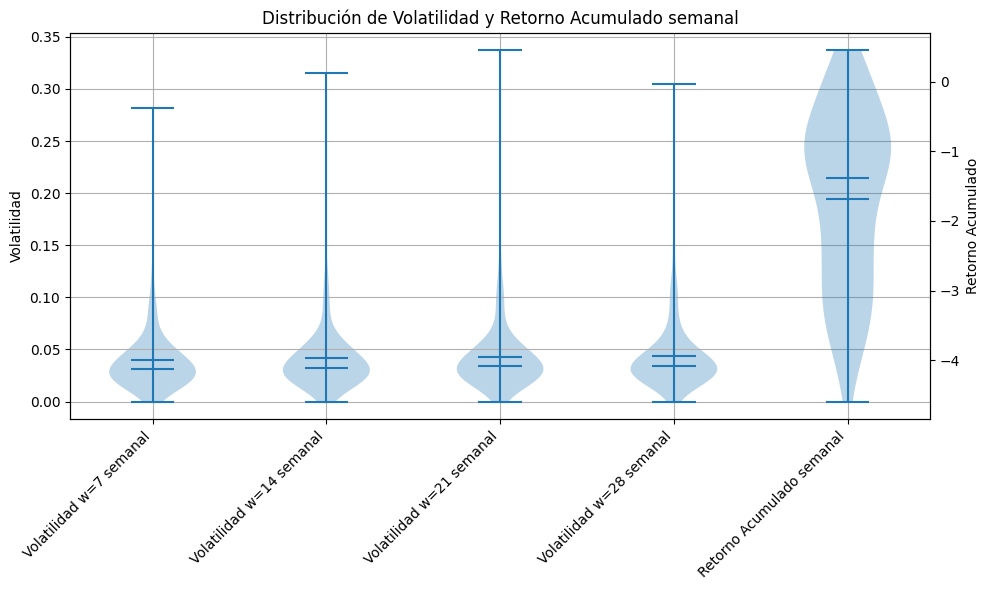

In [853]:
import numpy as np
import matplotlib.pyplot as plt

# Asegurarse de que no haya NaN o valores infinitos en cada lista
volatilidad_7_sem_mean = [x for x in volatilidad_7_sem_mean if not (np.isnan(x) or np.isinf(x))]
volatilidad_14_sem_mean = [x for x in volatilidad_14_sem_mean if not (np.isnan(x) or np.isinf(x))]
volatilidad_21_sem_mean = [x for x in volatilidad_21_sem_mean if not (np.isnan(x) or np.isinf(x))]
volatilidad_28_sem_mean = [x for x in volatilidad_28_sem_mean if not (np.isnan(x) or np.isinf(x))]
retorno_acumulado_mes_mean = [x for x in retorno_acumulado_mes_mean if not (np.isnan(x) or np.isinf(x))]

# Datos para volatilidades y nombres
volatilidades = [volatilidad_7_sem_mean, volatilidad_14_sem_mean, volatilidad_21_sem_mean, volatilidad_28_sem_mean]
nombres_volatilidades = ['Volatilidad w=7 semanal', 'Volatilidad w=14 semanal', 'Volatilidad w=21 semanal', 'Volatilidad w=28 semanal']

# Crear la figura
fig, ax1 = plt.subplots(figsize=(10, 6))

# Gráfico de violín para las series de volatilidad en el eje primario
violin1 = ax1.violinplot(volatilidades, showmeans=True, showmedians=True)
ax1.set_xticks(range(1, len(nombres_volatilidades) + 2))  # +2 para incluir espacio del eje secundario
ax1.set_xticklabels(nombres_volatilidades + ['Retorno Acumulado semanal'], rotation=45, ha='right')
ax1.set_ylabel('Volatilidad')
ax1.set_title('Distribución de Volatilidad y Retorno Acumulado semanal')
ax1.grid(True)

# Crear un eje secundario para el Retorno Acumulado y graficarlo como un violín en una posición separada
ax2 = ax1.twinx()
violin2 = ax2.violinplot([retorno_acumulado_mes_mean], positions=[len(volatilidades) + 1], showmeans=True, showmedians=True)
ax2.set_ylabel('Retorno Acumulado')

plt.tight_layout()
plt.show()


Los box plots de volatilidad muestran que la mediana de la volatilidad tiene media cero y baja variabilidad en la semana, presenta outliers esto es debido que hay semanas en las cuales se produce un aumento en el precio del Bitcoin, en cambio el box plot acumualdo semanal tiene una distribución amplia  con presencia de outliers lo cuapl indica que hay semanas en las cuales se observa una alta variación en el retorno 

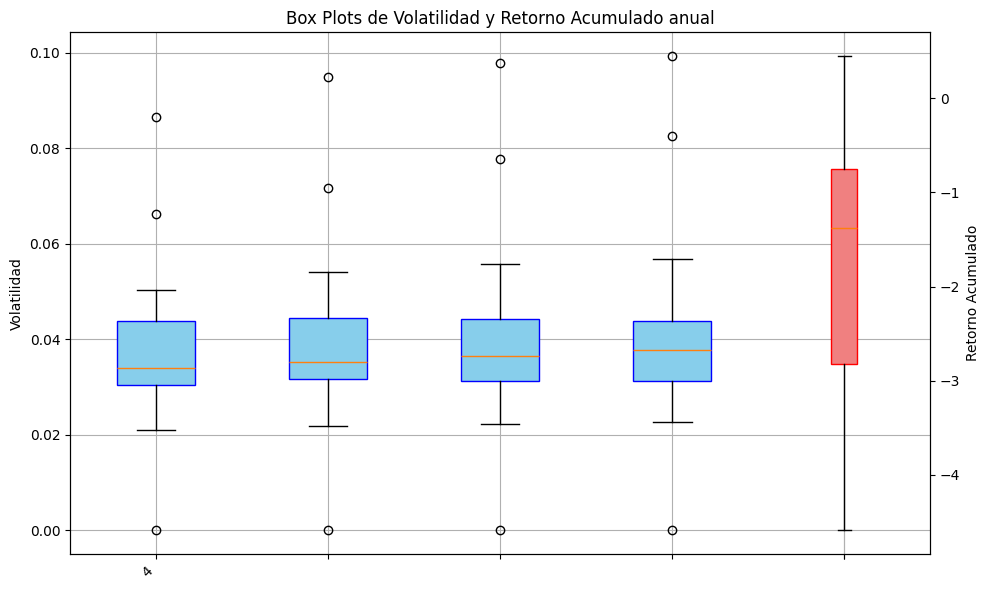

In [854]:
import numpy as np
import matplotlib.pyplot as plt

# Asegurarse de que no haya NaN o valores infinitos en cada lista
volatilidad_7_año_mean = [x for x in volatilidad_7_año_mean if not (np.isnan(x) or np.isinf(x))]
volatilidad_14_año_mean = [x for x in volatilidad_14_año_mean if not (np.isnan(x) or np.isinf(x))]
volatilidad_21_año_mean = [x for x in volatilidad_21_año_mean if not (np.isnan(x) or np.isinf(x))]
volatilidad_28_año_mean = [x for x in volatilidad_28_año_mean if not (np.isnan(x) or np.isinf(x))]
retorno_acumulado_mes_mean = [x for x in retorno_acumulado_mes_mean if not (np.isnan(x) or np.isinf(x))]

# Datos para volatilidades y nombres
volatilidades = [volatilidad_7_año_mean, volatilidad_14_año_mean, volatilidad_21_año_mean, volatilidad_28_año_mean]
nombres_volatilidades = ['Volatilidad w=7 anual', 'Volatilidad w=14 anual', 'Volatilidad w=21 anual', 'Volatilidad w=28 anual']

# Crear la figura y el primer eje
fig, ax1 = plt.subplots(figsize=(10, 6))

# Gráfico de cajas para las series de volatilidad en el eje primario
box1 = ax1.boxplot(volatilidades, positions=range(len(volatilidades)), patch_artist=True, 
                   boxprops=dict(facecolor="skyblue", color="blue"))
ax1.set_xticks(range(len(nombres_volatilidades) + 1))  # +1 para incluir la posición del retorno acumulado
ax1.set_xticklabels(nombres_volatilidades + ['Retorno Acumulado anual'], rotation=45, ha='right')
ax1.set_ylabel('Volatilidad')
ax1.set_title('Box Plots de Volatilidad y Retorno Acumulado anual')
ax1.grid(True)

# Crear un eje secundario para el Retorno Acumulado y graficarlo como un boxplot en una posición separada
ax2 = ax1.twinx()
box2 = ax2.boxplot([retorno_acumulado_mes_mean], positions=[len(volatilidades)], patch_artist=True, 
                   boxprops=dict(facecolor="lightcoral", color="red"))
ax2.set_ylabel('Retorno Acumulado')

plt.tight_layout()
plt.show()


Los box plot de volatilidad presentan valores con mediana cercana a cero, con cajas estrechas y una baja presencia de outlier por lo tanto la volatilidad se mantiene contastante anual. En cambio en el box plot de retornos acumulados se muestra una mayor variabilidad, con la mediana posicionada en el rango inferior, es decir, en promedio el creciemiento no es significativo, además hay presencia de outliers en donde el bitcoin pudo haber tenido altos y bajos

In [855]:
import pandas as pd

volatilidad_7_semanal = bitcoin_data['Volatilidad_7d'].resample('W').mean().fillna(method='ffill')
volatilidad_14_semanal = bitcoin_data['Volatilidad_14d'].resample('W').mean().fillna(method='ffill')
volatilidad_21_semanal = bitcoin_data['Volatilidad_21d'].resample('W').mean().fillna(method='ffill')
volatilidad_28_semanal = bitcoin_data['Volatilidad_28d'].resample('W').mean().fillna(method='ffill')
retorno_acumulado_semanal = bitcoin_data['Retorno_Acumulado'].resample('W').mean().fillna(method='ffill')

volatilidad_7_mensual = bitcoin_data['Volatilidad_7d'].resample('M').mean().fillna(method='ffill')
volatilidad_14_mensual = bitcoin_data['Volatilidad_14d'].resample('M').mean().fillna(method='ffill')
volatilidad_21_mensual = bitcoin_data['Volatilidad_21d'].resample('M').mean().fillna(method='ffill')
volatilidad_28_mensual = bitcoin_data['Volatilidad_28d'].resample('M').mean().fillna(method='ffill')
retorno_acumulado_mensual = bitcoin_data['Retorno_Acumulado'].resample('M').mean().fillna(method='ffill')

volatilidad_7_anual = bitcoin_data['Volatilidad_7d'].resample('Y').mean().fillna(method='ffill')
volatilidad_14_anual = bitcoin_data['Volatilidad_14d'].resample('Y').mean().fillna(method='ffill')
volatilidad_21_anual = bitcoin_data['Volatilidad_21d'].resample('Y').mean().fillna(method='ffill')
volatilidad_28_anual = bitcoin_data['Volatilidad_28d'].resample('Y').mean().fillna(method='ffill')
retorno_acumulado_anual = bitcoin_data['Retorno_Acumulado'].resample('Y').mean().fillna(method='ffill')


C:\Users\FBA\AppData\Local\Temp\ipykernel_15160\3555333478.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  volatilidad_7_semanal = bitcoin_data['Volatilidad_7d'].resample('W').mean().fillna(method='ffill')
C:\Users\FBA\AppData\Local\Temp\ipykernel_15160\3555333478.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  volatilidad_14_semanal = bitcoin_data['Volatilidad_14d'].resample('W').mean().fillna(method='ffill')
C:\Users\FBA\AppData\Local\Temp\ipykernel_15160\3555333478.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  volatilidad_21_semanal = bitcoin_data['Volatilidad_21d'].resample('W').mean().fillna(method='ffill')
C:\Users\FBA\AppData\Local\Temp\ipykernel_15160\3555333478.py:6: FutureWarning: Series.fillna with 

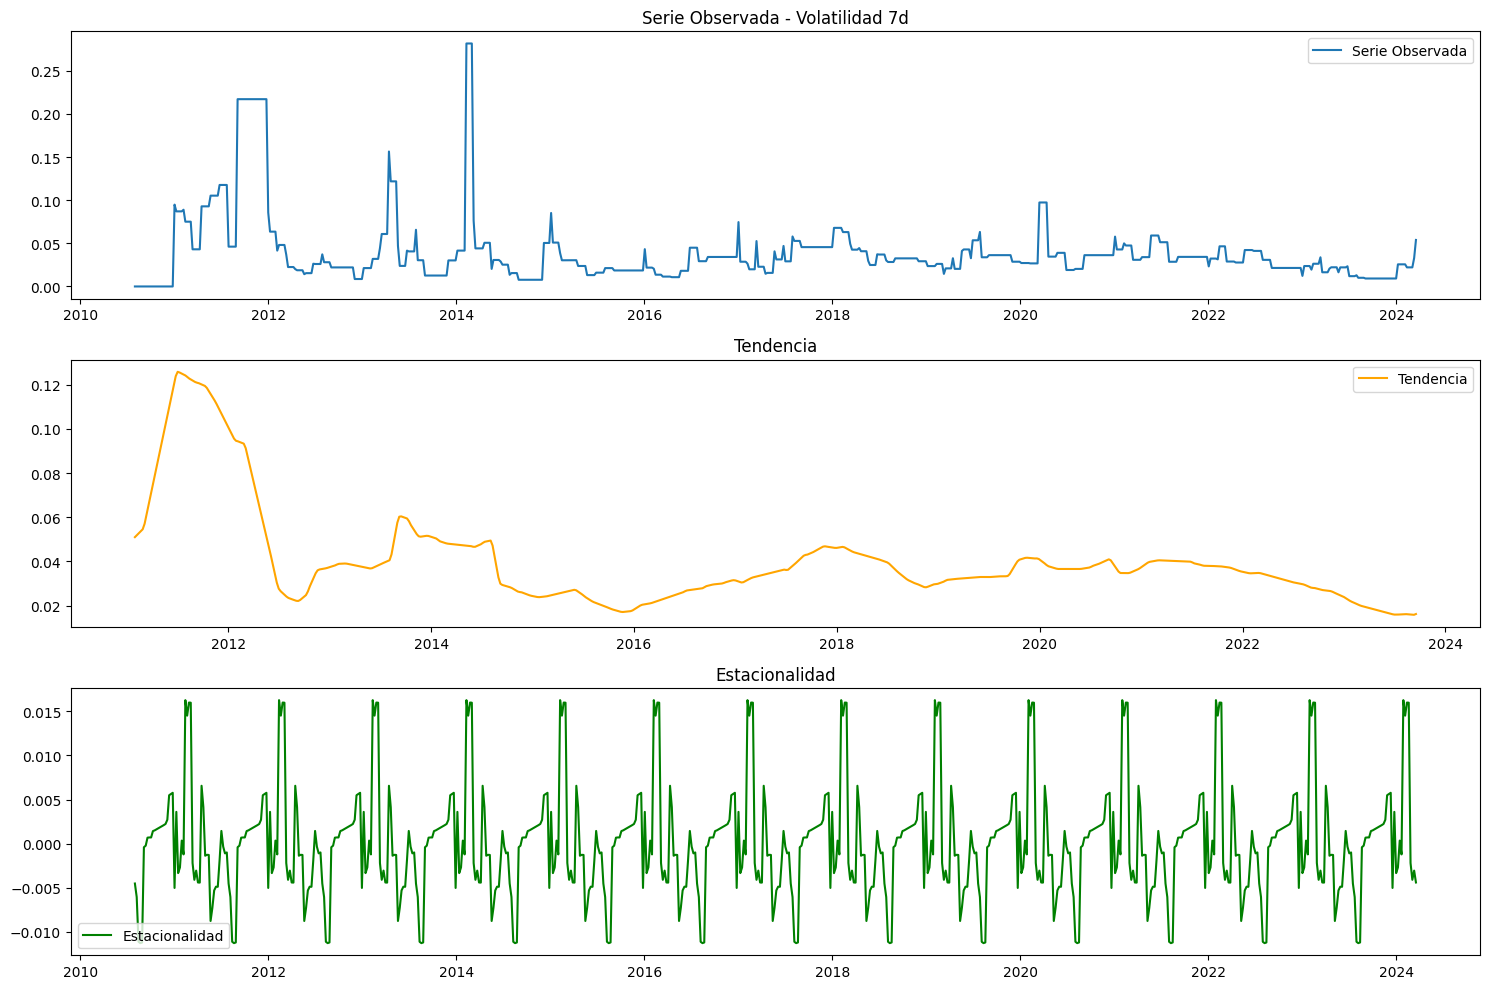

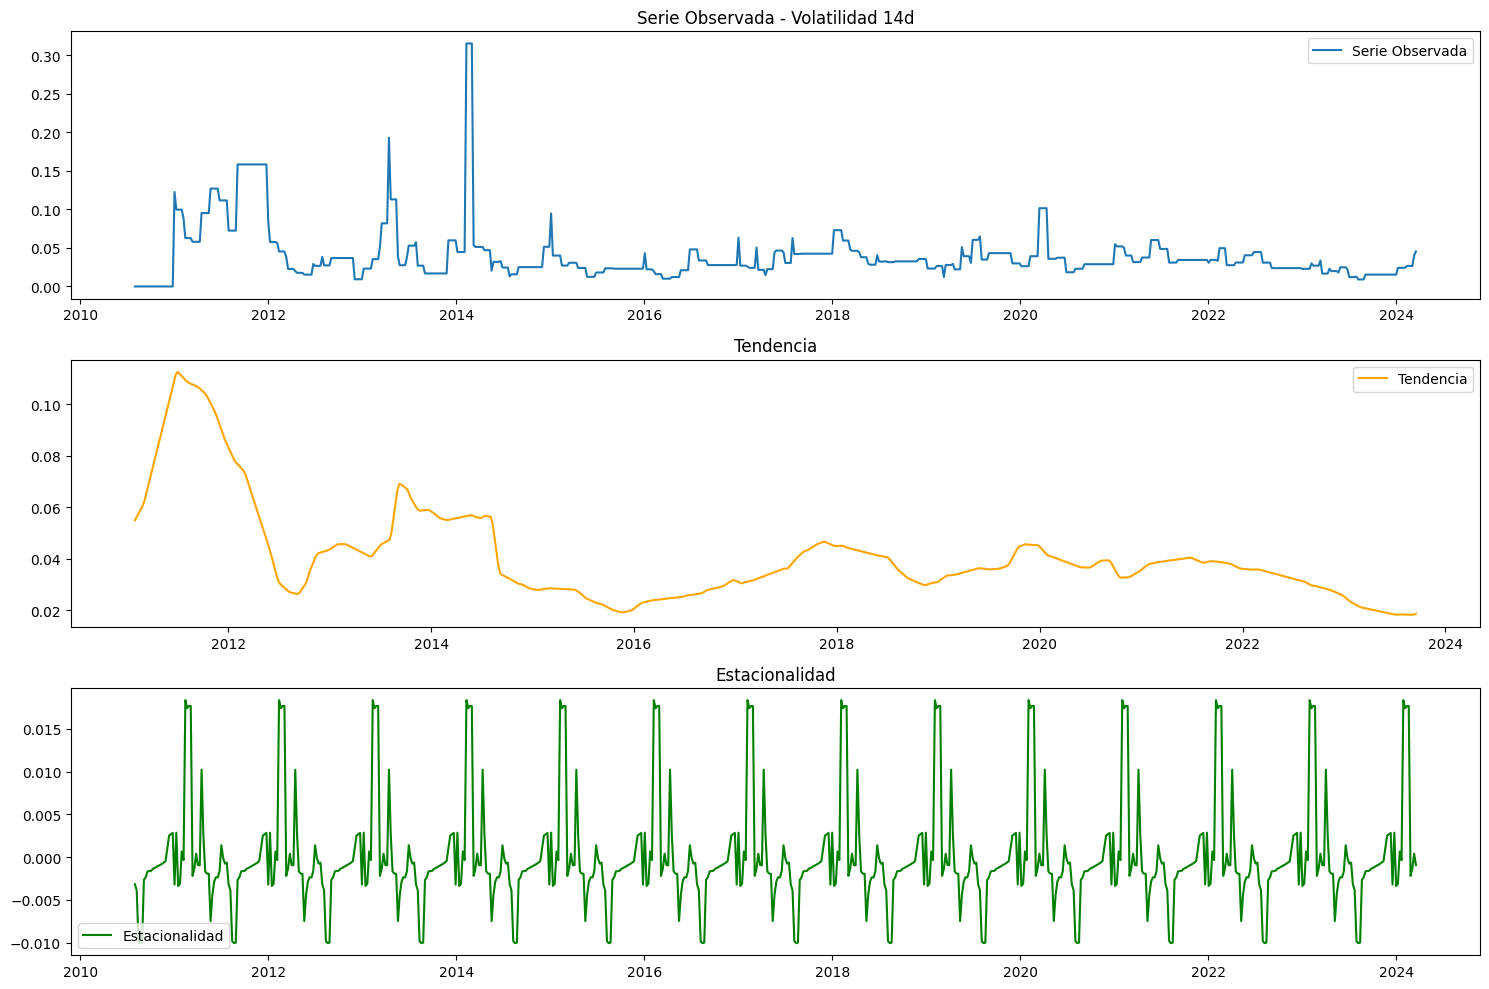

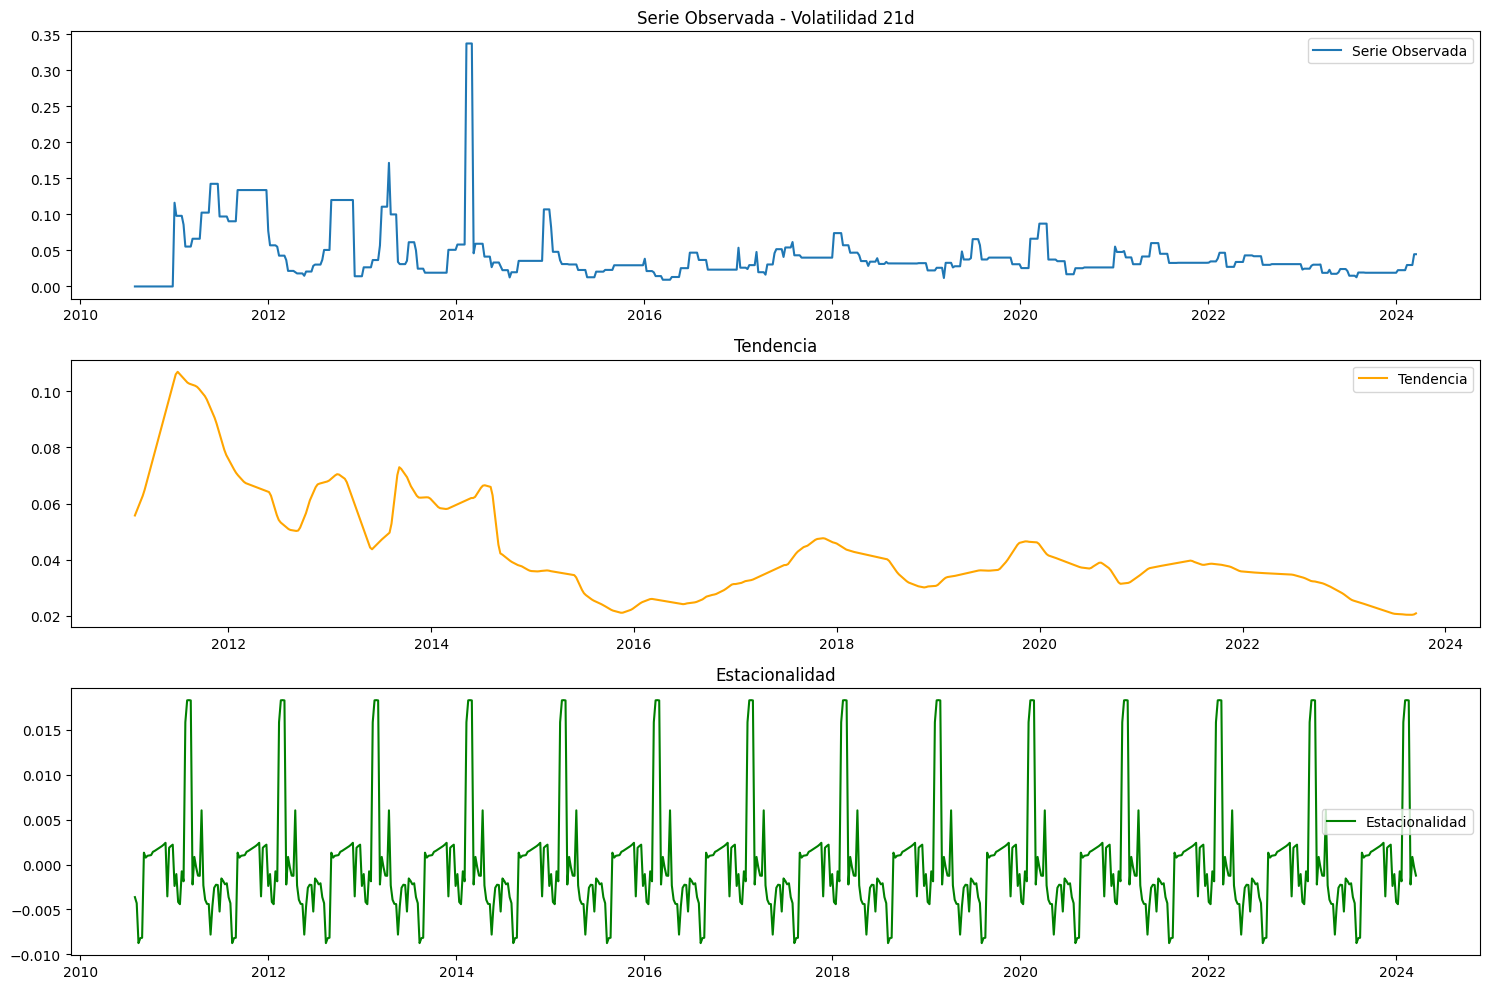

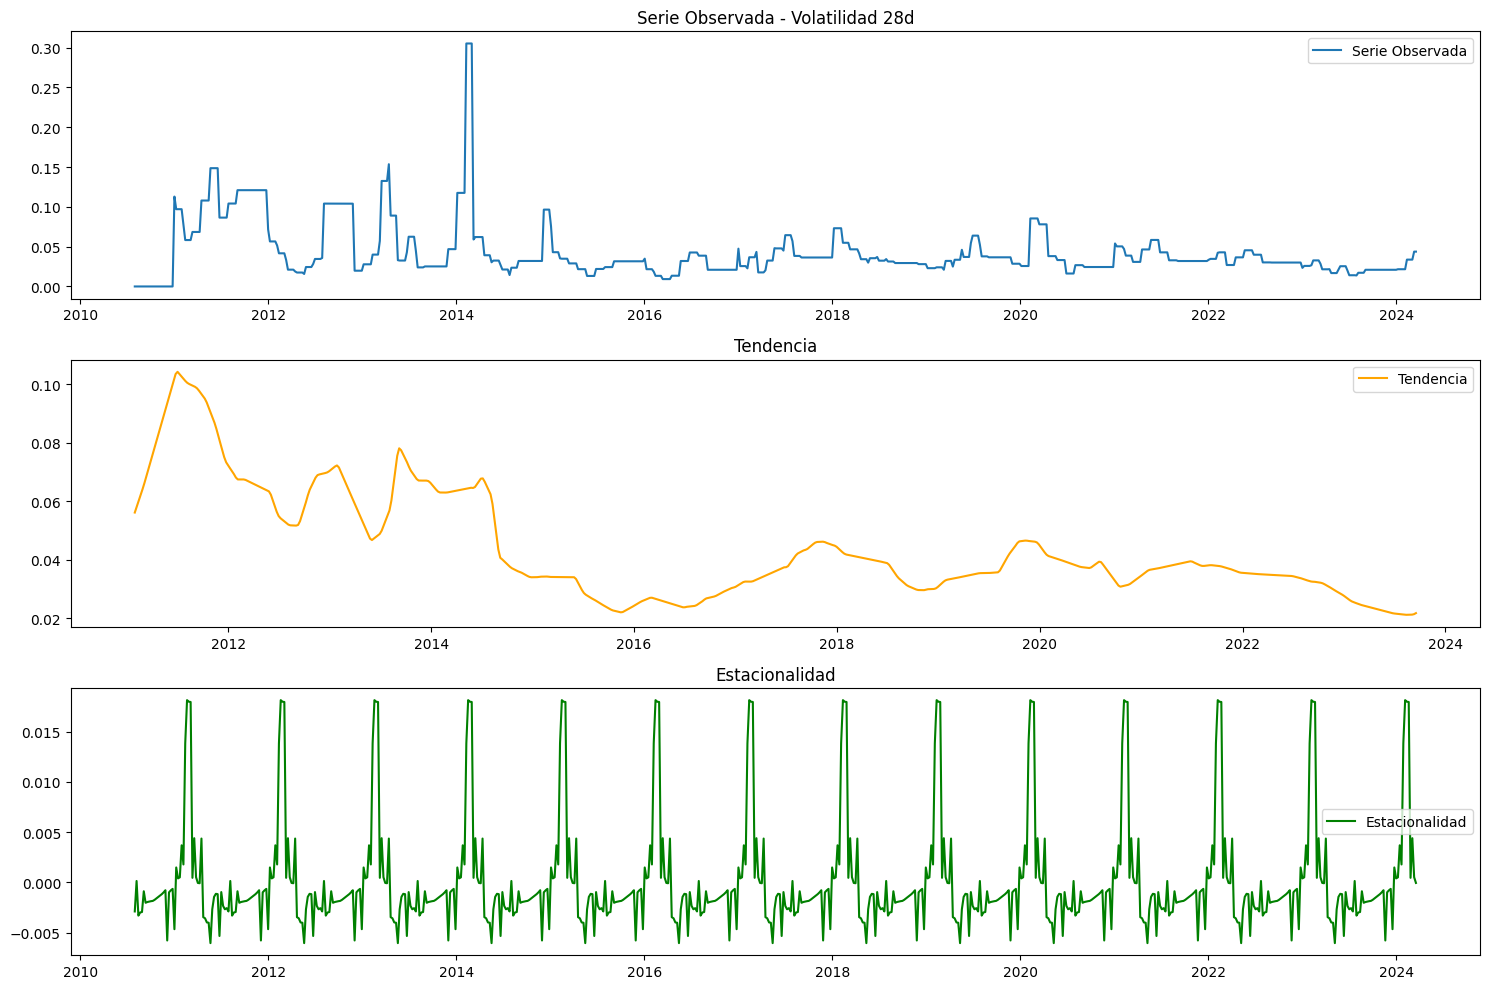

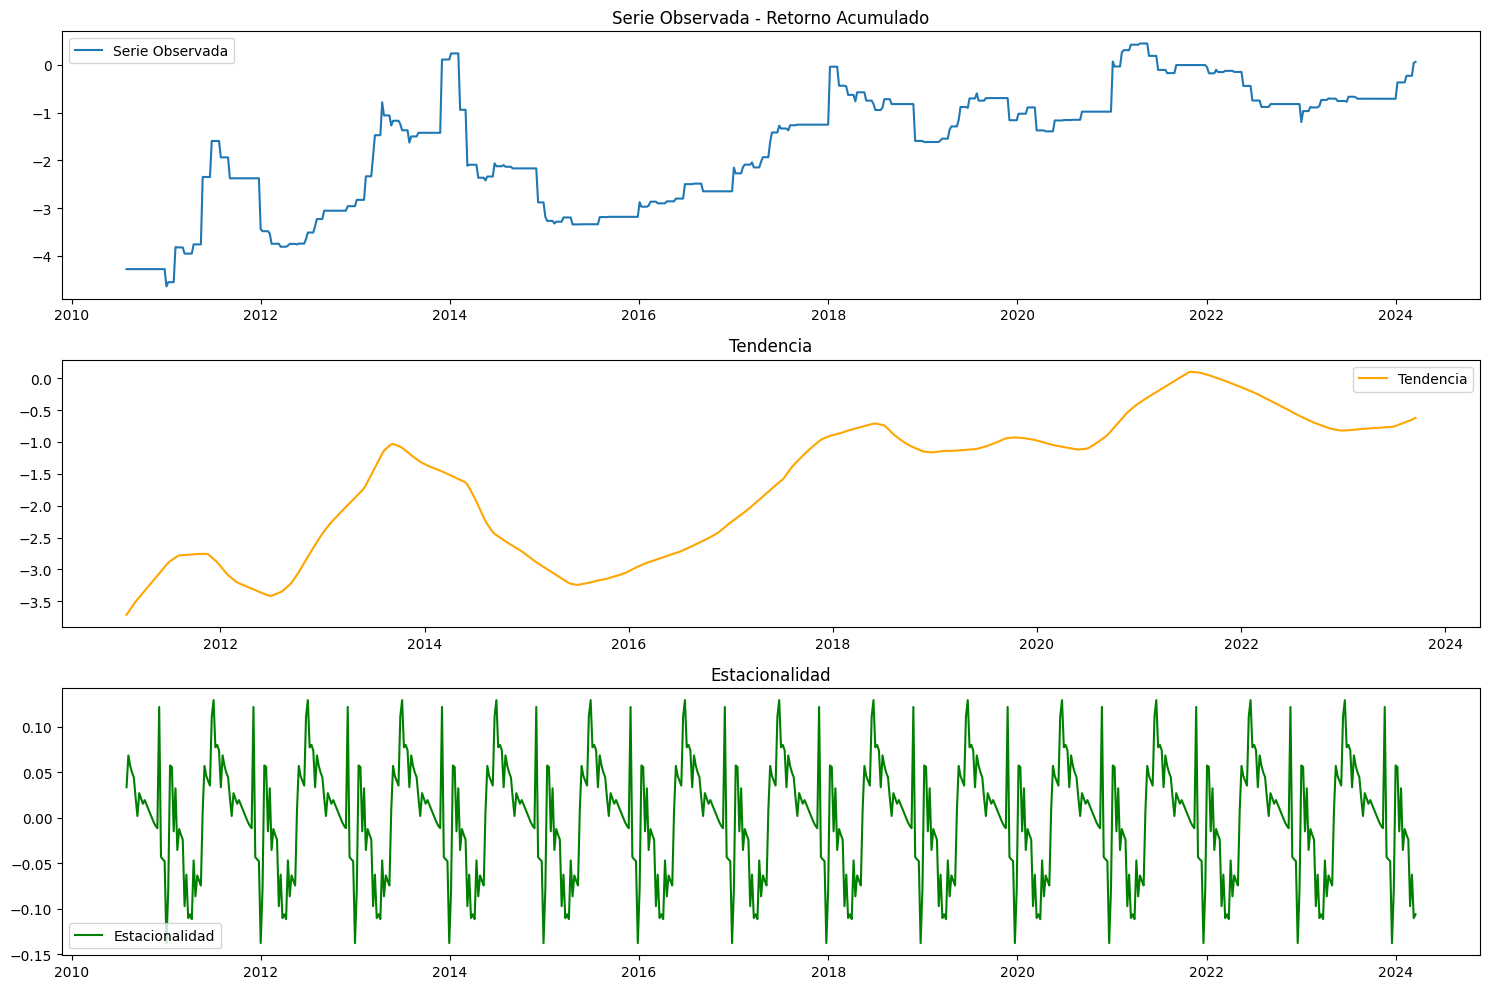

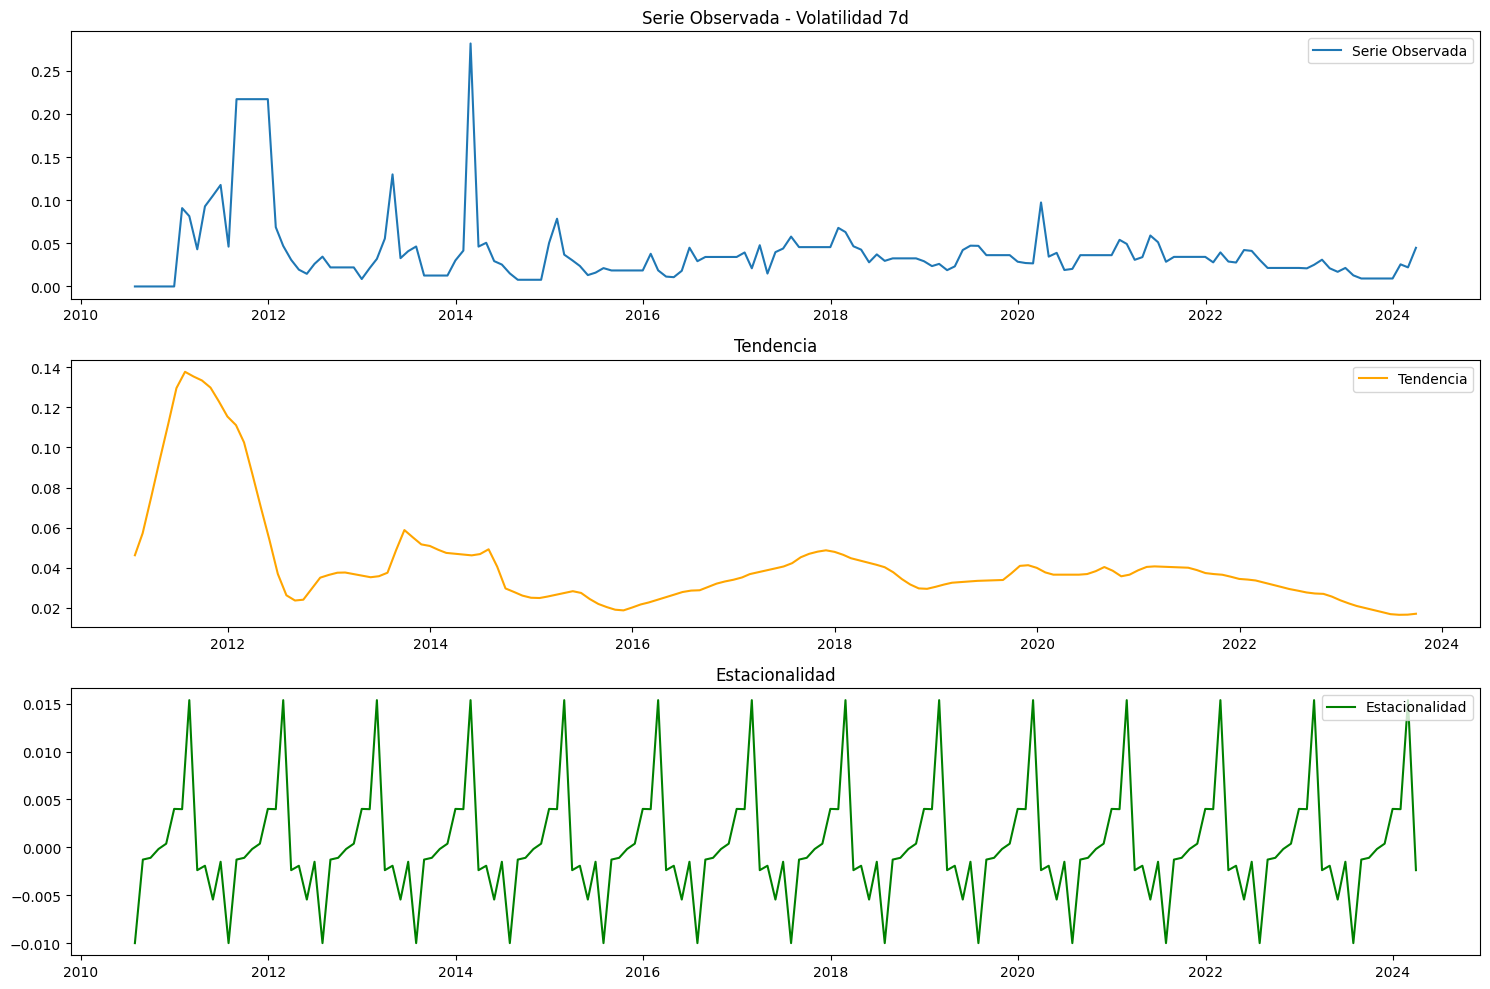

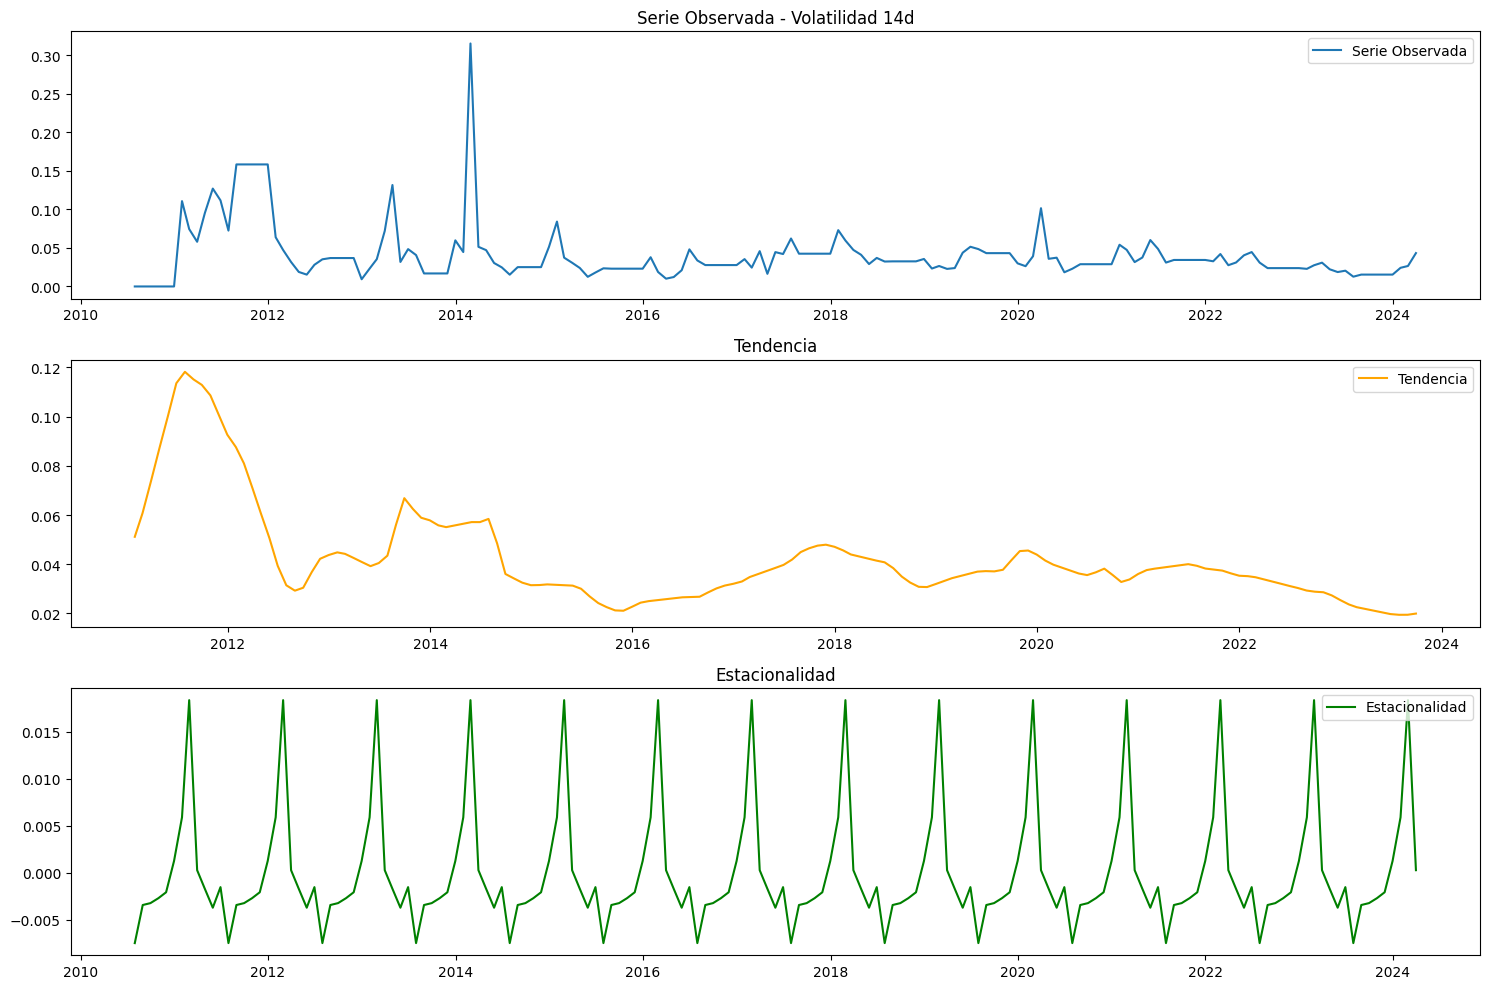

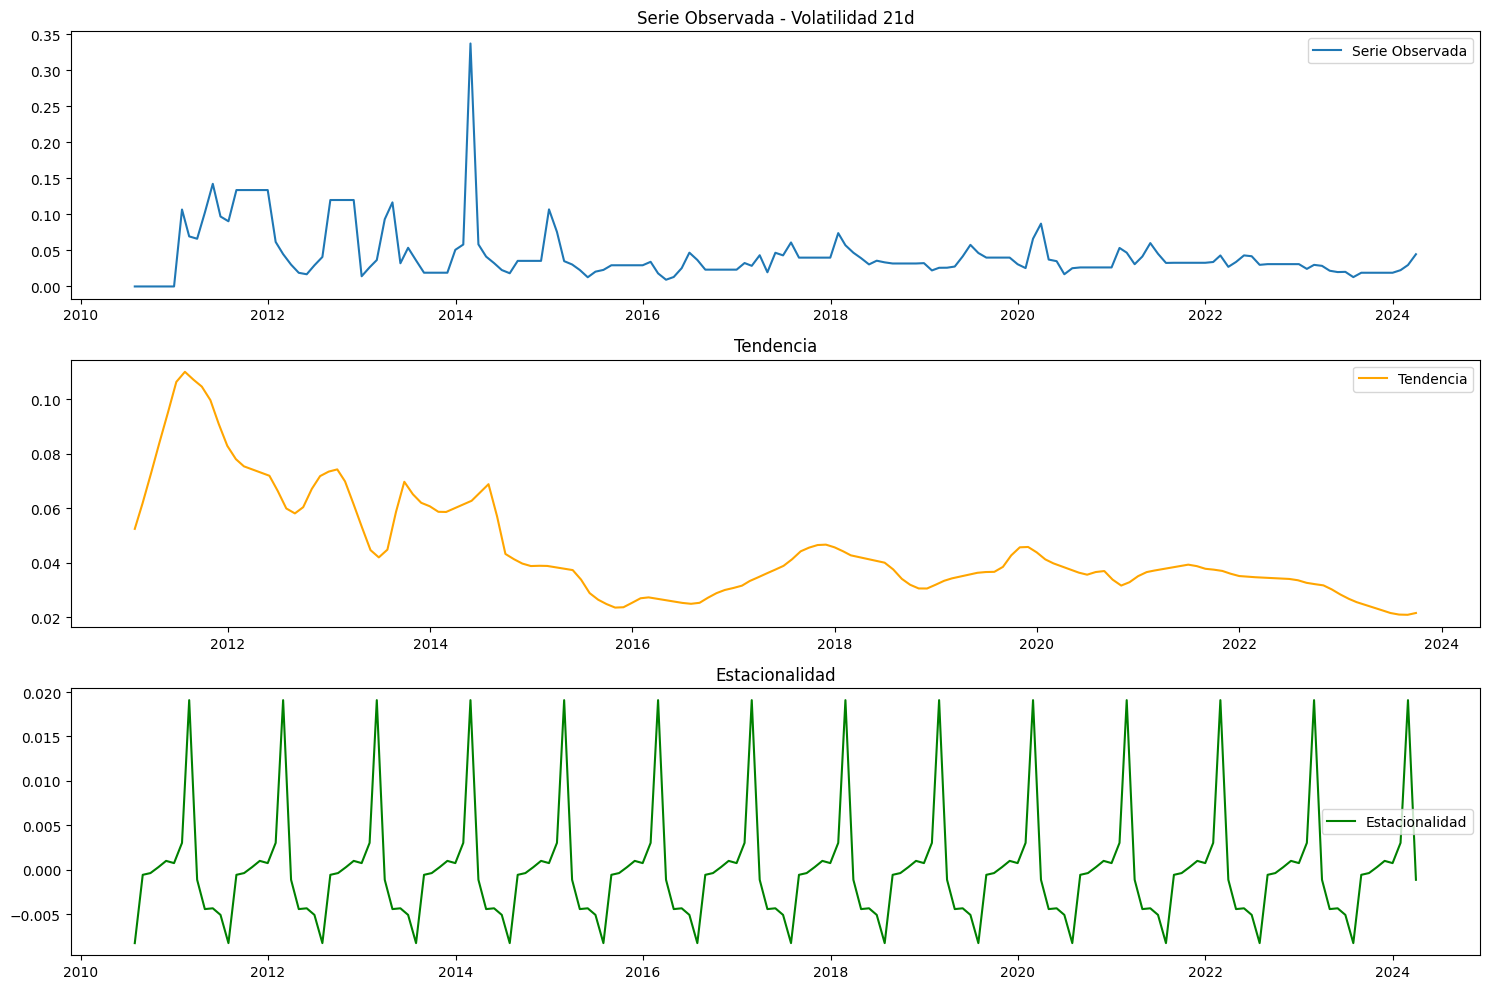

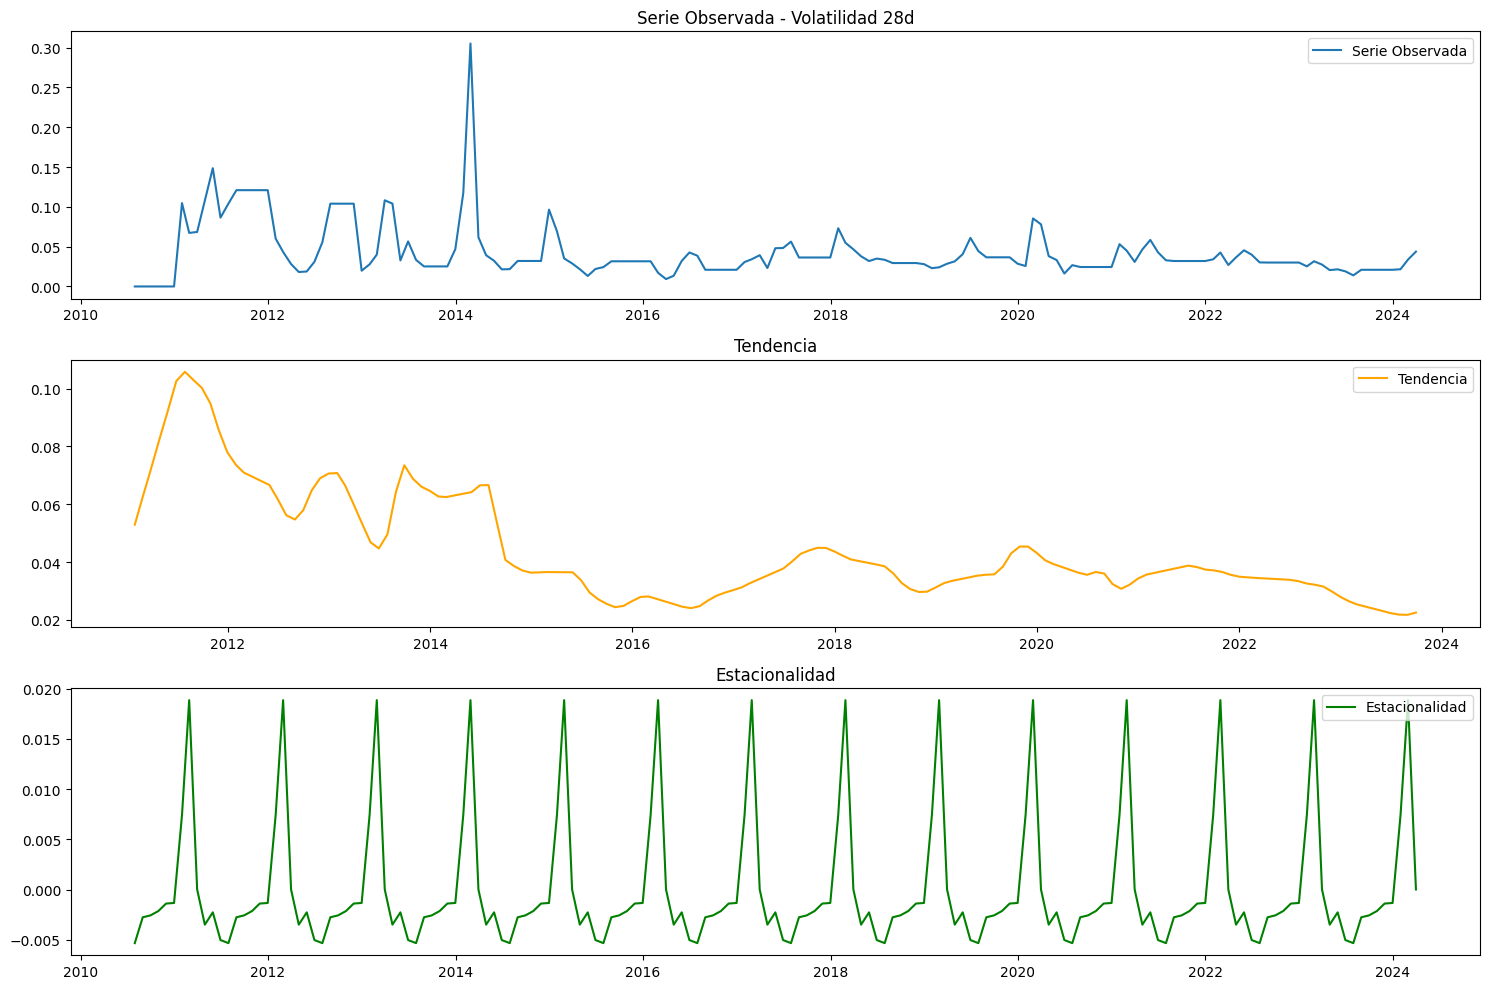

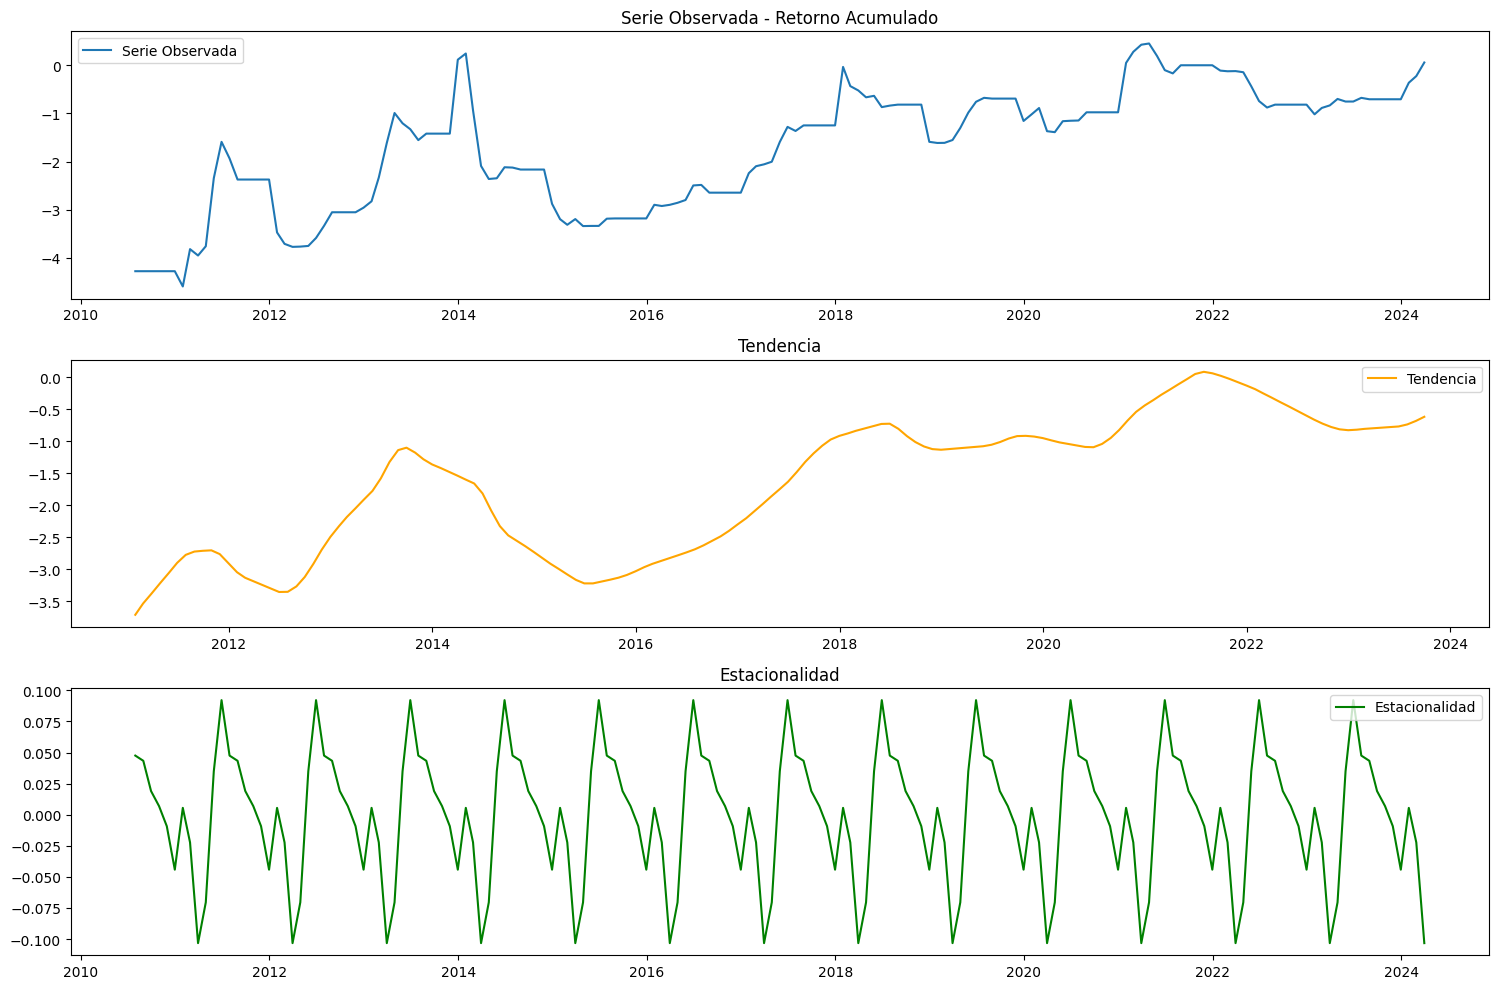

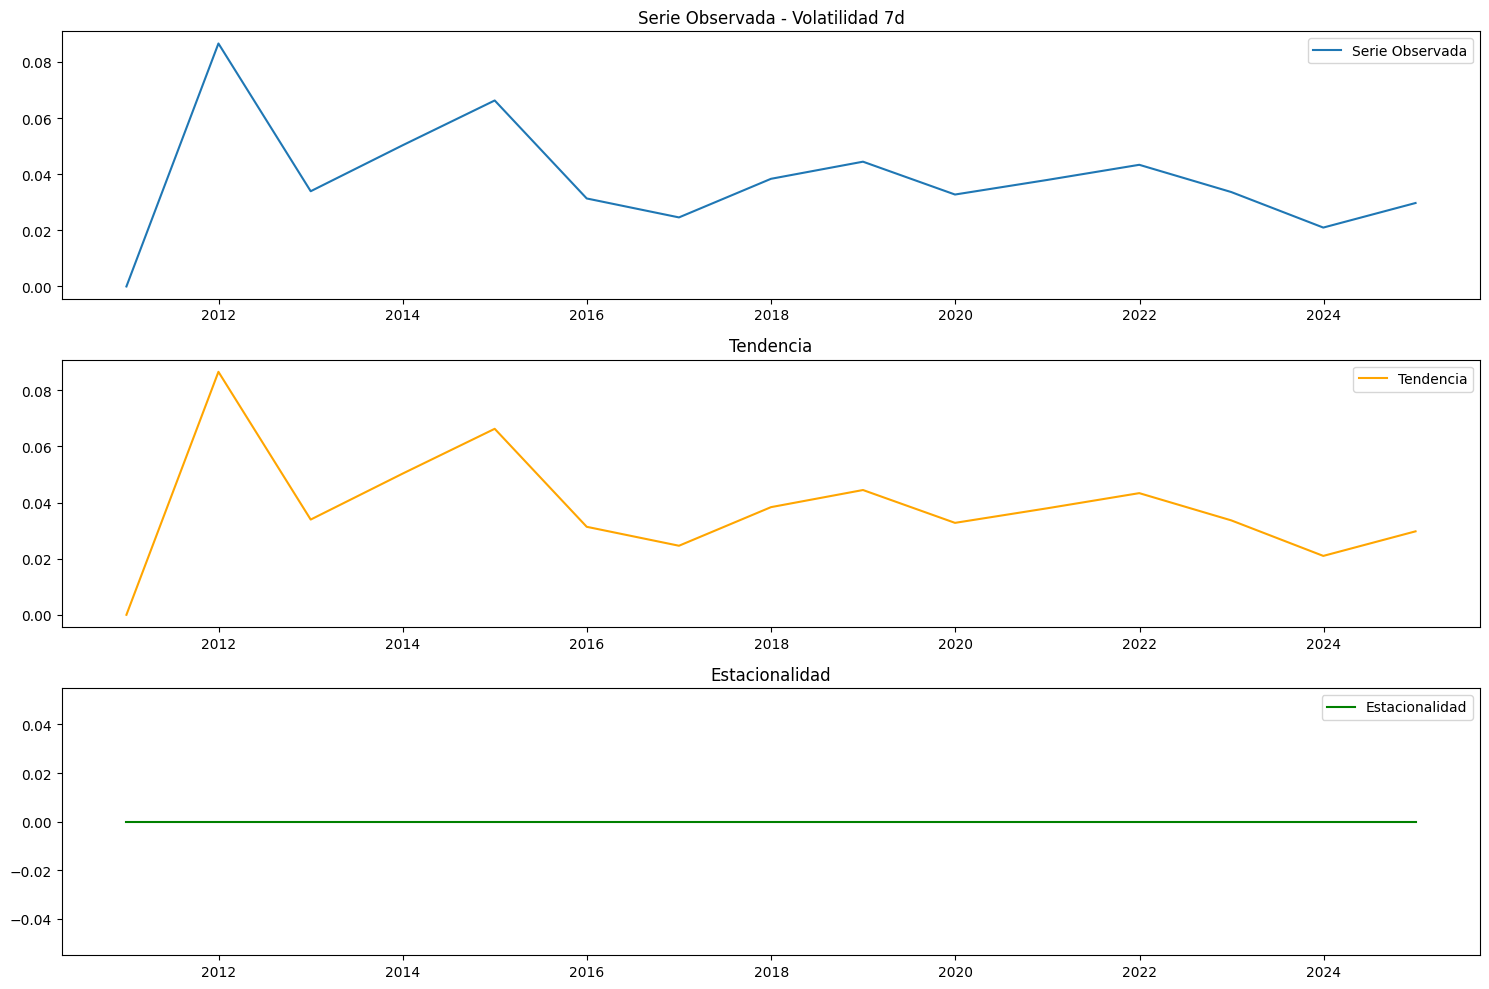

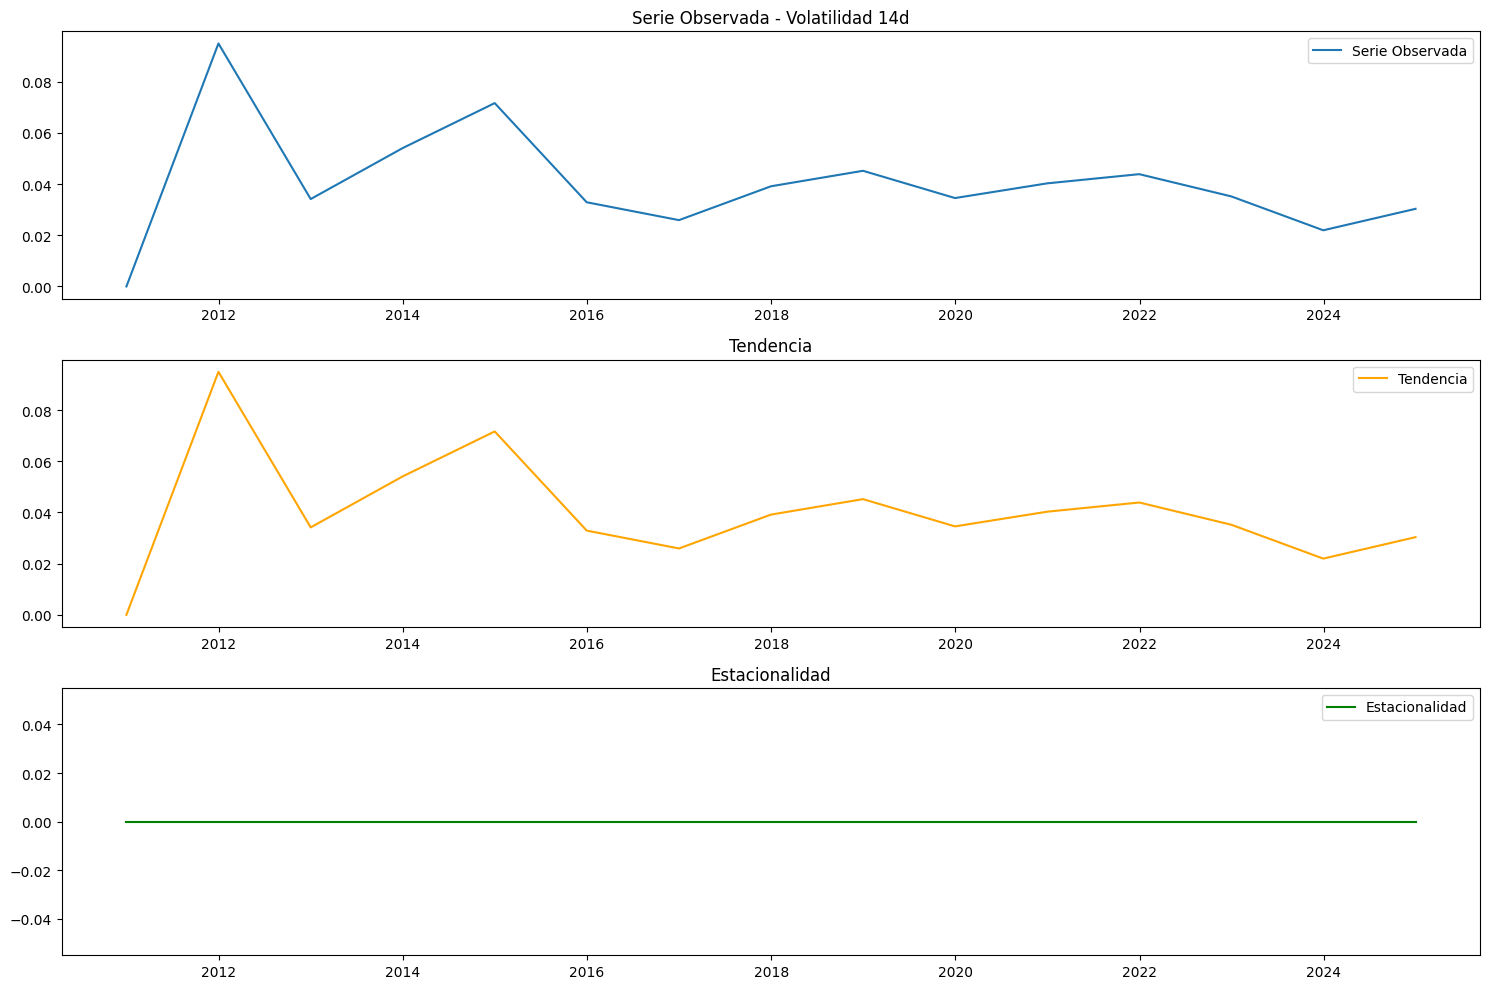

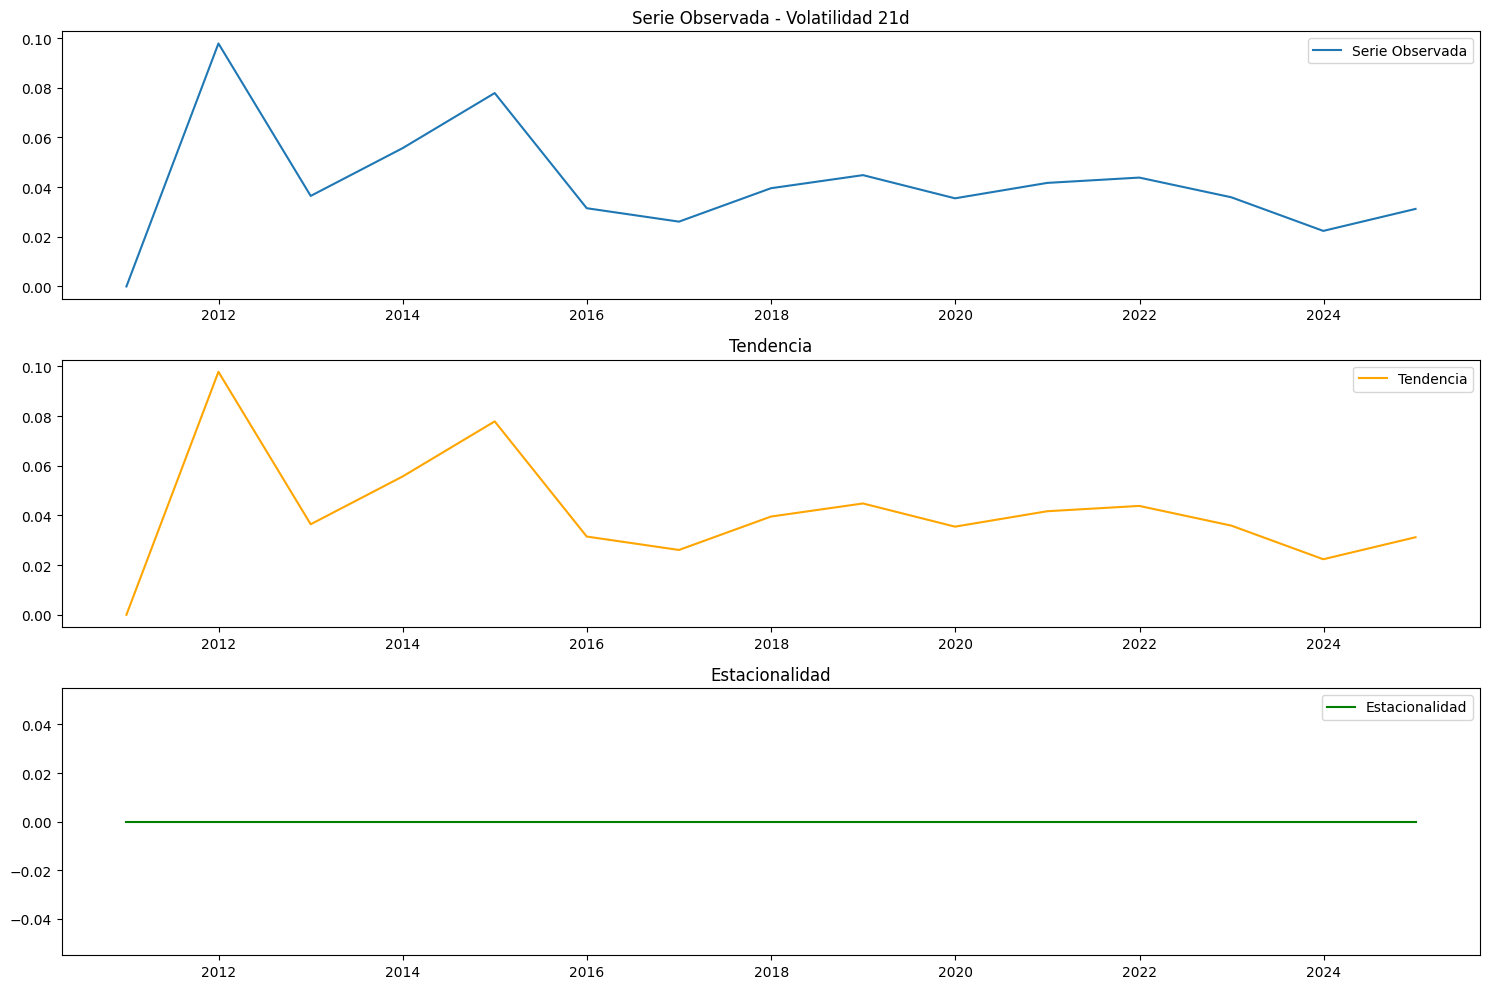

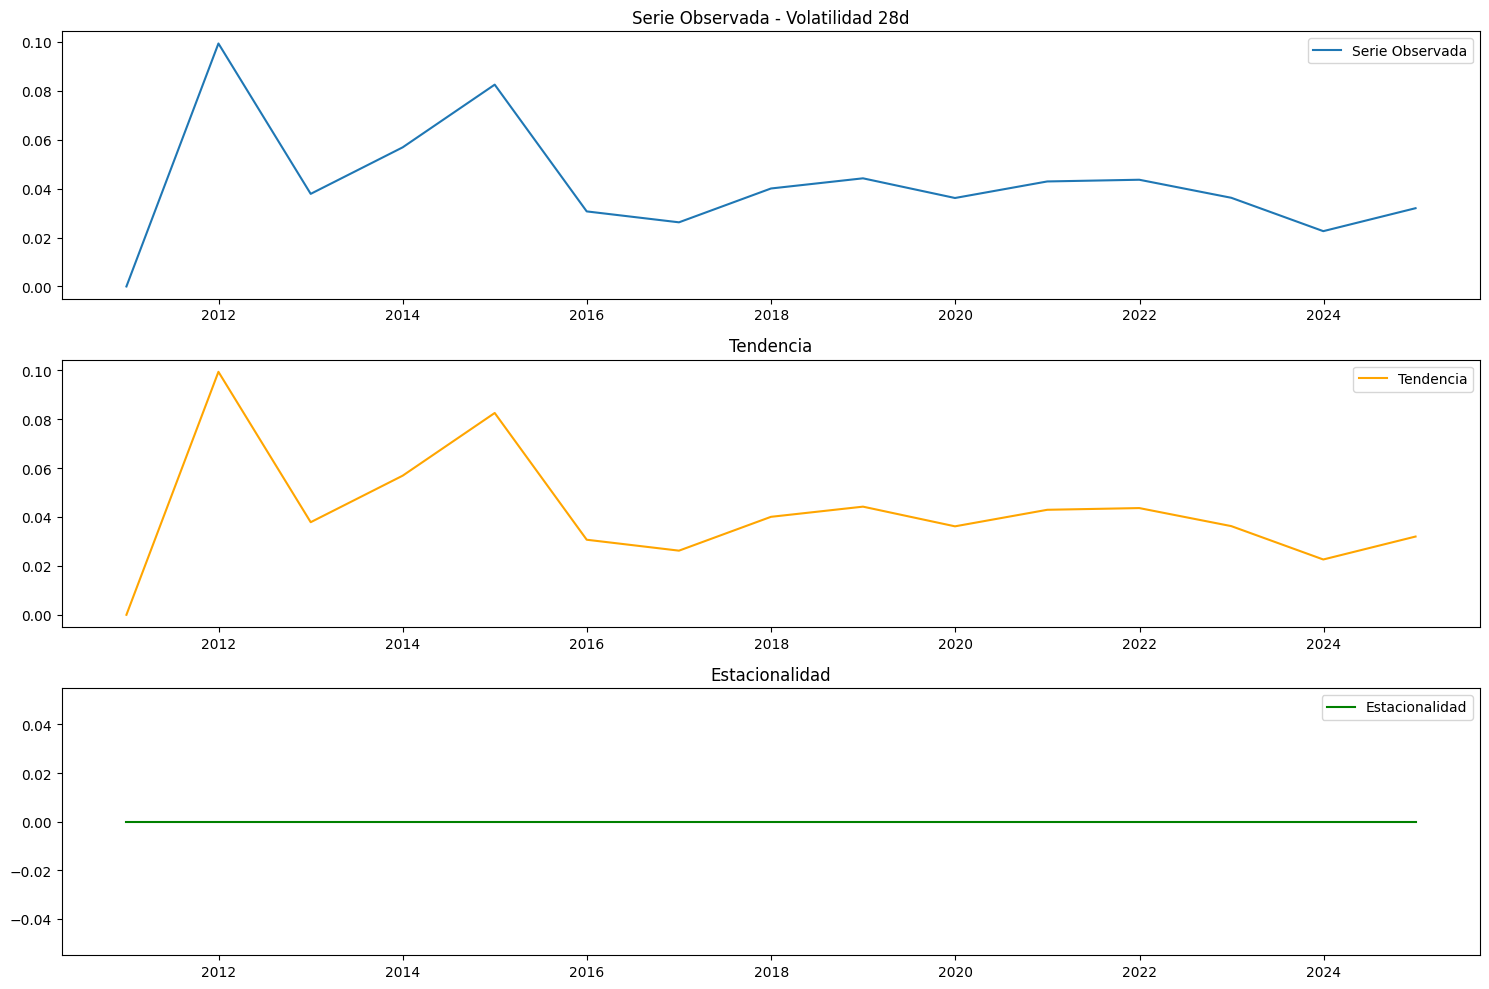

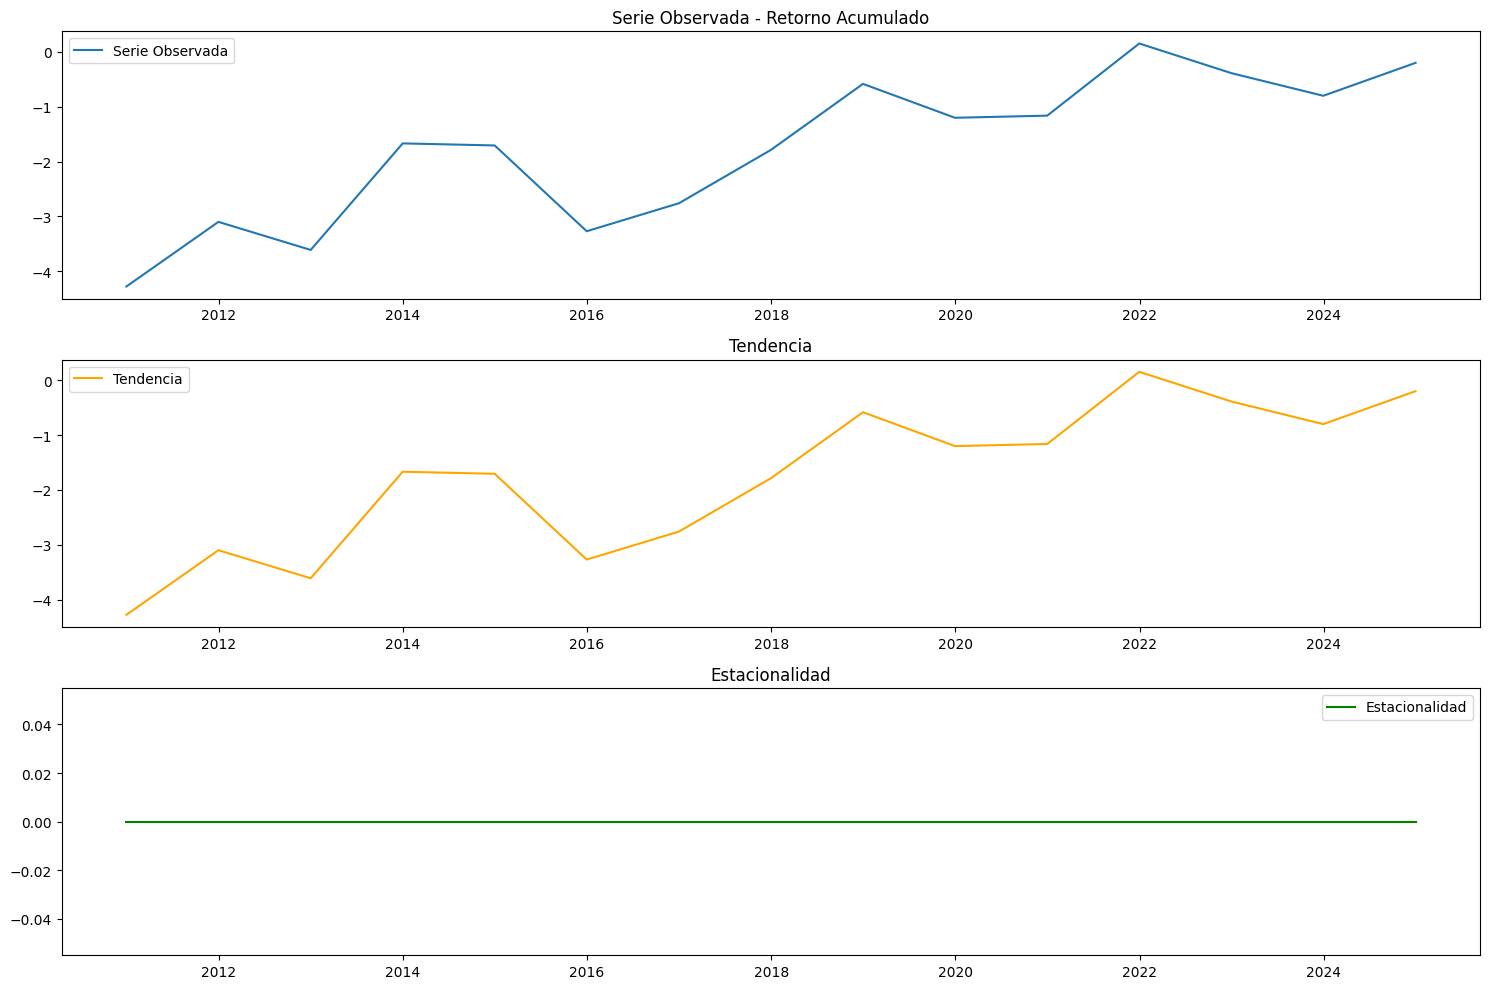

In [856]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt




def descomponer_y_graficar(serie, nombre):
    result = sm.tsa.seasonal_decompose(serie, model='additive')  # o 'multiplicative'
    plt.figure(figsize=(15, 10))

    plt.subplot(3, 1, 1)
    plt.plot(result.observed, label='Serie Observada')
    plt.title(f'Serie Observada - {nombre}')
    plt.legend()

    plt.subplot(3, 1, 2)
    plt.plot(result.trend, label='Tendencia', color='orange')
    plt.title('Tendencia')
    plt.legend()

    plt.subplot(3, 1, 3)
    plt.plot(result.seasonal, label='Estacionalidad', color='green')
    plt.title('Estacionalidad')
    plt.legend()

    plt.tight_layout()
    plt.show()
    
    return result

resultados_semanales = {
    'Volatilidad 7d': descomponer_y_graficar(volatilidad_7_semanal, 'Volatilidad 7d'),
    'Volatilidad 14d': descomponer_y_graficar(volatilidad_14_semanal, 'Volatilidad 14d'),
    'Volatilidad 21d': descomponer_y_graficar(volatilidad_21_semanal, 'Volatilidad 21d'),
    'Volatilidad 28d': descomponer_y_graficar(volatilidad_28_semanal, 'Volatilidad 28d'),
    'Retorno Acumulado': descomponer_y_graficar(retorno_acumulado_semanal, 'Retorno Acumulado')
}

resultados_mensuales = {
    'Volatilidad 7d': descomponer_y_graficar(volatilidad_7_mensual, 'Volatilidad 7d'),
    'Volatilidad 14d': descomponer_y_graficar(volatilidad_14_mensual, 'Volatilidad 14d'),
    'Volatilidad 21d': descomponer_y_graficar(volatilidad_21_mensual, 'Volatilidad 21d'),
    'Volatilidad 28d': descomponer_y_graficar(volatilidad_28_mensual, 'Volatilidad 28d'),
    'Retorno Acumulado': descomponer_y_graficar(retorno_acumulado_mensual, 'Retorno Acumulado')
}


resultados_anuales = {
    'Volatilidad 7d': descomponer_y_graficar(volatilidad_7_anual, 'Volatilidad 7d'),
    'Volatilidad 14d': descomponer_y_graficar(volatilidad_14_anual, 'Volatilidad 14d'),
    'Volatilidad 21d': descomponer_y_graficar(volatilidad_21_anual, 'Volatilidad 21d'),
    'Volatilidad 28d': descomponer_y_graficar(volatilidad_28_anual, 'Volatilidad 28d'),
    'Retorno Acumulado': descomponer_y_graficar(retorno_acumulado_anual, 'Retorno Acumulado')
}


### Item 5.
Estudie estacionariedad de la serie de tiempo usando la ACF estudiada durante el curso, así
 como también los respectivos test estadísticos tales como Ljung-Box y Dickey Fuller. Aplique
 además las transformaciones necesarias para convertir la serie de tiempo en estacionaria.

In [857]:
from statsmodels.tsa.stattools import adfuller

def prueba_dickey_fuller(serie, nombre):
    resultado = adfuller(serie.dropna())  
    print(f'Prueba de Dickey-Fuller para {nombre}:')
    print(f'Estadístico: {resultado[0]}')
    print(f'Valor p: {resultado[1]}')
    print(f'Número de retardos utilizados: {resultado[2]}')
    print(f'Número de observaciones utilizadas: {resultado[3]}')
    print('Valores críticos:')
    for key, value in resultado[4].items():
        print(f'   {key}: {value}')
    print('\n')


# Asegúrate de tener tus datos en un DataFrame llamado `df`
prueba_dickey_fuller(bitcoin_data['Volatilidad_7d'], 'Volatilidad 7')
prueba_dickey_fuller(bitcoin_data['Volatilidad_14d'], 'Volatilidad 14')
prueba_dickey_fuller(bitcoin_data['Volatilidad_21d'], 'Volatilidad 21')
prueba_dickey_fuller(bitcoin_data['Volatilidad_28d'], 'Volatilidad 28')
prueba_dickey_fuller(bitcoin_data['Retorno_Acumulado'], 'Retorno_Acumulado')



Prueba de Dickey-Fuller para Volatilidad 7:
Estadístico: -7.470877323489327
Valor p: 5.058843771700714e-11
Número de retardos utilizados: 32
Número de observaciones utilizadas: 4964
Valores críticos:
   1%: -3.4316680267467183
   5%: -2.862122424368673
   10%: -2.5670800253574324


Prueba de Dickey-Fuller para Volatilidad 14:
Estadístico: -6.803042873467541
Valor p: 2.212037885322242e-09
Número de retardos utilizados: 28
Número de observaciones utilizadas: 4968
Valores críticos:
   1%: -3.4316669649844727
   5%: -2.8621219552891963
   10%: -2.5670797756478825


Prueba de Dickey-Fuller para Volatilidad 21:
Estadístico: -6.749076106589255
Valor p: 2.9828849576575963e-09
Número de retardos utilizados: 31
Número de observaciones utilizadas: 4965
Valores críticos:
   1%: -3.431667761145687
   5%: -2.8621223070279247
   10%: -2.5670799628923104


Prueba de Dickey-Fuller para Volatilidad 28:
Estadístico: -5.344657815908784
Valor p: 4.422214391059568e-06
Número de retardos utilizados: 30
Númer

Las pruebas de dickey fuller aplicadas para la volatilidad indican que  son estacionarias , es decir que las series no presentan una tendencia signifiactiva y el retorno acumulado no es estacionario, por lo tanto puede tener una tendencia que afecte el comportaminto

In [858]:
from statsmodels.stats.diagnostic import acorr_ljungbox
def prueba_ljung_box(serie, nombre, lags=10):
    lb_test = acorr_ljungbox(serie.dropna(), lags=[lags], return_df=True)
    print(f'Prueba de Ljung-Box para {nombre}:')
    print(lb_test)
    print('-' * 50)
prueba_ljung_box(bitcoin_data['Volatilidad_7d'], 'Volatilidad 7d Semanal', lags=6)
prueba_ljung_box(bitcoin_data['Volatilidad_14d'], 'Volatilidad 14d Semanal', lags=6)
prueba_ljung_box(bitcoin_data['Volatilidad_21d'], 'Volatilidad 21d Semanal', lags=6)
prueba_ljung_box(bitcoin_data['Volatilidad_28d'], 'Volatilidad 28d Semanal', lags=6)
prueba_ljung_box(bitcoin_data['Retorno_Acumulado'], 'Retorno acumulado', lags=6)


Prueba de Ljung-Box para Volatilidad 7d Semanal:
        lb_stat  lb_pvalue
6  17405.218794        0.0
--------------------------------------------------
Prueba de Ljung-Box para Volatilidad 14d Semanal:
        lb_stat  lb_pvalue
6  24268.643611        0.0
--------------------------------------------------
Prueba de Ljung-Box para Volatilidad 21d Semanal:
        lb_stat  lb_pvalue
6  26526.369484        0.0
--------------------------------------------------
Prueba de Ljung-Box para Volatilidad 28d Semanal:
        lb_stat  lb_pvalue
6  27507.436177        0.0
--------------------------------------------------
Prueba de Ljung-Box para Retorno acumulado:
        lb_stat  lb_pvalue
6  29701.921964        0.0
--------------------------------------------------


Los resultado arrojados por la prueba de Ljung box, no dicen que hay autocorrelación en las series, por lo tanto los errores de predicción no son independientes


<Figure size 1000x600 with 0 Axes>

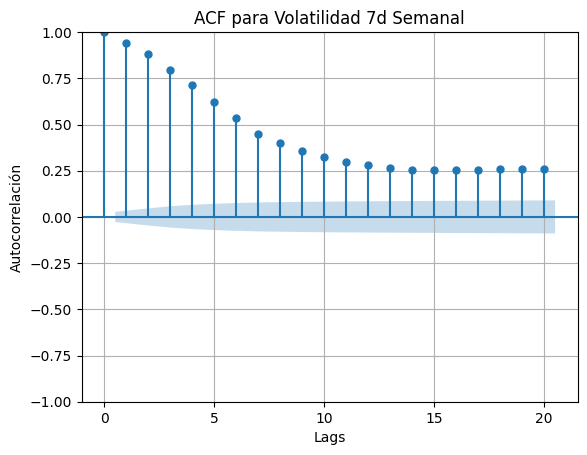

<Figure size 1000x600 with 0 Axes>

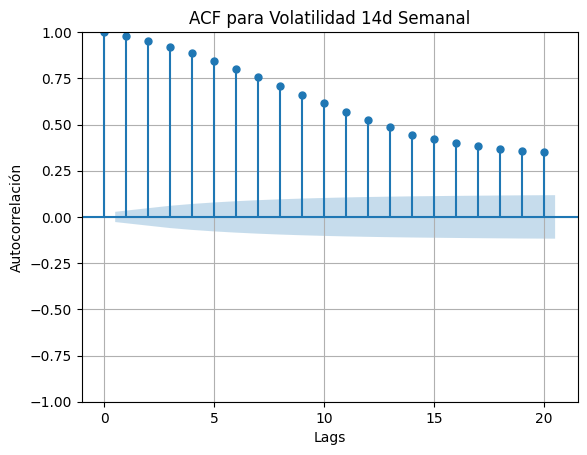

<Figure size 1000x600 with 0 Axes>

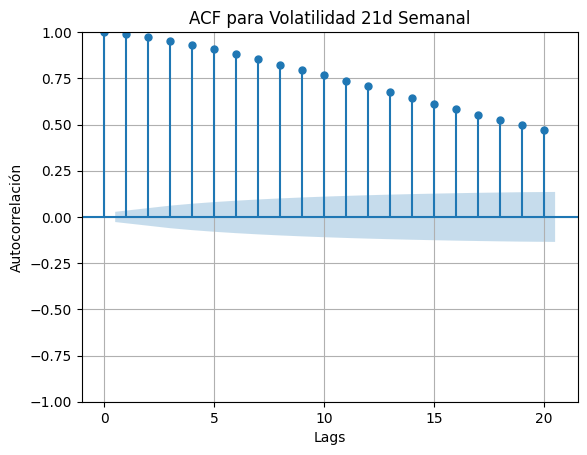

<Figure size 1000x600 with 0 Axes>

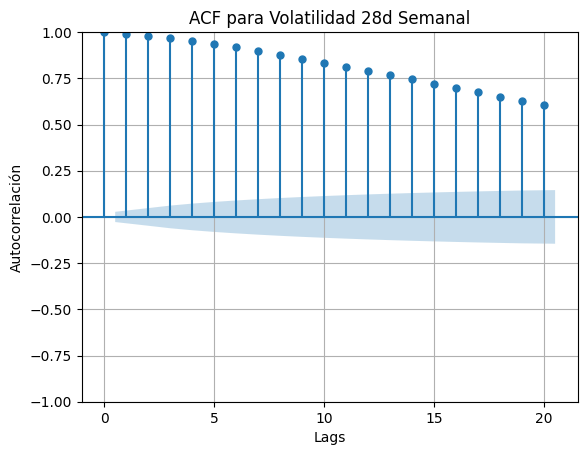

<Figure size 1000x600 with 0 Axes>

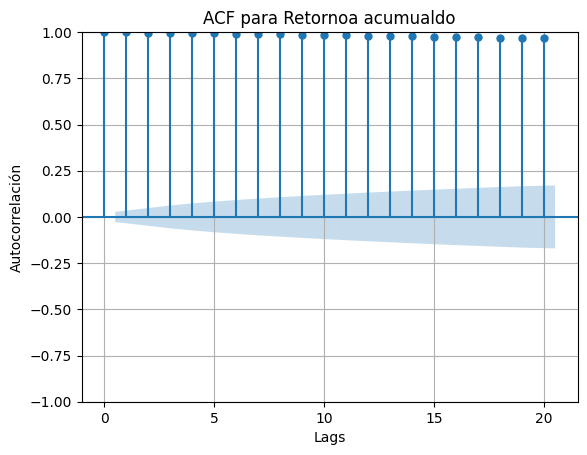

In [874]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
def graficar_acf(serie, nombre, lags=40):
    plt.figure(figsize=(10, 6))
    plot_acf(serie.dropna(), lags=lags)
    plt.title(f'ACF para {nombre}')
    plt.xlabel('Lags')
    plt.ylabel('Autocorrelación')
    plt.grid(True)
    plt.show()
graficar_acf(bitcoin_data['Volatilidad_7d'], 'Volatilidad 7d Semanal', lags=20)
graficar_acf(bitcoin_data['Volatilidad_14d'], 'Volatilidad 14d Semanal', lags=20)
graficar_acf(bitcoin_data['Volatilidad_21d'], 'Volatilidad 21d Semanal', lags=20)
graficar_acf(bitcoin_data['Volatilidad_28d'], 'Volatilidad 28d Semanal', lags=20)
graficar_acf(bitcoin_data['Retorno_Acumulado'], 'Retornoa acumualdo', lags=20)

Las series de voaltilidad muestran una autocorrelación significativa en los primeros lags y el retorno acumulado tambien muestra autocorrelación pero esta menos pronunciada


### Item 6.
Mediante agregación por grupos analice el comportamiento de la media y desviación estándar,
 agrupando por semanas, días, meses. Además, para estas agrupaciones, calcule estadísticos
 móviles. Dibuje la distribución de frecuencias para diferentes lags como se realizó en las notas

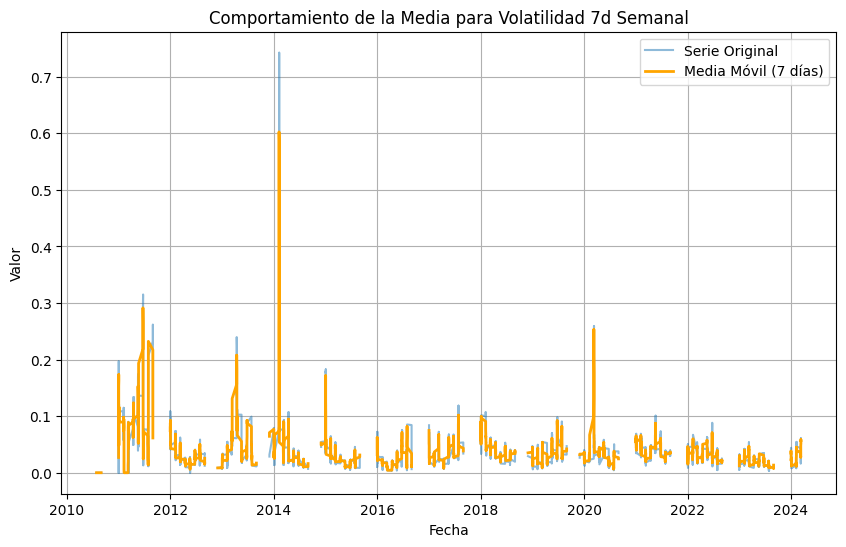

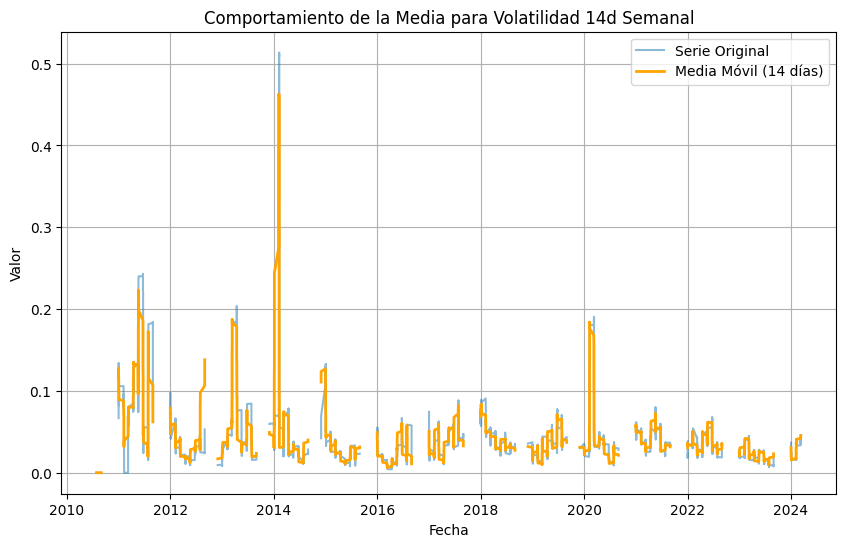

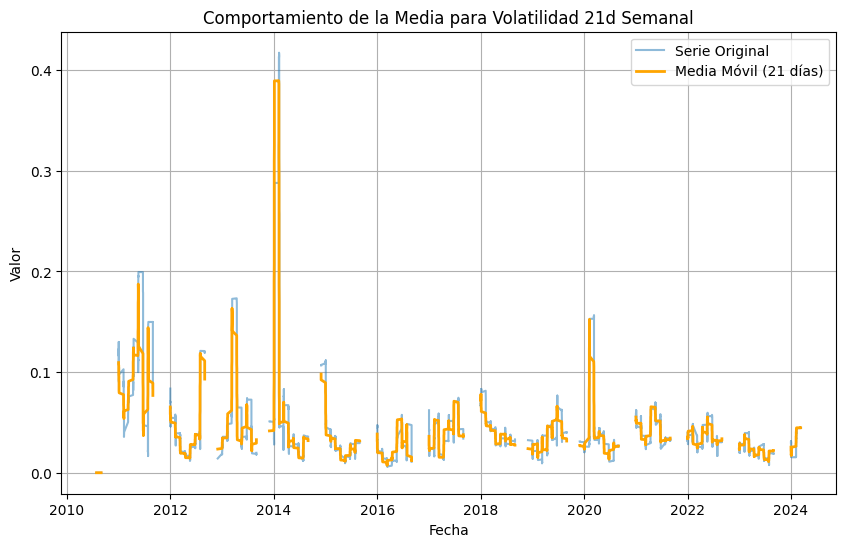

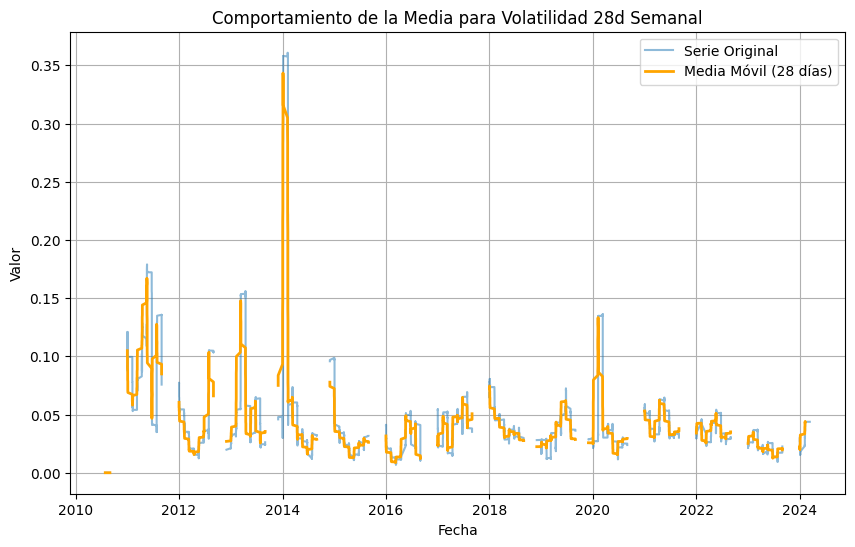

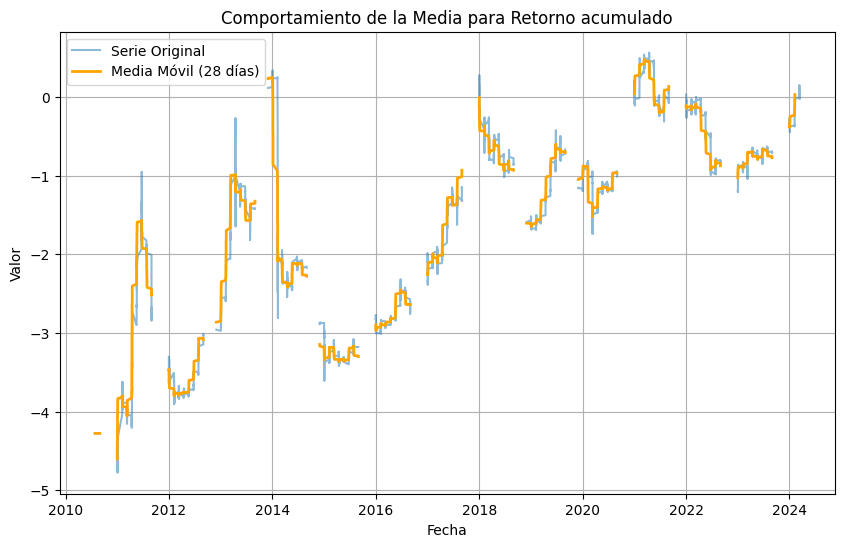

In [875]:
import matplotlib.pyplot as plt
import pandas as pd
def graficar_media_movil(serie, nombre, window=6):
    plt.figure(figsize=(10, 6))
    plt.plot(serie, label='Serie Original', alpha=0.5)
    media_movil = serie.rolling(window=window).mean()
    plt.plot(media_movil, label=f'Media Móvil ({window} días)', color='orange', linewidth=2)
    plt.title(f'Comportamiento de la Media para {nombre}')
    plt.xlabel('Fecha')
    plt.ylabel('Valor')
    plt.legend()
    plt.grid(True)
    plt.show()
graficar_media_movil(bitcoin_data['Volatilidad_7d'], 'Volatilidad 7d Semanal', window=7)
graficar_media_movil(bitcoin_data['Volatilidad_14d'], 'Volatilidad 14d Semanal', window=14)
graficar_media_movil(bitcoin_data['Volatilidad_21d'], 'Volatilidad 21d Semanal', window=21)
graficar_media_movil(bitcoin_data['Volatilidad_28d'], 'Volatilidad 28d Semanal', window=28)
graficar_media_movil(bitcoin_data['Retorno_Acumulado'], 'Retorno acumulado', window=28)


En comparación con la serie original, la media movil, con la window=6, tiene un coportamiento muy similar con la serie original

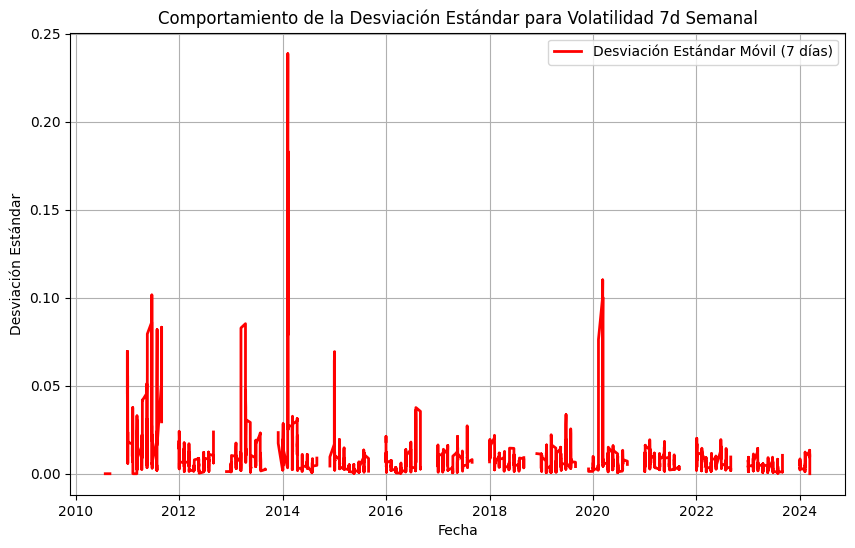

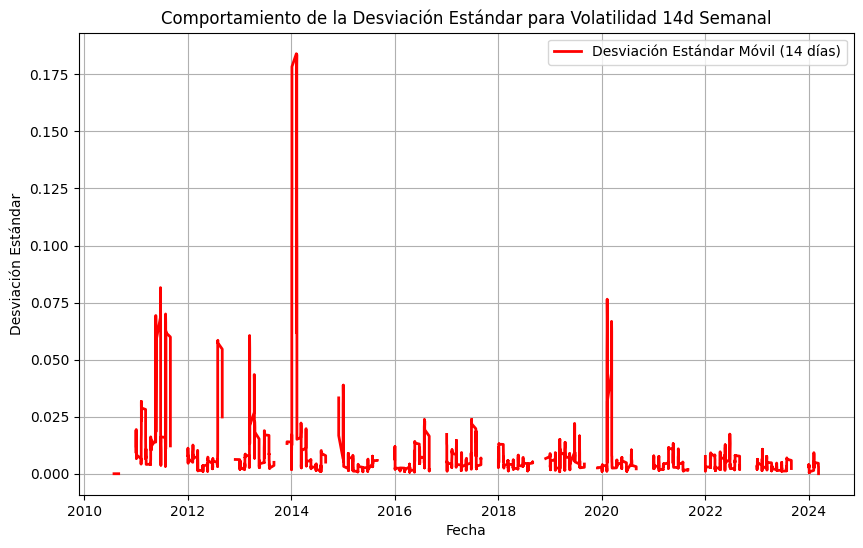

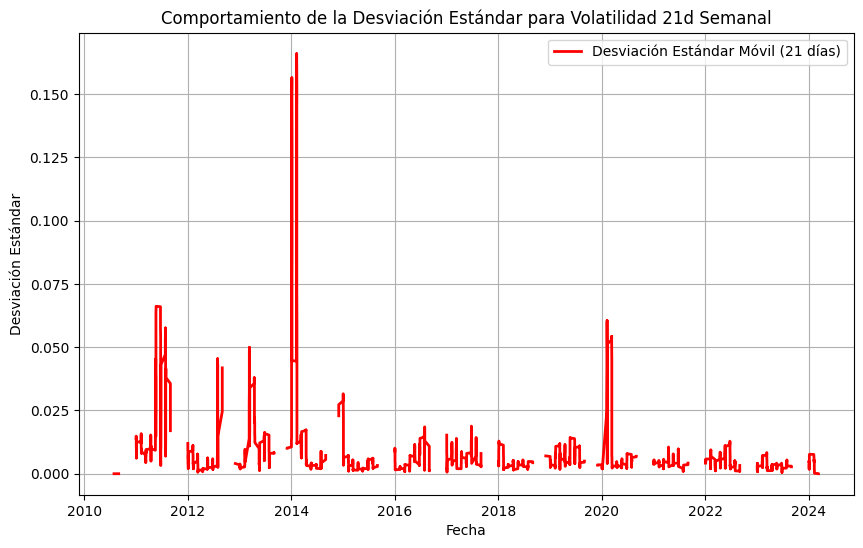

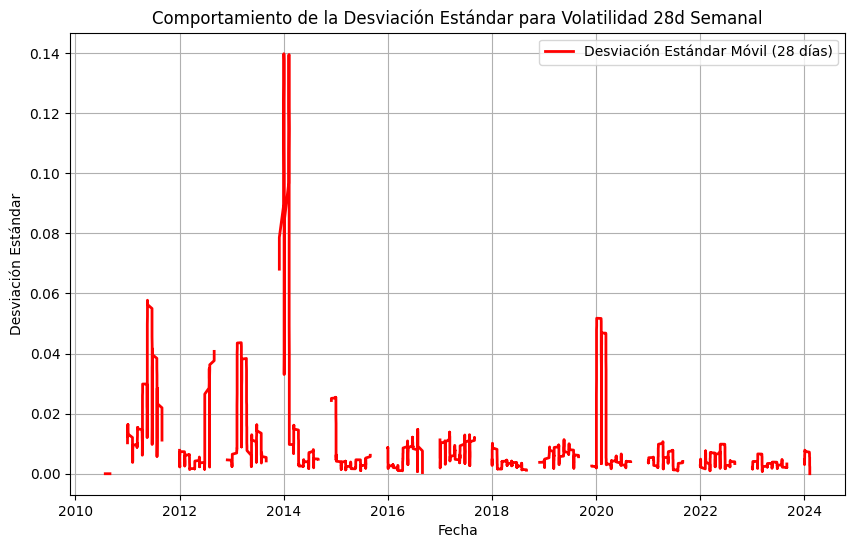

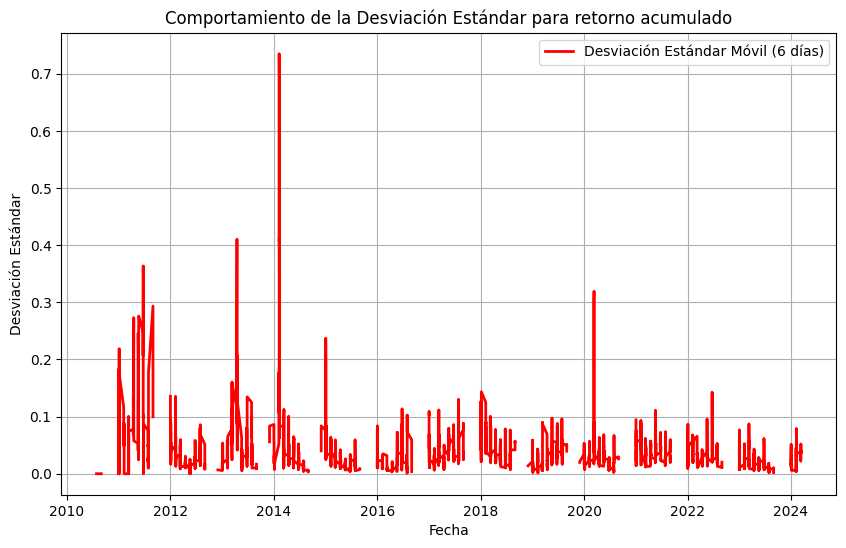

In [876]:
def graficar_desviacion_estandar_movil(serie, nombre, window=6):
    plt.figure(figsize=(10, 6))
    desviacion_movil = serie.rolling(window=window).std()
    plt.plot(desviacion_movil, label=f'Desviación Estándar Móvil ({window} días)', color='red', linewidth=2)
    plt.title(f'Comportamiento de la Desviación Estándar para {nombre}')
    plt.xlabel('Fecha')
    plt.ylabel('Desviación Estándar')
    plt.legend()
    plt.grid(True)
    plt.show()
graficar_desviacion_estandar_movil(bitcoin_data['Volatilidad_7d'], 'Volatilidad 7d Semanal', window=7)
graficar_desviacion_estandar_movil(bitcoin_data['Volatilidad_14d'], 'Volatilidad 14d Semanal', window=14)
graficar_desviacion_estandar_movil(bitcoin_data['Volatilidad_21d'], 'Volatilidad 21d Semanal', window=21)
graficar_desviacion_estandar_movil(bitcoin_data['Volatilidad_28d'], 'Volatilidad 28d Semanal', window=28)
graficar_desviacion_estandar_movil(bitcoin_data['Retorno_Acumulado'], 'retorno acumulado', window=6)

Se observa que la desviación estandar se mantiene baja hasta el 2014, en este año se registran picos significativos

### Item 7.
Aplique las medias móviles M(2) t (t,t+1) , M(4) t , M(4) t , M(3) (t−1,t+1) t y M(3) a la serie  del precio de cierre de BTC-USD. Posteriormente, úselas para remover tendencia y aplique la prueba de Dickey Fuller y LJung Box para verificar si se logró estacionariedad

In [877]:
#M2
bitcoin_data['M2R'] = bitcoin_data['Retorno_Acumulado'].rolling(window=6).mean()
bitcoin_data['M27'] = bitcoin_data['Volatilidad_7d'].rolling(window=7).mean()
bitcoin_data['M214'] = bitcoin_data['Volatilidad_14d'].rolling(window=14).mean()
bitcoin_data['M221'] = bitcoin_data['Volatilidad_21d'].rolling(window=21).mean()
bitcoin_data['M228'] = bitcoin_data['Volatilidad_28d'].rolling(window=28).mean()


In [878]:
prueba_dickey_fuller(bitcoin_data['M2R'], 'M2R')
prueba_dickey_fuller(bitcoin_data['M27'], 'M27')
prueba_dickey_fuller(bitcoin_data['M214'], 'M214')
prueba_dickey_fuller(bitcoin_data['M221'], 'M221')
prueba_dickey_fuller(bitcoin_data['M228'], 'M228')

Prueba de Dickey-Fuller para M2R:
Estadístico: -1.8604877156924164
Valor p: 0.35087099552411827
Número de retardos utilizados: 31
Número de observaciones utilizadas: 4961
Valores críticos:
   1%: -3.4316688241926
   5%: -2.8621227766748327
   10%: -2.5670802129039485


Prueba de Dickey-Fuller para M27:
Estadístico: -6.8514562842150655
Valor p: 1.6901179144523168e-09
Número de retardos utilizados: 31
Número de observaciones utilizadas: 4959
Valores críticos:
   1%: -3.4316693563594916
   5%: -2.862123011782489
   10%: -2.5670803380610705


Prueba de Dickey-Fuller para M214:
Estadístico: -6.949918797279923
Valor p: 9.75242434595773e-10
Número de retardos utilizados: 32
Número de observaciones utilizadas: 4951
Valores críticos:
   1%: -3.4316714893287616
   5%: -2.862123954113155
   10%: -2.5670808397010965


Prueba de Dickey-Fuller para M221:
Estadístico: -5.633467279240362
Valor p: 1.0762654771144731e-06
Número de retardos utilizados: 32
Número de observaciones utilizadas: 4944
Valores 

La media movil de los datos de volatilidad arroja que es estacionaria y los de retorno acumulado arroja que no son estacionarios

In [879]:
# (M2(t, t+1))
bitcoin_data['M_2_t_t1R'] = (bitcoin_data['Retorno_Acumulado'] + bitcoin_data['Price'].shift(-1)) / 2
bitcoin_data['M_2_t_t17'] = (bitcoin_data['Volatilidad_7d'] + bitcoin_data['Price'].shift(-1)) / 2
bitcoin_data['M_2_t_t114'] = (bitcoin_data['Volatilidad_14d'] + bitcoin_data['Price'].shift(-1)) / 2
bitcoin_data['M_2_t_t121'] = (bitcoin_data['Volatilidad_21d'] + bitcoin_data['Price'].shift(-1)) / 2
bitcoin_data['M_2_t_t128'] = (bitcoin_data['Volatilidad_28d'] + bitcoin_data['Price'].shift(-1)) / 2


En este caso ninguno de los casos es estacioanrio

In [880]:
prueba_dickey_fuller(bitcoin_data['M_2_t_t1R'], 'M_2_t_t1R')
prueba_dickey_fuller(bitcoin_data['M_2_t_t17'], 'M_2_t_t17')
prueba_dickey_fuller(bitcoin_data['M_2_t_t114'], 'M_2_t_t114')
prueba_dickey_fuller(bitcoin_data['M_2_t_t121'], 'M_2_t_t121')
prueba_dickey_fuller(bitcoin_data['M_2_t_t128'], 'M_2_t_t128')

Prueba de Dickey-Fuller para M_2_t_t1R:
Estadístico: -2.601209501033324
Valor p: 0.09274754575399546
Número de retardos utilizados: 32
Número de observaciones utilizadas: 4964
Valores críticos:
   1%: -3.4316680267467183
   5%: -2.862122424368673
   10%: -2.5670800253574324


Prueba de Dickey-Fuller para M_2_t_t17:
Estadístico: -2.6012938056976473
Valor p: 0.09273015884661912
Número de retardos utilizados: 32
Número de observaciones utilizadas: 4964
Valores críticos:
   1%: -3.4316680267467183
   5%: -2.862122424368673
   10%: -2.5670800253574324


Prueba de Dickey-Fuller para M_2_t_t114:
Estadístico: -2.6012949170521327
Valor p: 0.09272992965871374
Número de retardos utilizados: 32
Número de observaciones utilizadas: 4964
Valores críticos:
   1%: -3.4316680267467183
   5%: -2.862122424368673
   10%: -2.5670800253574324


Prueba de Dickey-Fuller para M_2_t_t121:
Estadístico: -2.6012949602826487
Valor p: 0.09272992074355496
Número de retardos utilizados: 32
Número de observaciones utili

In [881]:
#M(4)
bitcoin_data['M_4R'] = bitcoin_data['Retorno_Acumulado'].rolling(window=4).mean()
bitcoin_data['M_47'] = bitcoin_data['Volatilidad_7d'].rolling(window=4).mean()
bitcoin_data['M_414'] = bitcoin_data['Volatilidad_14d'].rolling(window=4).mean()
bitcoin_data['M_421'] = bitcoin_data['Volatilidad_21d'].rolling(window=4).mean()
bitcoin_data['M_428'] = bitcoin_data['Volatilidad_28d'].rolling(window=4).mean()
print(bitcoin_data[['Price', 'M_4']].head(10))

              Price        M_4
Date                          
2024-03-12  64037.8      0.000
2024-03-12  63785.5      0.000
2024-03-12  65503.8      0.000
2024-03-12  67854.0  65295.275
2024-03-12  62050.0  64798.325
2024-03-12  67594.1  65750.475
2024-03-11  68391.2  66472.325
2024-03-11  65314.2  65837.375
2024-03-11  69463.7  67690.800
2024-03-11  71387.5  68639.150


In [882]:
prueba_dickey_fuller(bitcoin_data['M_4R'], 'M_4R')
prueba_dickey_fuller(bitcoin_data['M_47'], 'M_47')
prueba_dickey_fuller(bitcoin_data['M_414'], 'M_414')
prueba_dickey_fuller(bitcoin_data['M_421'], 'M_421')
prueba_dickey_fuller(bitcoin_data['M_428'], 'M_428')

Prueba de Dickey-Fuller para M_4R:
Estadístico: -1.787168785631062
Valor p: 0.38685038524649784
Número de retardos utilizados: 29
Número de observaciones utilizadas: 4965
Valores críticos:
   1%: -3.431667761145687
   5%: -2.8621223070279247
   10%: -2.5670799628923104


Prueba de Dickey-Fuller para M_47:
Estadístico: -6.945535775466764
Valor p: 9.994786594681288e-10
Número de retardos utilizados: 32
Número de observaciones utilizadas: 4961
Valores críticos:
   1%: -3.4316688241926
   5%: -2.8621227766748327
   10%: -2.5670802129039485


Prueba de Dickey-Fuller para M_414:
Estadístico: -6.045631468227909
Valor p: 1.3139730867007032e-07
Número de retardos utilizados: 32
Número de observaciones utilizadas: 4961
Valores críticos:
   1%: -3.4316688241926
   5%: -2.8621227766748327
   10%: -2.5670802129039485


Prueba de Dickey-Fuller para M_421:
Estadístico: -6.477956550118083
Valor p: 1.3166855124616981e-08
Número de retardos utilizados: 32
Número de observaciones utilizadas: 4961
Valores

Las medias moviles de los retorno acumulados es no estacioanrios y las de la volatilidad son estacionarias

In [883]:
# (M_4_(t, t+1))
bitcoin_data['M_4_t_t1R'] = (
    bitcoin_data['Retorno_Acumulado'].rolling(window=4).mean() + 
    bitcoin_data['Retorno_Acumulado'].shift(-4).rolling(window=4).mean()
) / 2
bitcoin_data['M_4_t_t17'] = (
    bitcoin_data['Volatilidad_7d'].rolling(window=4).mean() + 
    bitcoin_data['Volatilidad_7d'].shift(-4).rolling(window=4).mean()
) / 2
bitcoin_data['M_4_t_t114'] = (
    bitcoin_data['Volatilidad_14d'].rolling(window=4).mean() + 
    bitcoin_data['Volatilidad_14d'].shift(-4).rolling(window=4).mean()
) / 2
bitcoin_data['M_4_t_t121'] = (
    bitcoin_data['Volatilidad_21d'].rolling(window=4).mean() + 
    bitcoin_data['Volatilidad_21d'].shift(-4).rolling(window=4).mean()
) / 2
bitcoin_data['M_4_t_t128'] = (
    bitcoin_data['Volatilidad_28d'].rolling(window=4).mean() + 
    bitcoin_data['Volatilidad_28d'].shift(-4).rolling(window=4).mean()
) / 2


In [884]:
prueba_dickey_fuller(bitcoin_data['M_4_t_t1R'], 'M_4_t_t1R')
prueba_dickey_fuller(bitcoin_data['M_4_t_t17'], 'M_4_t_t17')
prueba_dickey_fuller(bitcoin_data['M_4_t_t114'], 'M_4_t_t114')
prueba_dickey_fuller(bitcoin_data['M_4_t_t121'], 'M_4_t_t121')
prueba_dickey_fuller(bitcoin_data['M_4_t_t128'], 'M_4_t_t128')

Prueba de Dickey-Fuller para M_4_t_t1R:
Estadístico: -1.5361725785665399
Valor p: 0.5155474807056786
Número de retardos utilizados: 32
Número de observaciones utilizadas: 4958
Valores críticos:
   1%: -3.4316696226040238
   5%: -2.8621231294074683
   10%: -2.5670804006775105


Prueba de Dickey-Fuller para M_4_t_t17:
Estadístico: -6.986060373048003
Valor p: 7.96339937994057e-10
Número de retardos utilizados: 32
Número de observaciones utilizadas: 4957
Valores críticos:
   1%: -3.4316698889560326
   5%: -2.8621232470799196
   10%: -2.5670804633192237


Prueba de Dickey-Fuller para M_4_t_t114:
Estadístico: -6.622850773022658
Valor p: 5.976618198538989e-09
Número de retardos utilizados: 32
Número de observaciones utilizadas: 4957
Valores críticos:
   1%: -3.4316698889560326
   5%: -2.8621232470799196
   10%: -2.5670804633192237


Prueba de Dickey-Fuller para M_4_t_t121:
Estadístico: -6.4870887278353395
Valor p: 1.2530701118184623e-08
Número de retardos utilizados: 32
Número de observacione

Las medias moviles de los retorno acumulados es no estacioanrios y las de la volatilidad son estacionarias

In [885]:
bitcoin_data['M_3R'] = bitcoin_data['Retorno_Acumulado'].rolling(window=3).mean()
bitcoin_data['M_37'] = bitcoin_data['Volatilidad_7d'].rolling(window=3).mean()
bitcoin_data['M_314'] = bitcoin_data['Volatilidad_14d'].rolling(window=3).mean()
bitcoin_data['M_321'] = bitcoin_data['Volatilidad_21d'].rolling(window=3).mean()
bitcoin_data['M_328'] = bitcoin_data['Volatilidad_28d'].rolling(window=3).mean()


In [886]:
prueba_dickey_fuller(bitcoin_data['M_3R'], 'M_3R')
prueba_dickey_fuller(bitcoin_data['M_37'], 'M_37')
prueba_dickey_fuller(bitcoin_data['M_314'], 'M_314')
prueba_dickey_fuller(bitcoin_data['M_321'], 'M_321')
prueba_dickey_fuller(bitcoin_data['M_328'], 'M_328')

Prueba de Dickey-Fuller para M_3R:
Estadístico: -1.7022031359032352
Valor p: 0.42997771395789497
Número de retardos utilizados: 32
Número de observaciones utilizadas: 4963
Valores críticos:
   1%: -3.431668292454838
   5%: -2.862122541756721
   10%: -2.567080087847736


Prueba de Dickey-Fuller para M_37:
Estadístico: -7.079756473413681
Valor p: 4.699666674599143e-10
Número de retardos utilizados: 32
Número de observaciones utilizadas: 4962
Valores críticos:
   1%: -3.4316685582701103
   5%: -2.862122659192098
   10%: -2.5670801503632363


Prueba de Dickey-Fuller para M_314:
Estadístico: -6.151972438661141
Valor p: 7.524259944856608e-08
Número de retardos utilizados: 32
Número de observaciones utilizadas: 4962
Valores críticos:
   1%: -3.4316685582701103
   5%: -2.862122659192098
   10%: -2.5670801503632363


Prueba de Dickey-Fuller para M_321:
Estadístico: -6.919467609114153
Valor p: 1.1564359164908902e-09
Número de retardos utilizados: 32
Número de observaciones utilizadas: 4962
Valor

Las medias moviles de los retorno acumulados es no estacioanrios y las de la volatilidad son estacionarias

In [887]:
#M3 (t-1, T+1)
bitcoin_data['M_3_t-1_t+1R'] = bitcoin_data['Retorno_Acumulado'].shift(2)
bitcoin_data['M_3_t-1_t+17'] = bitcoin_data['Volatilidad_7d'].shift(2)
bitcoin_data['M_3_t-1_t+114'] = bitcoin_data['Volatilidad_14d'].shift(2)
bitcoin_data['M_3_t-1_t+121'] = bitcoin_data['Volatilidad_21d'].shift(2)
bitcoin_data['M_3_t-1_t+128'] = bitcoin_data['Volatilidad_28d'].shift(2)

In [888]:
prueba_dickey_fuller(bitcoin_data['M_3_t-1_t+1R'], 'M_3_t-1_t+1R')
prueba_dickey_fuller(bitcoin_data['M_3_t-1_t+17'], 'M_3_t-1_t+17')
prueba_dickey_fuller(bitcoin_data['M_3_t-1_t+114'], 'M_3_t-1_t+114')
prueba_dickey_fuller(bitcoin_data['M_4_t_t1R'], 'M_4_t_t1R')
prueba_dickey_fuller(bitcoin_data['M_3_t-1_t+121'], 'M_3_t-1_t+121')
prueba_dickey_fuller(bitcoin_data['M_3_t-1_t+128'], 'M_3_t-1_t+128')


Prueba de Dickey-Fuller para M_3_t-1_t+1R:
Estadístico: -1.6706185163633218
Valor p: 0.4463107129795939
Número de retardos utilizados: 32
Número de observaciones utilizadas: 4963
Valores críticos:
   1%: -3.431668292454838
   5%: -2.862122541756721
   10%: -2.567080087847736


Prueba de Dickey-Fuller para M_3_t-1_t+17:
Estadístico: -7.471390933702815
Valor p: 5.043926908976128e-11
Número de retardos utilizados: 32
Número de observaciones utilizadas: 4963
Valores críticos:
   1%: -3.431668292454838
   5%: -2.862122541756721
   10%: -2.567080087847736


Prueba de Dickey-Fuller para M_3_t-1_t+114:
Estadístico: -6.803434056280165
Valor p: 2.2072405949815065e-09
Número de retardos utilizados: 28
Número de observaciones utilizadas: 4967
Valores críticos:
   1%: -3.4316672302646283
   5%: -2.8621220724882153
   10%: -2.5670798380375506


Prueba de Dickey-Fuller para M_4_t_t1R:
Estadístico: -1.5361725785665399
Valor p: 0.5155474807056786
Número de retardos utilizados: 32
Número de observacione

Las medias moviles de los retorno acumulados es no estacioanrios y las de la volatilidad son estacionarias